In [1]:
#加载各类需要用到的程序包
import os
import pywt
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei'] # 用来正常显示中文标签SimHei
plt.rcParams['axes.unicode_minus'] = False # 用来正常显示负号
from pandas import DataFrame
from pandas import concat#相空间重构用到的包
import seaborn as sns
from scipy.stats import pearsonr
from datetime import datetime
from statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense, Dropout
from PyEMD import CEEMDAN
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error

In [2]:
#导入文件
data = pd.read_excel(r'D:\article\wind power_66MW.xlsx', sheet_name=None)
df = pd.concat(data.values(), ignore_index=True)
df

,windspeed,wind_direction,temperature,atmosphere,humidity,power
0,4.285714,188.942857,11.869286,892.571429,69.150000,8.644286
1,4.150667,187.753333,11.756667,892.000000,69.755333,8.995333
2,4.492000,182.360000,11.708000,892.000000,70.310000,9.301333
3,4.229333,203.886667,11.620000,892.000000,71.268000,9.990667
4,4.472000,196.440000,11.504000,892.000000,72.164000,9.178667
...,...,...,...,...,...,...
11803,3.828667,1.633333,2.964000,888.000000,100.000000,1.284667
11804,3.573333,8.358000,2.953333,888.000000,100.000000,0.824000
11805,3.516000,9.359333,2.975333,888.000000,100.000000,1.088000
11806,3.192000,10.528000,3.002667,888.000000,100.000000,1.020000


In [3]:
import pandas as pd
# 定义一个函数来根据索引范围划分季节
def split_season(df, spring_start, spring_end, summer_start, summer_end, autumn_start, autumn_end, winter_start, winter_end):
    # 春季数据
    spring = df.iloc[spring_start:spring_end + 1]  # +1是因为Python的切片是左闭右开的
    # 夏季数据
    summer = df.iloc[summer_start:summer_end + 1]
    # 秋季数据
    autumn = df.iloc[autumn_start:autumn_end + 1]
    # 冬季数据
    winter = df.iloc[winter_start:winter_end + 1]
    return spring, summer, autumn, winter

# 使用定义好的函数划分季节
spring_df, summer_df, autumn_df, winter_df = split_season(df, 0, 2878, 2879, 5855, 5856, 8831, 8832, 11807)

# 打印每个季节的数据框的大小，以确认划分是否正确
print(f"Spring DataFrame size: {spring_df.shape}")
print(f"Summer DataFrame size: {summer_df.shape}")
print(f"Autumn DataFrame size: {autumn_df.shape}")
print(f"Winter DataFrame size: {winter_df.shape}")

Spring DataFrame size: (2879, 6)
Summer DataFrame size: (2977, 6)
Autumn DataFrame size: (2976, 6)
Winter DataFrame size: (2976, 6)


In [4]:
#平稳性检验
from statsmodels.tsa.stattools import adfuller
seasonal_dfs = {
    'spring': spring_df,
    'summer': summer_df,
    'autumn': autumn_df,
    'winter': winter_df
}

# 定义要检验的变量列表
variables = ['windspeed', 'wind_direction', 'atmosphere','humidity', 'power']

# 函数用于执行ADF检验并打印结果
def perform_adf_test(df, variable):
    result = adfuller(df[variable])
    print(f"Variable: {variable}")
    print(f"  ADF Statistic: {result[0]}")
    print(f"  p-value: {result[1]}")
    print(f"  Used lags: {result[2]}")
    print(f"  Significance level: {result[3]}")
    print(f"  Critical Values: {result[4]}")
    print("  Conclusion: ", end="")
    if result[1] > 0.05:
        print("The time series is not stationary.")
    else:
        print("The time series is stationary.")
    print()  # 打印空行以分隔不同变量的结果

# 循环遍历每个季节的数据框和每个变量
for season, df in seasonal_dfs.items():
    print(f"Season: {season}")
    for var in variables:
        if var in df.columns:
            perform_adf_test(df, var)
        else:
            print(f"  Variable '{var}' does not exist in the DataFrame.")
    print()  # 打印空行以分隔不同季节的结果

Season: spring
Variable: windspeed
  ADF Statistic: -4.693505720965445
  p-value: 8.65487367960265e-05
  Used lags: 4
  Significance level: 2874
  Critical Values: {'1%': -3.432627366129768, '5%': -2.862546185823105, '10%': -2.567305621914905}
  Conclusion: The time series is stationary.

Variable: wind_direction
  ADF Statistic: -6.09953148190322
  p-value: 9.912341003352016e-08
  Used lags: 8
  Significance level: 2870
  Critical Values: {'1%': -3.4326305430048927, '5%': -2.8625475888928142, '10%': -2.5673063689009217}
  Conclusion: The time series is stationary.

Variable: atmosphere
  ADF Statistic: -2.4754427333018887
  p-value: 0.12156427070580517
  Used lags: 28
  Significance level: 2850
  Critical Values: {'1%': -3.43264656126454, '5%': -2.862554663348615, '10%': -2.56731013530317}
  Conclusion: The time series is not stationary.

Variable: humidity
  ADF Statistic: -6.547825003020405
  p-value: 9.006312163963035e-09
  Used lags: 8
  Significance level: 2870
  Critical Values:

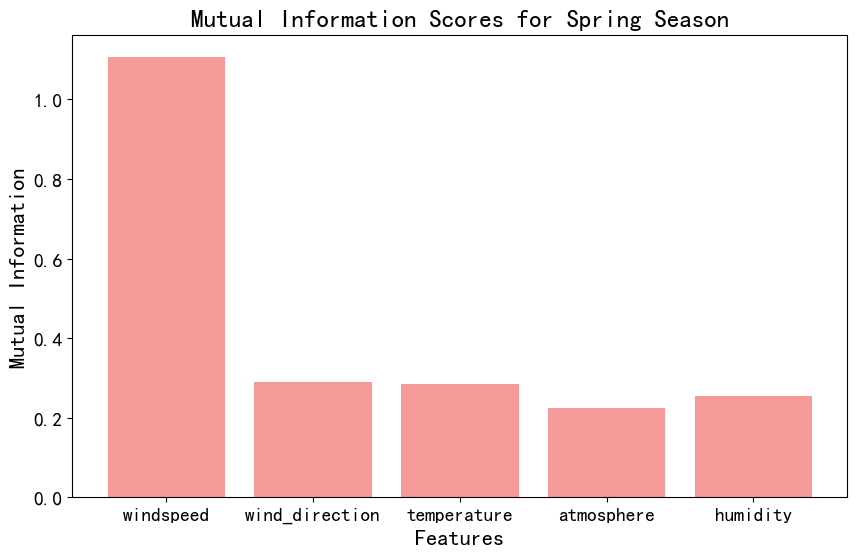

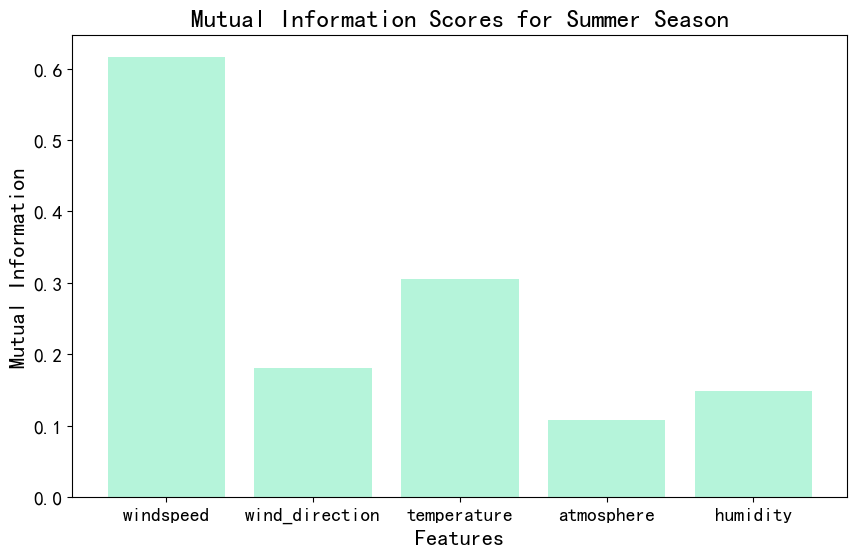

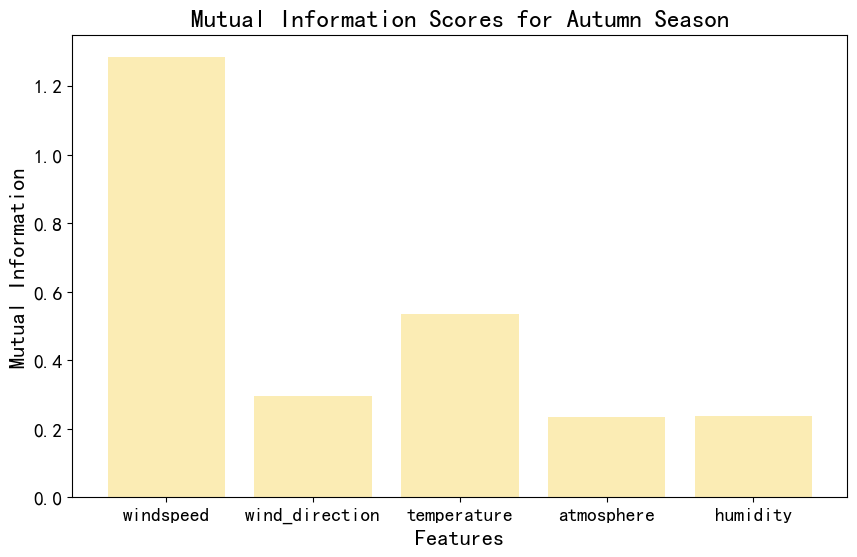

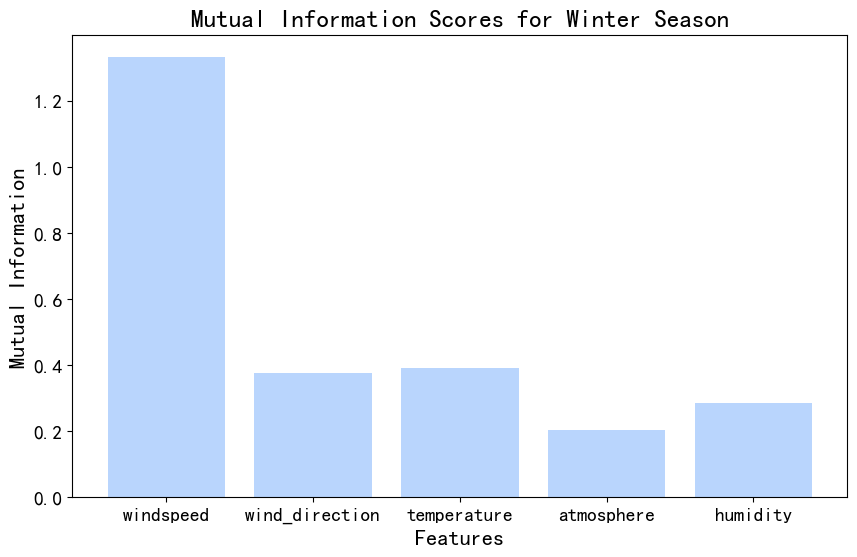

In [16]:
#互信息可视化
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression

# 定义一个函数来计算互信息并绘制条形图
def plot_mi_scores(df, season_name, color):
    # 分离目标变量和特征
    X = df[['windspeed', 'wind_direction', 'temperature', 'atmosphere','humidity']]
    y = df['power']
    
    # 计算每个特征与目标变量之间的互信息
    mi_scores = mutual_info_regression(X, y)
    
    # 将互信息分数转换为数据框
    mi_df = pd.DataFrame(mi_scores, index=X.columns, columns=[f'MI_{season_name}'])
    
    # 可视化
    plt.figure(figsize=(10, 6))
    plt.bar(mi_df.index, mi_df[f'MI_{season_name}'], color=color)
    plt.xlabel('Features', fontsize=16)
    plt.ylabel('Mutual Information', fontsize=16)
    plt.title(f'Mutual Information Scores for {season_name} Season', fontsize=18)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    # ========== 只保存春天 ==========
    if season_name == "Spring":
        plt.savefig("风电场3互信息.png", dpi=500, bbox_inches='tight')

    plt.show()

qt="#FBECB4"
xt="#B5F4DA"
ct="#F69999"
dt="#B9D5FD"

seasons = ['Spring', 'Summer', 'Autumn', 'Winter']
colors = [ct, xt, qt, dt]

for season, color in zip(seasons, colors):
    plot_mi_scores(eval(f'{season.lower()}_df'), season, color)


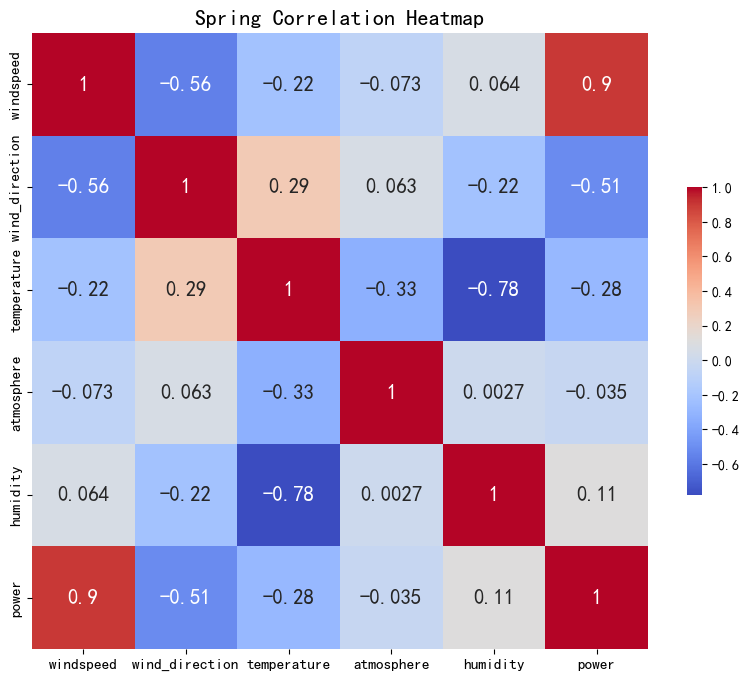

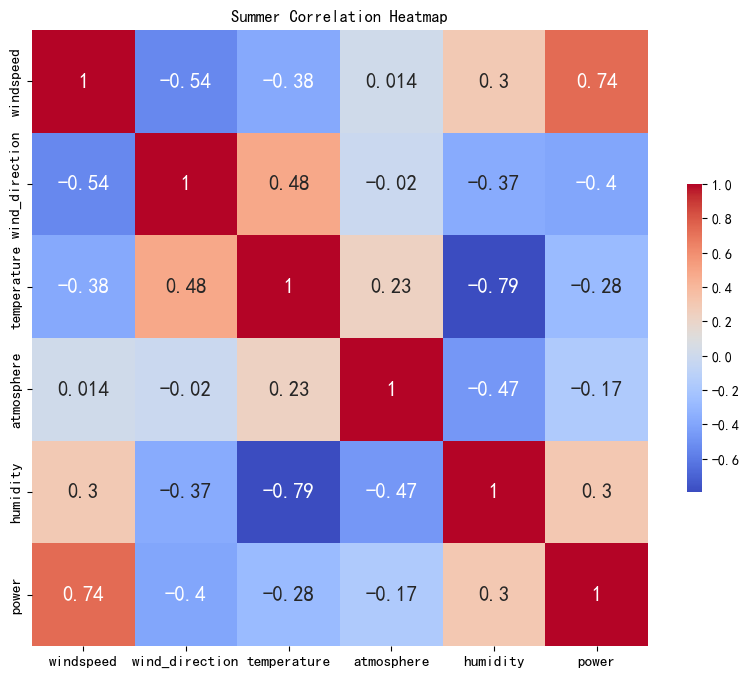

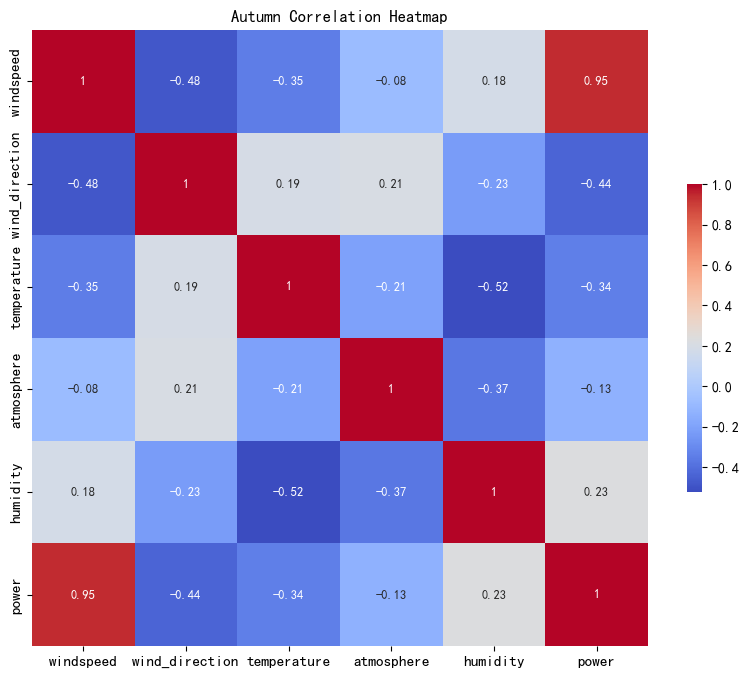

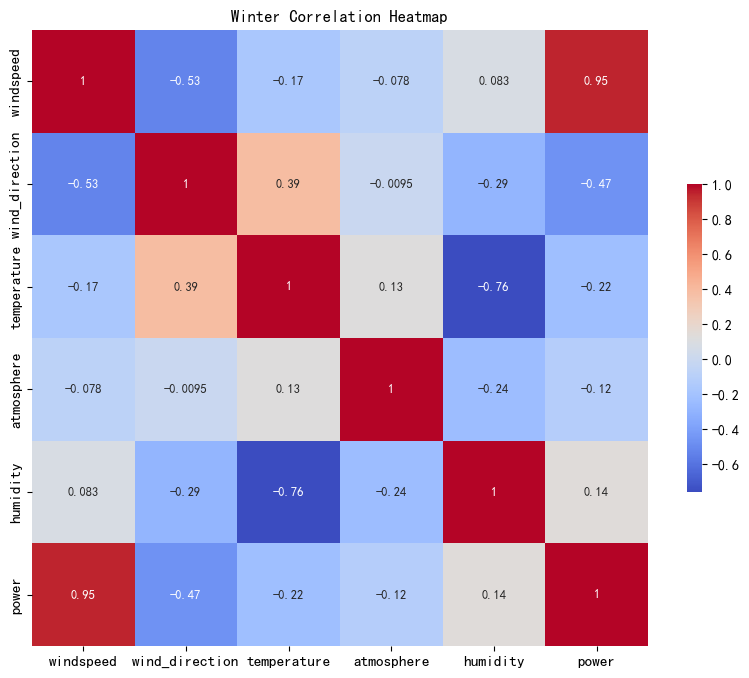

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# 计算相关系数
spring_corr = spring_df.corr()
summer_corr = summer_df.corr()
autumn_corr = autumn_df.corr()
winter_corr = winter_df.corr()

# 春天 —— 显示 + 300dpi 高清保存
plt.figure(figsize=(10, 8))
sns.heatmap(spring_corr, annot=True, annot_kws={"size":15}, cmap='coolwarm', vmax=1, square=True, cbar_kws={"shrink": .5})
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.title('Spring Correlation Heatmap', fontsize=16)
plt.savefig("风电场3相关系数.png", dpi=500, bbox_inches='tight')
plt.show()

# 夏天 —— 只显示
plt.figure(figsize=(10, 8))
sns.heatmap(summer_corr, annot=True, annot_kws={"size": 15}, cmap='coolwarm', vmax=1, square=True, cbar_kws={"shrink": .5})
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.title('Summer Correlation Heatmap')
plt.show()

# 秋天 —— 只显示
plt.figure(figsize=(10, 8))
sns.heatmap(autumn_corr, annot=True, annot_kws={"size": 9}, cmap='coolwarm', vmax=1, square=True, cbar_kws={"shrink": .5})
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.title('Autumn Correlation Heatmap')
plt.show()

# 冬天 —— 只显示
plt.figure(figsize=(10, 8))
sns.heatmap(winter_corr, annot=True, annot_kws={"size": 9}, cmap='coolwarm', vmax=1, square=True, cbar_kws={"shrink": .5})
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.title('Winter Correlation Heatmap')
plt.show()


Feature importances for spring:
          Feature  Importance
0       windspeed    0.909202
4        humidity    0.027232
2     temperature    0.024747
3      atmosphere    0.019952
1  wind_direction    0.018868


Feature importances for summer:
          Feature  Importance
0       windspeed    0.662401
3      atmosphere    0.153856
2     temperature    0.102270
4        humidity    0.042081
1  wind_direction    0.039393


Feature importances for autumn:
          Feature  Importance
0       windspeed    0.947859
2     temperature    0.016783
4        humidity    0.015677
1  wind_direction    0.010433
3      atmosphere    0.009248


Feature importances for winter:
          Feature  Importance
0       windspeed    0.948975
2     temperature    0.019163
4        humidity    0.014745
3      atmosphere    0.008827
1  wind_direction    0.008290




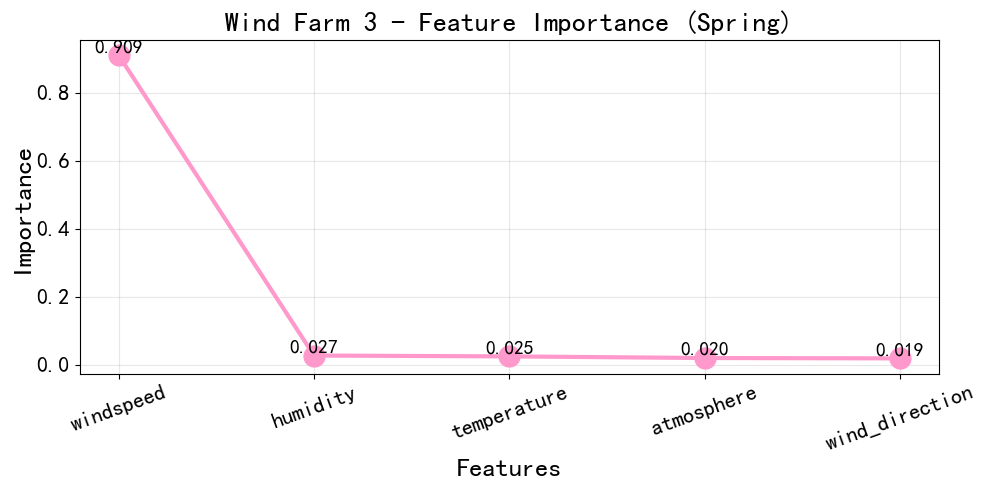

In [15]:
# 特征重要性 + 春天青绿色折线图（带数据标签）
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

seasons = ['spring', 'summer', 'autumn', 'winter']
season_dfs = [spring_df, summer_df, autumn_df, winter_df]

all_importances = {}

for season, df in zip(seasons, season_dfs):
    features = df.iloc[:, :-1]
    target = df.iloc[:, -1]

    x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(x_train, y_train)

    importances = rf.feature_importances_

    feature_importances = pd.DataFrame({
        'Feature': x_train.columns,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    all_importances[season] = feature_importances

    print(f"Feature importances for {season}:")
    print(feature_importances)
    print("\n")

# ===================== 春天：青绿色折线图 + 数据标签 =====================
spring_data = all_importances['spring']
features = spring_data['Feature']
scores = spring_data['Importance']

plt.figure(figsize=(10, 5))

# 青绿色折线
plt.plot(features, scores, color='#FF99CC', linewidth=3, marker='o', markersize=15)

# 数据标签（放大字体）
for f, s in zip(features, scores):
    plt.text(f, s + 0.01, f'{s:.3f}', ha='center', fontsize=14, fontweight='bold')

# 标题、坐标轴标签放大
plt.title('Wind Farm 3 - Feature Importance (Spring)', fontsize=20)
plt.xlabel('Features', fontsize=19)
plt.ylabel('Importance', fontsize=19)

# X/Y轴刻度字体放大
plt.xticks(rotation=20, fontsize=16)
plt.yticks(fontsize=16)

plt.grid(alpha=0.3)
plt.tight_layout()

# 保存 300dpi 高清图
plt.savefig("风电场3特征重要性.png", dpi=500, bbox_inches='tight')
plt.show()

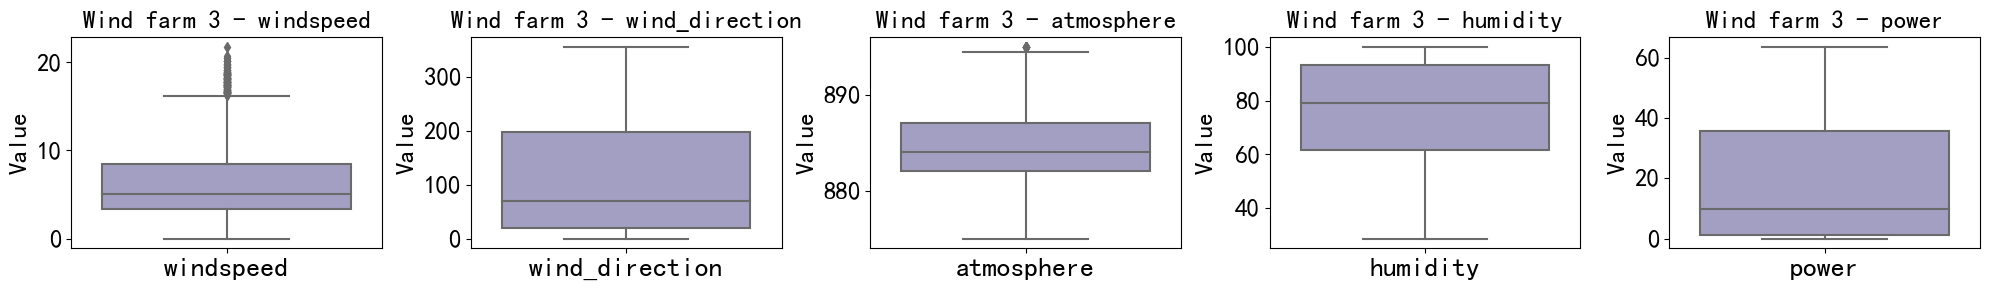

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 定义变量列表
variables = ['windspeed', 'wind_direction', 'atmosphere','humidity', 'power']

# 为每一行定义不同的颜色
palette = 'Purples'  # 只使用一个颜色板，因为我们只展示春天的数据

# 创建一个1行5列的子图布局，因为我们只展示春天的数据
fig, axs = plt.subplots(1, 5, figsize=(20, 3))
axs = axs.flatten()

# 绘制箱型图
for j, variable in enumerate(variables):
    sns.boxplot(data=spring_df[[variable]], ax=axs[j], palette=palette)
    # 子标题放大
    axs[j].set_title(f'Wind farm 3 - {variable}', fontsize=18)
    # X/Y轴标签放大
    axs[j].set_ylabel('Value', fontsize=18)
    axs[j].set_xlabel('')
    # 坐标轴刻度字体放大
    axs[j].tick_params(axis='x', labelsize=20)
    axs[j].tick_params(axis='y', labelsize=18)

# 调整子图之间的间距
plt.tight_layout()

# 保存高清图片
plt.savefig("风电场3箱线图.png", dpi=500, bbox_inches='tight')

# 显示图片
plt.show()


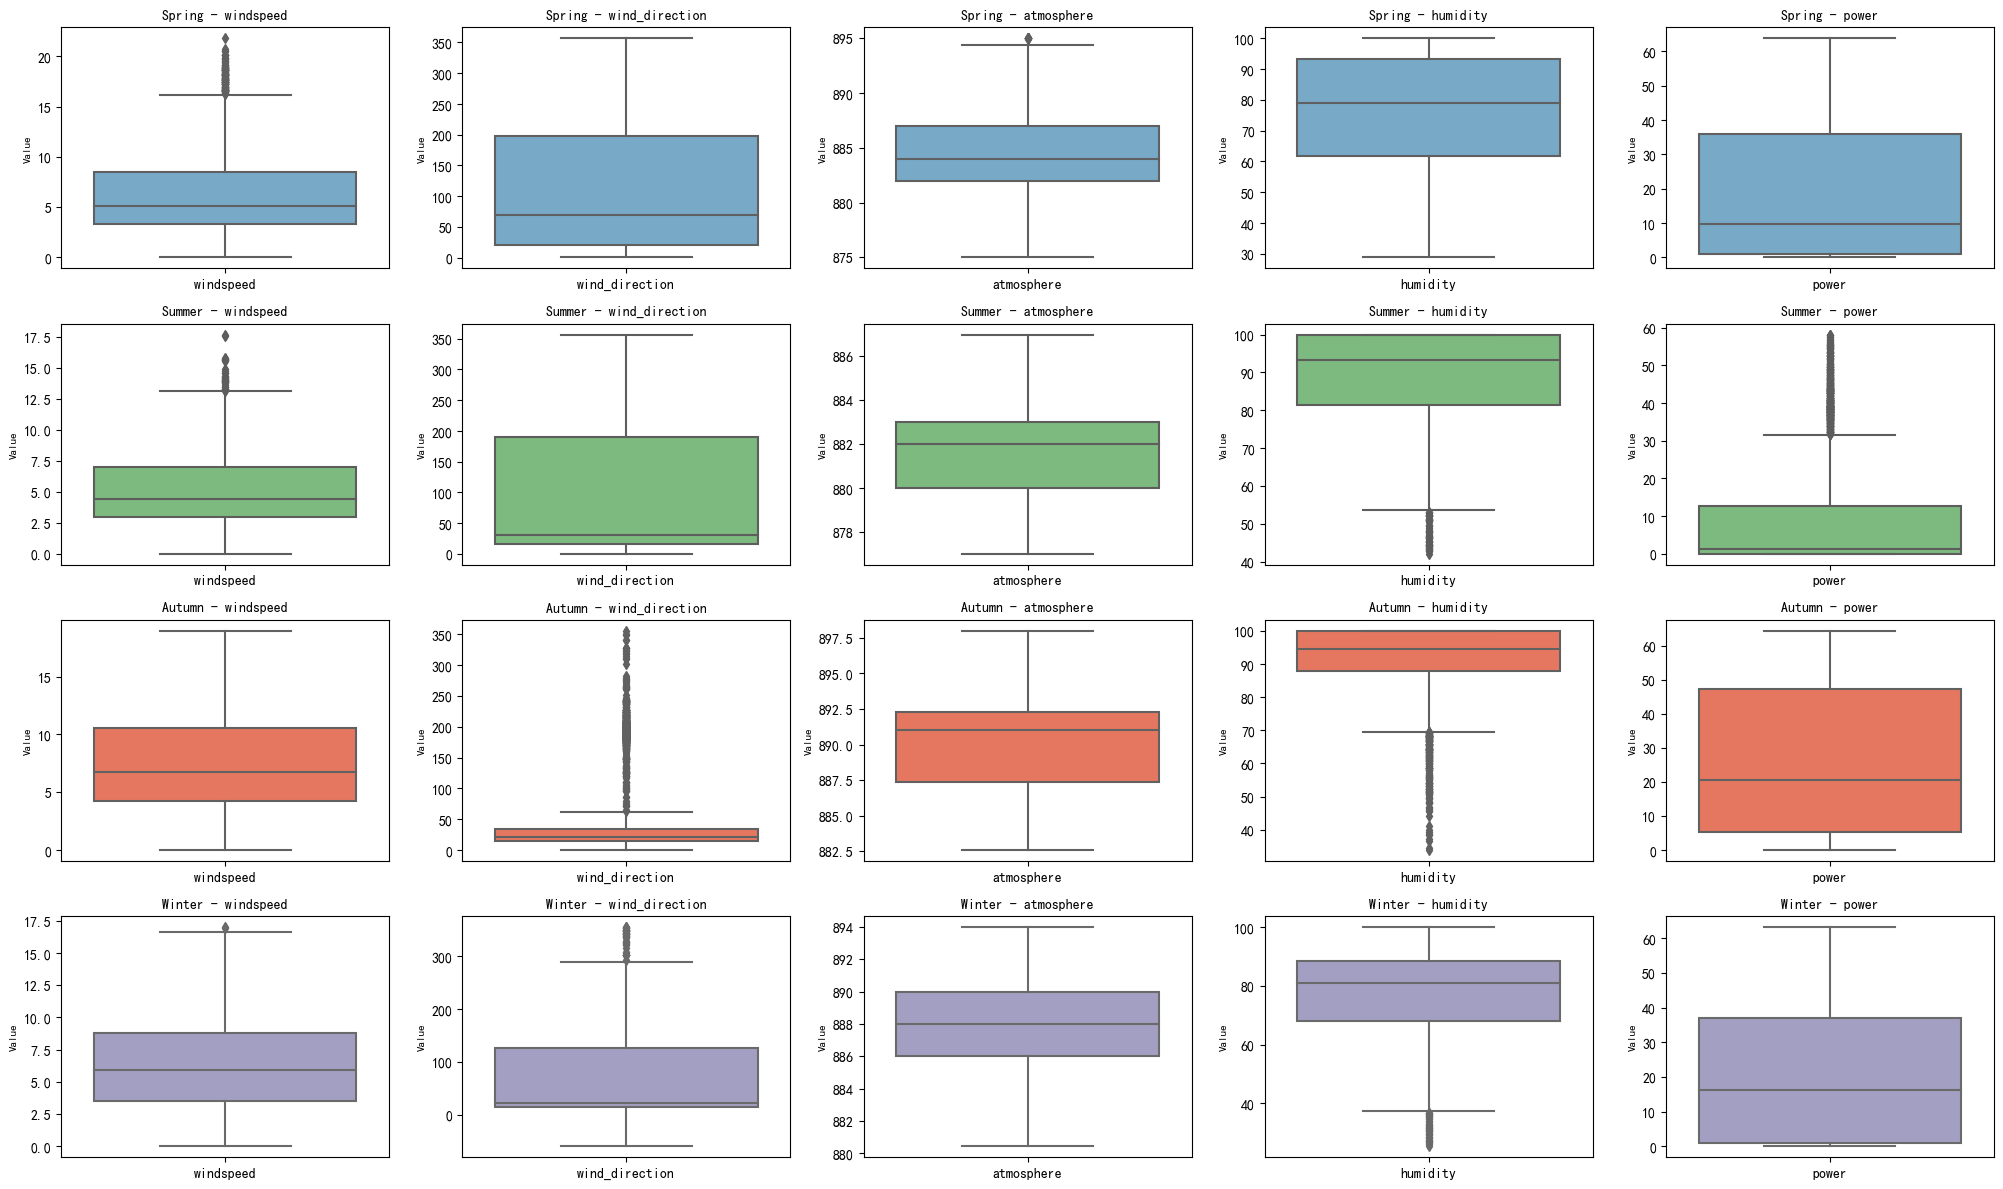

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
# 定义变量列表
variables = ['windspeed', 'wind_direction', 'atmosphere','humidity', 'power']
# 为每一行定义不同的颜色
palettes = ['Blues', 'Greens', 'Reds', 'Purples']

# 创建一个4行6列的子图布局
fig, axs = plt.subplots(4, 5, figsize=(20, 12))  # 调整图形大小以适应4x6布局
axs = axs.flatten()  # 将2D子图数组转换为1D，以便迭代

# 定义季节列表
seasons = ['Spring', 'Summer', 'Autumn', 'Winter']

# 绘制箱型图
for i, season_df in enumerate([spring_df, summer_df, autumn_df, winter_df]):
    for j, variable in enumerate(variables):
        sns.boxplot(data=season_df[[variable]], ax=axs[i*5 + j], palette=palettes[i])
        axs[i*5 + j].set_title(f'{seasons[i]} - {variable}', fontsize=10)
        axs[i*5 + j].set_ylabel('Value', fontsize=8)
        axs[i*5 + j].set_xlabel('')

# 调整子图之间的间距
plt.tight_layout()
plt.show()

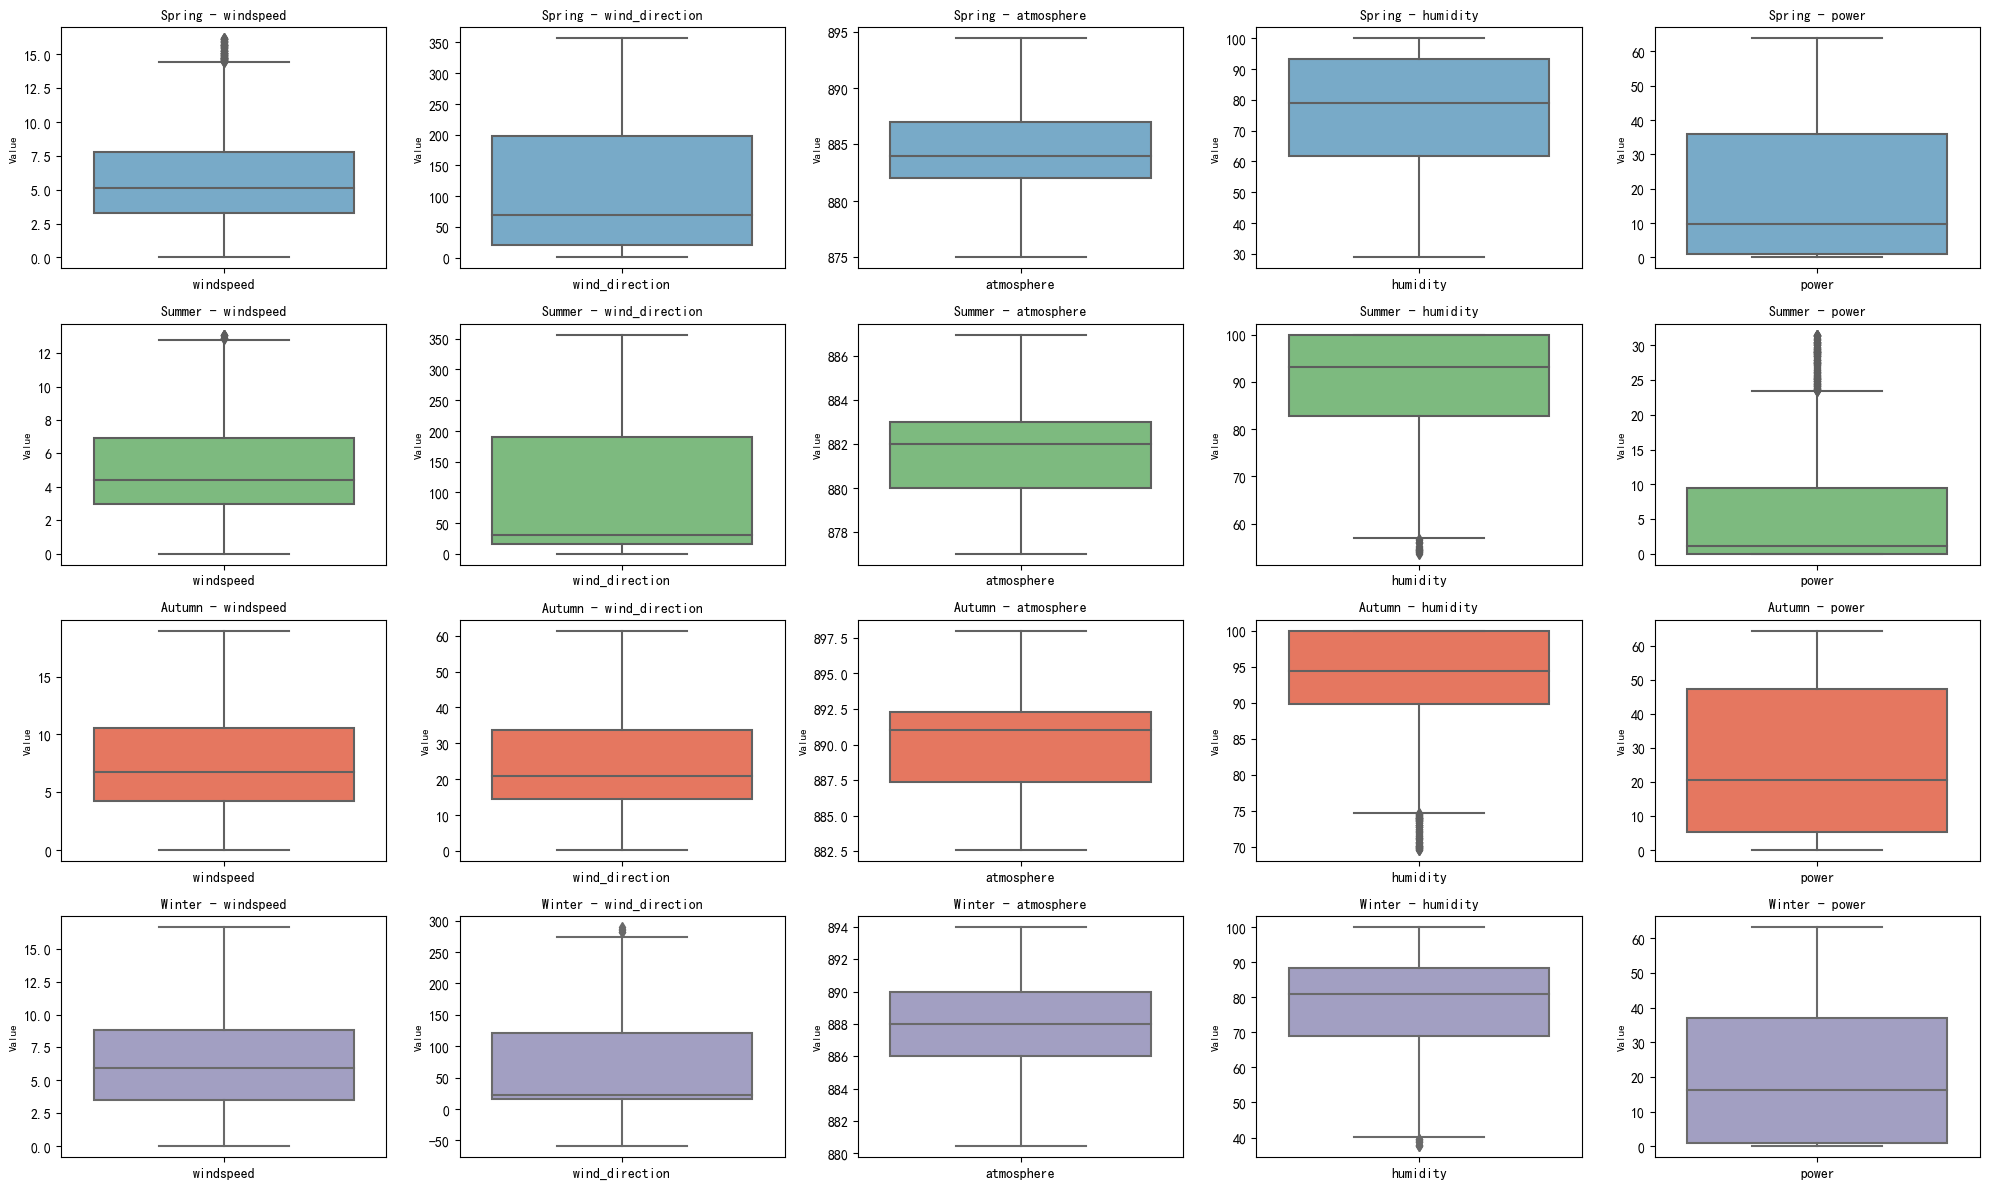

Corrected Spring Data:
   windspeed  wind_direction  temperature  atmosphere   humidity     power
0   4.285714      188.942857    11.869286  892.571429  69.150000  8.644286
1   4.150667      187.753333    11.756667  892.000000  69.755333  8.995333
2   4.492000      182.360000    11.708000  892.000000  70.310000  9.301333
3   4.229333      203.886667    11.620000  892.000000  71.268000  9.990667
4   4.472000      196.440000    11.504000  892.000000  72.164000  9.178667

Corrected Summer Data:
      windspeed  wind_direction  temperature  atmosphere   humidity     power
2879   4.013333      186.133333    17.526667       886.0  62.450000  9.109333
2880   4.677857       15.262857    19.755000       884.0  91.900000  1.435714
2881   4.873333       20.430000    19.886667       884.0  90.866667  1.587333
2882   5.120000       17.950000    19.713333       884.0  91.266667  1.671333
2883   5.643333       16.490000    19.593333       884.0  90.806667  3.179333

Corrected Autumn Data:
      winds

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 定义变量列表
variables =['windspeed', 'wind_direction', 'atmosphere','humidity', 'power']
# 为每一行定义不同的颜色
palettes = ['Blues', 'Greens', 'Reds', 'Purples']

# 创建一个4行6列的子图布局
fig, axs = plt.subplots(4, 5, figsize=(20, 12))
axs = axs.flatten()

# 定义季节列表
seasons = ['Spring', 'Summer', 'Autumn', 'Winter']

# 函数：用均值替换异常值
def replace_outliers_with_mean(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # 计算均值
    mean_value = df[column].mean()
    # 替换异常值为均值
    df[column] = np.where((df[column] < lower_bound) | (df[column] > upper_bound), mean_value, df[column])
    return df

# 对每个季节的数据框进行异常值校正
corrected_spring_df = spring_df.copy()
corrected_summer_df = summer_df.copy()
corrected_autumn_df = autumn_df.copy()
corrected_winter_df = winter_df.copy()

for i, season_df in enumerate([corrected_spring_df, corrected_summer_df, corrected_autumn_df, corrected_winter_df]):
    for variable in variables:
        season_df = replace_outliers_with_mean(season_df, variable)

# 绘制箱型图
for i, season_df in enumerate([corrected_spring_df, corrected_summer_df, corrected_autumn_df, corrected_winter_df]):
    for j, variable in enumerate(variables):
        sns.boxplot(data=season_df[[variable]], ax=axs[i*5 + j], palette=palettes[i])
        axs[i*5 + j].set_title(f'{seasons[i]} - {variable}', fontsize=10)
        axs[i*5 + j].set_ylabel('Value', fontsize=8)
        axs[i*5 + j].set_xlabel('')

# 调整子图之间的间距
plt.tight_layout()
plt.show()

# 输出校正后的四季数据序列
print("Corrected Spring Data:")
print(corrected_spring_df.head())
print("\nCorrected Summer Data:")
print(corrected_summer_df.head())
print("\nCorrected Autumn Data:")
print(corrected_autumn_df.head())
print("\nCorrected Winter Data:")
print(corrected_winter_df.head())

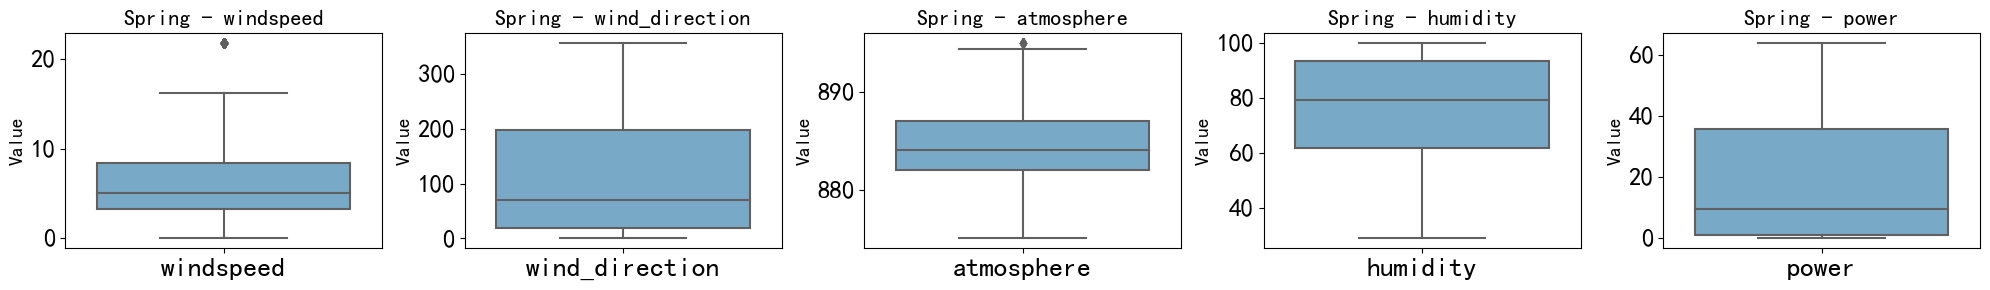

Corrected Spring Data:
   windspeed  wind_direction  temperature  atmosphere   humidity     power
0   4.285714      188.942857    11.869286  892.571429  69.150000  8.644286
1   4.150667      187.753333    11.756667  892.000000  69.755333  8.995333
2   4.492000      182.360000    11.708000  892.000000  70.310000  9.301333
3   4.229333      203.886667    11.620000  892.000000  71.268000  9.990667
4   4.472000      196.440000    11.504000  892.000000  72.164000  9.178667


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 定义变量列表
variables = ['windspeed', 'wind_direction', 'atmosphere', 'humidity', 'power']
# 为春季定义颜色
palette = 'Blues'

# 创建一个1行5列的子图布局
fig, axs = plt.subplots(1, 5, figsize=(20, 3))  # 修改为1行5列
axs = axs.flatten()

# 定义季节列表
season = 'Spring'

# 函数：用最大最小值替换异常值
def replace_outliers_with_extremes(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # 计算最大值和最小值
    min_value = df[column].min()
    max_value = df[column].max()
    # 替换异常值为最大值或最小值
    df[column] = np.where(df[column] < lower_bound, min_value, df[column])
    df[column] = np.where(df[column] > upper_bound, max_value, df[column])
    return df

# 假设你已经有了春季的数据框：spring_df
# 对春季的数据框进行异常值校正
corrected_spring_df = spring_df.copy()
for variable in variables:
    corrected_spring_df = replace_outliers_with_extremes(corrected_spring_df, variable)

# 绘制箱型图
for j, variable in enumerate(variables):
    sns.boxplot(data=corrected_spring_df[[variable]], ax=axs[j], palette=palette)
    # 子标题字体放大
    axs[j].set_title(f'{season} - {variable}', fontsize=16)
    # Y轴标签放大
    axs[j].set_ylabel('Value', fontsize=14)
    axs[j].set_xlabel('')
    # X、Y轴刻度字体全部放大
    axs[j].tick_params(axis='x', labelsize=20)
    axs[j].tick_params(axis='y', labelsize=18)

# 调整子图之间的间距
plt.tight_layout()

# ================== 保存高清图片 ==================
plt.savefig("风电场3修正箱线图.png", dpi=500, bbox_inches='tight')

plt.show()

# 输出校正后的春季数据序列
print("Corrected Spring Data:")
print(corrected_spring_df.head())

In [12]:
# 删除四季数据框中的温度列
spring_data = corrected_spring_df.drop( ['atmosphere','humidity'], axis=1)
summer_data = corrected_summer_df.drop('temperature', axis=1)
autumn_data = corrected_autumn_df.drop('temperature', axis=1)
winter_data = corrected_winter_df.drop('temperature', axis=1)
spring_data

,windspeed,wind_direction,temperature,power
0,4.285714,188.942857,11.869286,8.644286
1,4.150667,187.753333,11.756667,8.995333
2,4.492000,182.360000,11.708000,9.301333
3,4.229333,203.886667,11.620000,9.990667
4,4.472000,196.440000,11.504000,9.178667
...,...,...,...,...
2874,3.756667,195.933333,17.943333,7.708000
2875,3.693333,179.066667,17.690000,9.061333
2876,4.366667,175.666667,17.619333,8.803333
2877,4.223333,180.600000,17.500000,8.655333


In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
# 函数：划分数据集
def split_data(df, target_column):
    # 分离特征和目标变量
    X = df.drop(target_column, axis=1)
    y = df[target_column]
    
    # 划分训练集和测试集
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=False)
    
    # 从训练集中进一步划分出验证集
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42,shuffle=False)
    
    return X_train, X_val, X_test, y_train, y_val, y_test

# 假设 'target' 是目标变量的列名
target_column = 'power'

# 对每个季节的数据进行划分
spring_X_train, spring_X_val, spring_X_test, spring_y_train, spring_y_val, spring_y_test = split_data(spring_data, target_column)
summer_X_train, summer_X_val, summer_X_test, summer_y_train, summer_y_val, summer_y_test = split_data(summer_data, target_column)
autumn_X_train, autumn_X_val, autumn_X_test, autumn_y_train, autumn_y_val, autumn_y_test = split_data(autumn_data, target_column)
winter_X_train, winter_X_val, winter_X_test, winter_y_train, winter_y_val, winter_y_test = split_data(winter_data, target_column)
print(f"Spring DataFrame size: {spring_X_train.shape}")
print(f"Summer DataFrame size: {summer_X_train.shape}")
print(f"Autumn DataFrame size: {autumn_X_train.shape}")
print(f"Winter DataFrame size: {winter_X_train.shape}")
print(spring_X_train,spring_y_train)

Spring DataFrame size: (1727, 3)
Summer DataFrame size: (1785, 4)
Autumn DataFrame size: (1785, 4)
Winter DataFrame size: (1785, 4)
      windspeed  wind_direction  temperature
0      4.285714      188.942857    11.869286
1      4.150667      187.753333    11.756667
2      4.492000      182.360000    11.708000
3      4.229333      203.886667    11.620000
4      4.472000      196.440000    11.504000
...         ...             ...          ...
1722   1.694000      180.800000    20.866000
1723   1.639333      183.133333    20.812667
1724   1.730000      185.900000    20.792000
1725   1.707333      187.913333    20.682667
1726   1.248000      188.500000    20.610000

[1727 rows x 3 columns] 0       8.644286
1       8.995333
2       9.301333
3       9.990667
4       9.178667
          ...   
1722    0.000000
1723    0.000000
1724    0.000000
1725    0.000000
1726    0.000000
Name: power, Length: 1727, dtype: float64


In [14]:
from sklearn.preprocessing import MinMaxScaler

# 对每个季节的X特征进行归一化，为每个季节创建独立的MinMaxScaler实例
scaler_spring_X = MinMaxScaler()
scaler_summer_X = MinMaxScaler()
scaler_autumn_X = MinMaxScaler()
scaler_winter_X = MinMaxScaler()

# 对每个季节的y目标变量进行归一化，为每个季节创建独立的MinMaxScaler实例
scaler_spring_y = MinMaxScaler()
scaler_summer_y = MinMaxScaler()
scaler_autumn_y = MinMaxScaler()
scaler_winter_y = MinMaxScaler()

# 对每个季节的训练集特征进行归一化
spring_X_train_scaled = scaler_spring_X.fit_transform(spring_X_train)
summer_X_train_scaled = scaler_summer_X.fit_transform(summer_X_train)
autumn_X_train_scaled = scaler_autumn_X.fit_transform(autumn_X_train)
winter_X_train_scaled = scaler_winter_X.fit_transform(winter_X_train)

# 对训练集目标变量进行归一化
spring_y_train_scaled = scaler_spring_y.fit_transform(spring_y_train.values.reshape(-1, 1))
summer_y_train_scaled = scaler_summer_y.fit_transform(summer_y_train.values.reshape(-1, 1))
autumn_y_train_scaled = scaler_autumn_y.fit_transform(autumn_y_train.values.reshape(-1, 1))
winter_y_train_scaled = scaler_winter_y.fit_transform(winter_y_train.values.reshape(-1, 1))

# 对验证集和测试集特征进行归一化，使用训练集的参数
spring_X_val_scaled = scaler_spring_X.transform(spring_X_val)
spring_X_test_scaled = scaler_spring_X.transform(spring_X_test)
summer_X_val_scaled = scaler_summer_X.transform(summer_X_val)
summer_X_test_scaled = scaler_summer_X.transform(summer_X_test)
autumn_X_val_scaled = scaler_autumn_X.transform(autumn_X_val)
autumn_X_test_scaled = scaler_autumn_X.transform(autumn_X_test)
winter_X_val_scaled = scaler_winter_X.transform(winter_X_val)
winter_X_test_scaled = scaler_winter_X.transform(winter_X_test)

# 对验证集和测试集目标变量进行归一化，使用训练集的参数
spring_y_val_scaled = scaler_spring_y.transform(spring_y_val.values.reshape(-1, 1))
spring_y_test_scaled = scaler_spring_y.transform(spring_y_test.values.reshape(-1, 1))
summer_y_val_scaled = scaler_summer_y.transform(summer_y_val.values.reshape(-1, 1))
summer_y_test_scaled = scaler_summer_y.transform(summer_y_test.values.reshape(-1, 1))
autumn_y_val_scaled = scaler_autumn_y.transform(autumn_y_val.values.reshape(-1, 1))
autumn_y_test_scaled = scaler_autumn_y.transform(autumn_y_test.values.reshape(-1, 1))
winter_y_val_scaled = scaler_winter_y.transform(winter_y_val.values.reshape(-1, 1))
winter_y_test_scaled = scaler_winter_y.transform(winter_y_test.values.reshape(-1, 1))
spring_X_train_scaled

array([[0.19671872, 0.53001814, 0.18693626],
       [0.19051992, 0.52667566, 0.18094057],
       [0.20618746, 0.51152074, 0.1783496 ],
       ...,
       [0.07940879, 0.52146791, 0.66196984],
       [0.07836836, 0.52712525, 0.6561491 ],
       [0.05728449, 0.52877374, 0.6522804 ]])

In [15]:
#相空间重构
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    n_vars = 1 if type(data) is list else data.shape[1]
    df = DataFrame(data)
    cols, names = list(), list()# input sequence (t-n, ... t-1)
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]# forecast sequence (t, t+1, ... t+n)
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]# put it all together
    agg = concat(cols, axis=1)
    agg.columns = names# drop rows with NaN values
    if dropnan:
        agg.dropna(inplace=True)
    return agg

In [16]:
import numpy as np
import pandas as pd
seasonal_data = {
    'spring': {
        'train': spring_X_train_scaled,
        'val': spring_X_val_scaled,
        'test': spring_X_test_scaled
    },
    'summer': {
        'train': summer_X_train_scaled,
        'val': summer_X_val_scaled,
        'test': summer_X_test_scaled
    },
    'autumn': {
        'train': autumn_X_train_scaled,
        'val': autumn_X_val_scaled,
        'test': autumn_X_test_scaled
    },
    'winter': {
        'train': winter_X_train_scaled,
        'val': winter_X_val_scaled,
        'test': winter_X_test_scaled
    }
}

# 定义每个季节的输入时间步长（n_in）和输出时间步长（n_out）
seasonal_n_steps = {
    'spring': (14, 1),
    'summer': (19, 1),
    'autumn': (28, 1),
    'winter': (24, 1)
}

# 初始化一个字典来存储所有重构数据
all_reconstructed_data = {}

# 遍历每个季节
for season, datasets in seasonal_data.items():
    # 初始化一个字典来存储当前季节的重构数据
    all_reconstructed_data[season] = {}
    
    # 获取当前季节的n_in和n_out
    n_in, n_out = seasonal_n_steps[season]
    
    # 遍历每个数据集（训练集、验证集、测试集）
    for dataset_name, data in datasets.items():
        # 初始化一个字典来存储当前数据集的重构数据
        all_reconstructed_data[season][dataset_name] = {}
        
        # 遍历当前数据集的每一列
        for i in range(data.shape[1]):
            # 提取第 i 列的数据
            column_data = data[:, i].reshape(-1, 1)  # 重塑为二维数组
            
            # 使用 series_to_supervised 函数对每一列进行处理
            reconstructed_column = series_to_supervised(column_data, n_in=n_in, n_out=n_out)
            
            # 将重构后的数据存储在字典中
            all_reconstructed_data[season][dataset_name][f'feature_{i}'] = reconstructed_column

# 现在 all_reconstructed_data 字典中包含了所有数据集的重构数据
# 例如，访问春季训练集的第一列重构后的数据：
spring_train_feature_0_shape = all_reconstructed_data['spring']['train']['feature_0'].shape
print(spring_train_feature_0_shape)

(1713, 15)


In [17]:
#提炼出x_spring_train
X_st1=all_reconstructed_data['spring']['train']['feature_0']
X_st2=all_reconstructed_data['spring']['train']['feature_1']
X_st3=all_reconstructed_data['spring']['train']['feature_2']
y_st=series_to_supervised(spring_y_train_scaled,14)
y_st1=y_st.iloc[:, :13]
y_spring_train=y_st.iloc[:, -1:]
x_spring_train = pd.concat([X_st1, X_st2, X_st3,y_st1], axis=1)

#提炼出x_spring_val
X_sv1=all_reconstructed_data['spring']['val']['feature_0']
X_sv2=all_reconstructed_data['spring']['val']['feature_1']
X_sv3=all_reconstructed_data['spring']['val']['feature_2']
y_sv=series_to_supervised(spring_y_val_scaled,14)
y_sv1=y_sv.iloc[:, :13]
x_spring_val = pd.concat([X_sv1, X_sv2, X_sv3,y_sv1], axis=1)
y_spring_val=y_sv.iloc[:, -1:]

#提炼出x_spring_test
X_se1=all_reconstructed_data['spring']['test']['feature_0']
X_se2=all_reconstructed_data['spring']['test']['feature_1']
X_se3=all_reconstructed_data['spring']['test']['feature_2']
y_se=series_to_supervised(spring_y_test_scaled,14)
y_se1=y_se.iloc[:, :13]
x_spring_test = pd.concat([X_se1, X_se2, X_se3,y_se1], axis=1)
y_spring_test=y_se.iloc[:, -1:]
x_spring_train

,var1(t-14),var1(t-13),var1(t-12),var1(t-11),var1(t-10),var1(t-9),var1(t-8),var1(t-7),var1(t-6),var1(t-5),...,var1(t-11),var1(t-10),var1(t-9),var1(t-8),var1(t-7),var1(t-6),var1(t-5),var1(t-4),var1(t-3),var1(t-2)
14,0.196719,0.190520,0.206187,0.194131,0.205269,0.241592,0.241439,0.242021,0.227669,0.222253,...,0.162753,0.149525,0.157475,0.155042,0.133615,0.111351,0.105921,0.083505,0.115685,0.133061
15,0.190520,0.206187,0.194131,0.205269,0.241592,0.241439,0.242021,0.227669,0.222253,0.202974,...,0.149525,0.157475,0.155042,0.133615,0.111351,0.105921,0.083505,0.115685,0.133061,0.105454
16,0.206187,0.194131,0.205269,0.241592,0.241439,0.242021,0.227669,0.222253,0.202974,0.182013,...,0.157475,0.155042,0.133615,0.111351,0.105921,0.083505,0.115685,0.133061,0.105454,0.074904
17,0.194131,0.205269,0.241592,0.241439,0.242021,0.227669,0.222253,0.202974,0.182013,0.220968,...,0.155042,0.133615,0.111351,0.105921,0.083505,0.115685,0.133061,0.105454,0.074904,0.050620
18,0.205269,0.241592,0.241439,0.242021,0.227669,0.222253,0.202974,0.182013,0.220968,0.225649,...,0.133615,0.111351,0.105921,0.083505,0.115685,0.133061,0.105454,0.074904,0.050620,0.041932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1722,0.103553,0.067322,0.065271,0.109703,0.127513,0.133388,0.116497,0.092139,0.089966,0.090394,...,0.001455,0.006494,0.002400,0.000521,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1723,0.067322,0.065271,0.109703,0.127513,0.133388,0.116497,0.092139,0.089966,0.090394,0.071147,...,0.006494,0.002400,0.000521,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1724,0.065271,0.109703,0.127513,0.133388,0.116497,0.092139,0.089966,0.090394,0.071147,0.072921,...,0.002400,0.000521,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1725,0.109703,0.127513,0.133388,0.116497,0.092139,0.089966,0.090394,0.071147,0.072921,0.070504,...,0.000521,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


train_X1.shape: (1713, 58, 1)
test_X1.shape: (562, 58, 1)


2026/06/05 11:39:12 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: Solving single objective optimization problem.
2026/06/05 11:41:16 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >Problem: P, Epoch: 1, Current best: 0.009377659083448573, Global best: 0.009377659083448573, Runtime: 62.53782 seconds
2026/06/05 11:42:18 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >Problem: P, Epoch: 2, Current best: 0.009377659083448573, Global best: 0.009377659083448573, Runtime: 62.08850 seconds


最优参数: [2.93874102e+01 2.95000657e+01 1.30675040e-03], 最优MSE: 0.009377659083448573
Epoch 1/29
108/108 - 2s - 22ms/step - loss: 0.1241
Epoch 2/29
108/108 - 0s - 3ms/step - loss: 0.0725
Epoch 3/29
108/108 - 0s - 3ms/step - loss: 0.0526
Epoch 4/29
108/108 - 0s - 3ms/step - loss: 0.0375
Epoch 5/29
108/108 - 0s - 3ms/step - loss: 0.0340
Epoch 6/29
108/108 - 0s - 3ms/step - loss: 0.0289
Epoch 7/29
108/108 - 0s - 3ms/step - loss: 0.0256
Epoch 8/29
108/108 - 0s - 3ms/step - loss: 0.0255
Epoch 9/29
108/108 - 0s - 3ms/step - loss: 0.0181
Epoch 10/29
108/108 - 0s - 3ms/step - loss: 0.0201
Epoch 11/29
108/108 - 0s - 3ms/step - loss: 0.0160
Epoch 12/29
108/108 - 0s - 3ms/step - loss: 0.0140
Epoch 13/29
108/108 - 0s - 3ms/step - loss: 0.0130
Epoch 14/29
108/108 - 0s - 3ms/step - loss: 0.0120
Epoch 15/29
108/108 - 0s - 3ms/step - loss: 0.0129
Epoch 16/29
108/108 - 0s - 3ms/step - loss: 0.0128
Epoch 17/29
108/108 - 0s - 3ms/step - loss: 0.0101
Epoch 18/29
108/108 - 0s - 3ms/step - loss: 0.0099
Epoch 19

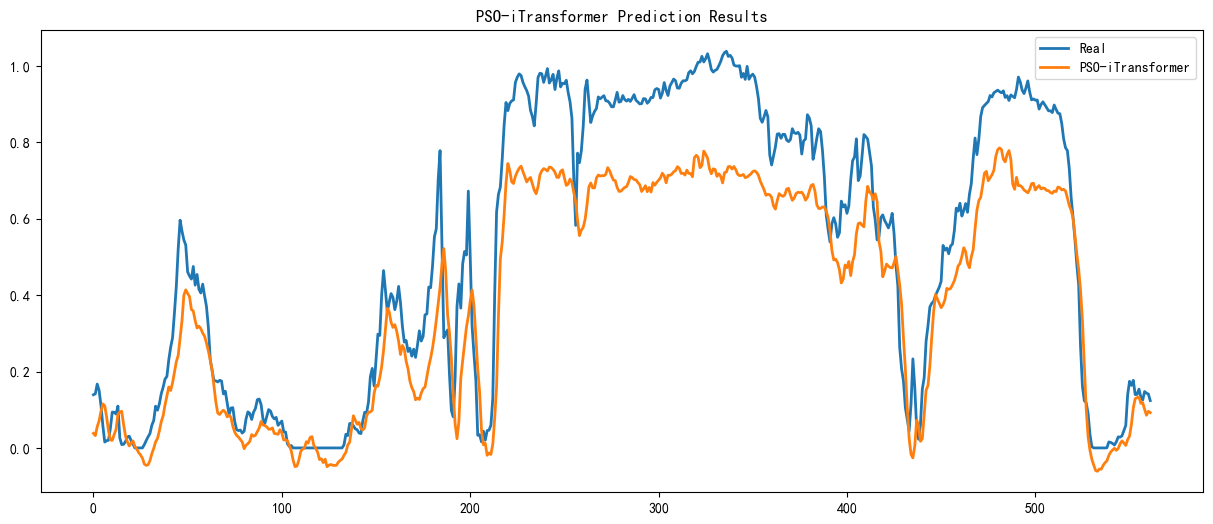

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from mealpy.swarm_based.PSO import OriginalPSO

import warnings
warnings.filterwarnings("ignore")
# ==============================================

# ===================== 你的数据（完全不变） =====================
train_X1 = x_spring_train.values.reshape((-1, 58, 1))
test_X1  = x_spring_test.values.reshape((-1, 58, 1))
val_X1   = x_spring_val.values.reshape((-1, 58, 1))

y_train = y_spring_train.values.ravel()
y_val   = y_spring_val.values.ravel()
y_test  = y_spring_test.values.ravel()

print("train_X1.shape:", train_X1.shape)
print("test_X1.shape:", test_X1.shape)

# ===================== iTransformer 模型（带PSO可调参数） =====================
class TransposeLayer(layers.Layer):
    def call(self, x):
        return tf.transpose(x, perm=[0, 2, 1])

def iTransformer_model(d_model, learning_rate):
    inputs = Input(shape=(58, 1))
    
    # 核心改进
    x = TransposeLayer()(inputs)
    x = layers.Dense(int(d_model))(x)
    
    # 自注意力
    x = layers.MultiHeadAttention(num_heads=2, key_dim=int(d_model)//2)(x, x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.Dropout(0.1)(x)
    
    # 前馈
    x = layers.Dense(int(d_model)*2, activation="gelu")(x)
    x = layers.Dense(int(d_model))(x)
    
    # 输出
    x = layers.GlobalAveragePooling1D()(x)
    outputs = layers.Dense(1)(x)
    
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mse")
    return model

# ===================== 完全照搬你 LSTM 的 PSO 格式 =====================
def cross_val(nest):
    d_model, epochs, learning_rate = nest
    model = iTransformer_model(d_model, learning_rate)
    model.fit(val_X1, y_val, epochs=int(epochs), batch_size=32, verbose=0, shuffle=False)
    y_pre = model.predict(val_X1, verbose=0)
    MSE = mean_squared_error(y_val, y_pre)
    return MSE

def fitness_function(nest):
    MSE = cross_val(nest)
    return MSE

def get_nest():
    problem_dict1 = {
         "fit_func": fitness_function,
         "lb":[16, 10, 1e-04],    # 维度、轮次、学习率 下限
         "ub":[48, 30, 1e-02],    # 维度、轮次、学习率 上限
         "minmax": "min",
         "verbose": True,
    } 
    epoch = 2
    pop_size = 16
    c1 = 2.05
    c2 = 2.05
    w_min = 0.4
    w_max = 0.9
    model = OriginalPSO(epoch, pop_size, c1, c2, w_min, w_max)
    best_position, best_fitness = model.solve(problem_dict1)
    print(f"最优参数: {best_position}, 最优MSE: {best_fitness}")
    return [best_fitness, best_position]

# ===================== 执行PSO寻优 =====================
nest = get_nest()
d_model = nest[1][0]
epochs  = nest[1][1]
lr      = nest[1][2]

# ===================== 训练最终模型 =====================
final_model = iTransformer_model(d_model, lr)
final_model.fit(train_X1, y_train, epochs=int(epochs), batch_size=16, verbose=2, shuffle=False)

# ===================== 预测 & 指标 =====================
y_pre_itrans = final_model.predict(test_X1)

r2 = r2_score(y_test, y_pre_itrans)
mse = mean_squared_error(y_test, y_pre_itrans)
mae = mean_absolute_error(y_test, y_pre_itrans)
mape = mean_absolute_percentage_error(y_test, y_pre_itrans)
rmse = np.sqrt(mse)

print("\n======= PSO-iTransformer (2026 SOTA) 结果 =======")
print(f"R²    = {r2:.4f}")
print(f"MSE   = {mse:.4f}")
print(f"RMSE  = {rmse:.4f}")
print(f"MAE   = {mae:.4f}")
print(f"MAPE  = {mape:.4f}")

# ===================== 绘图 =====================
plt.figure(figsize=(15,6))
plt.plot(y_test, label='Real', linewidth=2)
plt.plot(y_pre_itrans, label='PSO-iTransformer', linewidth=2)
plt.legend()
plt.title('PSO-iTransformer Prediction Results')
plt.show()

In [21]:
import pandas as pd
import numpy as np
import os

# ===================== 【自动创建文件夹】 =====================
directory = 'D:\\article'
if not os.path.exists(directory):
    os.makedirs(directory)

# ===================== 计算最大值、最小值（和你原来完全一样） =====================
scaler_max = spring_y_test.values.max()
scaler_min = spring_y_test.values.min()
print("归一化的最大值:", scaler_max)
print("归一化的最小值:", scaler_min)

# ===================== 反归一化函数 =====================
def inverse_transform(y_pred_scaled, y_actual_scaled, scaler_min, scaler_max):
    y_pred = y_pred_scaled * (scaler_max - scaler_min) + scaler_min
    y_actual = y_actual_scaled * (scaler_max - scaler_min) + scaler_min
    return y_pred, y_actual

# ===================== 【替换成 iTransformer 预测变量】 =====================
# y_pre_itrans 是你iTransformer模型的预测值
y_pre_itrans_inv, y_spring_test_inv = inverse_transform(
    y_pre_itrans,          # iTransformer 预测值（替换原来的 y_pre_transformer）
    y_spring_test.values,
    scaler_min,
    scaler_max
)

# ===================== 计算误差 =====================
spring_itrans_error = y_spring_test_inv - y_pre_itrans_inv
print("反归一化后的预测误差计算完成！")

# ===================== 【保存所有结果到 D:\article 文件夹】 =====================
# 保存为 DataFrame
result_df = pd.DataFrame({
    '实际值_反归一化': y_spring_test_inv.ravel(),
    'iTransformer预测值_反归一化': y_pre_itrans_inv.ravel(),
    '预测误差': spring_itrans_error.ravel()
})

# 保存路径
save_path = os.path.join(directory, 'iTransformer_预测结果.xlsx')

# 保存为 Excel 文件
result_df.to_excel(save_path, index=False)

print(f"\n所有数据已保存至：{save_path}")
print("✅ 保存内容：实际值、iTransformer预测值、预测误差")

归一化的最大值: 63.736667
归一化的最小值: 0.0
反归一化后的预测误差计算完成！

所有数据已保存至：D:\article\iTransformer_预测结果.xlsx
✅ 保存内容：实际值、iTransformer预测值、预测误差


train_X1.shape: (1713, 58, 1)


2026/06/05 11:44:39 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: Solving single objective optimization problem.
2026/06/05 11:48:11 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >Problem: P, Epoch: 1, Current best: 0.015489791729502057, Global best: 0.015489791729502057, Runtime: 104.94811 seconds
2026/06/05 11:50:02 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >Problem: P, Epoch: 2, Current best: 0.015489791729502057, Global best: 0.015489791729502057, Runtime: 110.54493 seconds


最优参数: [4.08122904e+01 2.96053072e+01 3.48933780e-04], MSE: 0.015489791729502057
Epoch 1/29
108/108 - 2s - 22ms/step - loss: 0.0196
Epoch 2/29
108/108 - 0s - 3ms/step - loss: 0.0132
Epoch 3/29
108/108 - 0s - 3ms/step - loss: 0.0132
Epoch 4/29
108/108 - 0s - 3ms/step - loss: 0.0103
Epoch 5/29
108/108 - 0s - 3ms/step - loss: 0.0118
Epoch 6/29
108/108 - 0s - 3ms/step - loss: 0.0105
Epoch 7/29
108/108 - 0s - 3ms/step - loss: 0.0087
Epoch 8/29
108/108 - 0s - 3ms/step - loss: 0.0108
Epoch 9/29
108/108 - 0s - 3ms/step - loss: 0.0101
Epoch 10/29
108/108 - 0s - 3ms/step - loss: 0.0121
Epoch 11/29
108/108 - 0s - 3ms/step - loss: 0.0080
Epoch 12/29
108/108 - 0s - 3ms/step - loss: 0.0071
Epoch 13/29
108/108 - 0s - 3ms/step - loss: 0.0090
Epoch 14/29
108/108 - 0s - 3ms/step - loss: 0.0073
Epoch 15/29
108/108 - 0s - 3ms/step - loss: 0.0076
Epoch 16/29
108/108 - 0s - 3ms/step - loss: 0.0083
Epoch 17/29
108/108 - 0s - 3ms/step - loss: 0.0085
Epoch 18/29
108/108 - 0s - 3ms/step - loss: 0.0078
Epoch 19/2

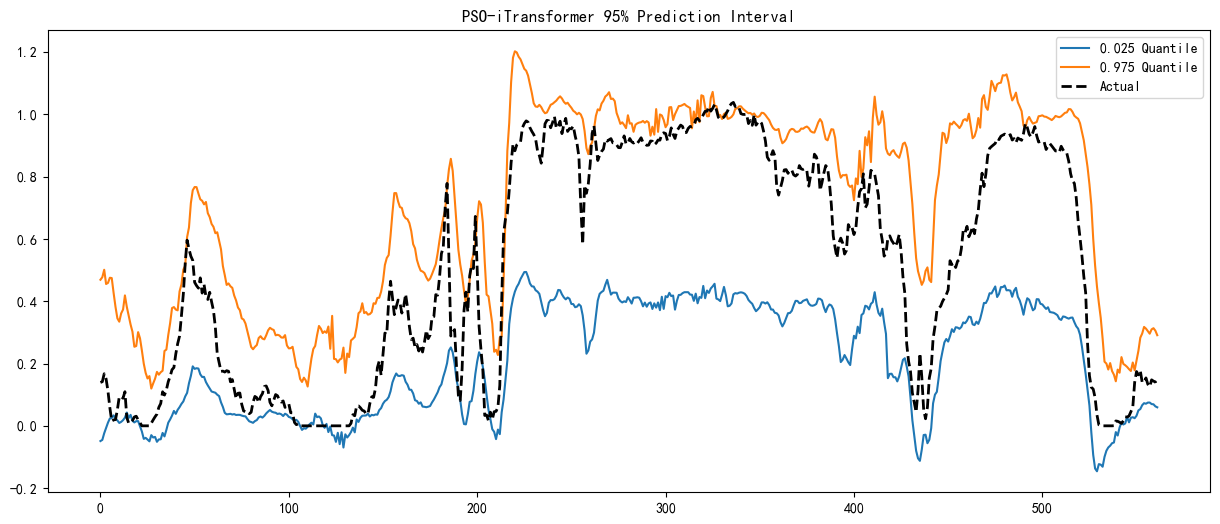

In [23]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt
from mealpy.swarm_based.PSO import OriginalPSO
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer, Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
import tensorflow as tf

# ===================== 数据（完全不变）=====================
train_X1 = x_spring_train.values.reshape((-1, 58, 1))
test_X1  = x_spring_test.values.reshape((-1, 58, 1))
val_X1   = x_spring_val.values.reshape((-1, 58, 1))

y_spring_train_flat = y_spring_train.values.ravel()
y_spring_val_flat   = y_spring_val.values.ravel()
y_spring_test_flat  = y_spring_test.values.ravel()

print("train_X1.shape:", train_X1.shape)

# ===================== 分位数损失函数（和你模板一样）=====================
def quantile_loss(y_true, y_pred, quantile):
    return K.mean(K.maximum(quantile * (y_true - y_pred), (quantile - 1) * (y_true - y_pred)), axis=-1)

# ===================== iTransformer 核心：转置层 =====================
class TransposeLayer(Layer):
    def call(self, x):
        return tf.transpose(x, perm=[0, 2, 1])

# ===================== iTransformer 模型（区间预测专用）=====================
def iTransformer_model(d_model, learning_rate, quantile):
    inputs = Input(shape=(58, 1))
    
    # iTransformer 核心结构
    x = TransposeLayer()(inputs)
    x = Dense(int(d_model))(x)
    
    x = MultiHeadAttention(num_heads=2, key_dim=int(d_model)//2)(x, x)
    x = LayerNormalization(epsilon=1e-6)(x)
    x = Dropout(0.2)(x)
    
    x = Dense(int(d_model)*2, activation="gelu")(x)
    x = Dense(int(d_model))(x)
    
    x = GlobalAveragePooling1D()(x)
    outputs = Dense(1)(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=learning_rate), 
                  loss=lambda y_true, y_pred: quantile_loss(y_true, y_pred, quantile))
    return model

# ===================== PSO 交叉验证（完全沿用你的模板）=====================
def cross_val(nest):
    d_model, epochs, learning_rate = nest
    model = iTransformer_model(d_model, learning_rate, quantile=0.5)
    model.fit(train_X1, y_spring_train_flat, epochs=int(epochs), batch_size=32, verbose=0, shuffle=False)
    y_pre = model.predict(val_X1, verbose=0)
    return mean_squared_error(y_spring_val_flat, y_pre)

def fitness_function(nest):
    return cross_val(nest)

# ===================== PSO 寻优 =====================
def get_nest():
    problem_dict1 = {
         "fit_func": fitness_function,
         "lb":[16, 10, 1e-04],
         "ub":[48, 30, 1e-02],
         "minmax": "min",
         "verbose": True,
    }
    epoch = 2
    pop_size = 16
    c1 = 2.05
    c2 = 2.05
    w_min = 0.4
    w_max = 0.9
    model = OriginalPSO(epoch, pop_size, c1, c2, w_min, w_max)
    best_position, best_fitness = model.solve(problem_dict1)
    print(f"最优参数: {best_position}, MSE: {best_fitness}")
    return [best_fitness, best_position]

# ===================== 执行PSO =====================
nest = get_nest()
d_model     = nest[1][0]
epochs      = nest[1][1]
lr          = nest[1][2]

# ===================== 95% 区间预测：0.025 / 0.975 =====================
quantiles = [0.025, 0.975]
predictions_itrans = {}

for q in quantiles:
    model = iTransformer_model(d_model, lr, q)
    model.fit(train_X1, y_spring_train_flat, epochs=int(epochs), batch_size=16, verbose=2, shuffle=False)
    pred = model.predict(test_X1)
    predictions_itrans[q] = pred

# ===================== 指标输出（和你模板完全一样）=====================
R2, mse, mae, mape, rmse = [], [], [], [], []

for q, y_pre in predictions_itrans.items():
    R2_q    = r2_score(y_spring_test_flat, y_pre)
    mse_q   = mean_squared_error(y_spring_test_flat, y_pre)
    mae_q   = mean_absolute_error(y_spring_test_flat, y_pre)
    mape_q  = mean_absolute_percentage_error(y_spring_test_flat, y_pre)
    rmse_q  = np.sqrt(mse_q)

    R2.append(R2_q)
    mse.append(mse_q)
    mae.append(mae_q)
    mape.append(mape_q)
    rmse.append(rmse_q)

    print(f"\n=== Quantile {q} ===")
    print(f"R²:    {R2_q:.4f}")
    print(f"MSE:   {mse_q:.4f}")
    print(f"MAE:   {mae_q:.4f}")
    print(f"MAPE:  {mape_q:.4f}")
    print(f"RMSE:  {rmse_q:.4f}")

# ===================== 绘图：95% 预测区间 =====================
plt.figure(figsize=(15,6))
plt.plot(predictions_itrans[0.025], label='0.025 Quantile', linewidth=1.5)
plt.plot(predictions_itrans[0.975], label='0.975 Quantile', linewidth=1.5)
plt.plot(y_spring_test_flat, 'k--', label='Actual', linewidth=2)
plt.title('PSO-iTransformer 95% Prediction Interval')
plt.legend()
plt.show()

In [24]:
# ===================== 计算 iTransformer 区间预测指标（95%）=====================
picp_95 = np.mean((y_spring_test.values >= predictions_itrans[0.025]) & (y_spring_test.values <= predictions_itrans[0.975]))
piaw_95 = np.mean(predictions_itrans[0.975] - predictions_itrans[0.025])
ace_95 = np.abs(0.95 - picp_95)
ais95 = np.mean((np.abs(y_spring_test.values - y_pre_itrans) / (predictions_itrans[0.975] - predictions_itrans[0.025])) ** 2)

itransformer_lb = predictions_itrans[0.025]  # 下限值
itransformer_ub = predictions_itrans[0.975]  # 上限值

print("PICP_95:", picp_95)
print("PIAW_95:", piaw_95)
print("ACE_95:", ace_95)
print("AIS_95:", ais95)

PICP_95: 0.9092526690391459
PIAW_95: 0.4958999
ACE_95: 0.040747330960854033
AIS_95: 0.09705857150532127


In [25]:
import pandas as pd
import numpy as np
import os

# 创建一个DataFrame来保存iTransformer区间数据
excel_data = {
    "iTransformer_Lower_Bound": itransformer_lb.flatten(),
    "iTransformer_Upper_Bound": itransformer_ub.flatten()
}

# 将数据转换为DataFrame
excel_df = pd.DataFrame(excel_data)

# 获取spring_y_test的最大值和最小值（和原代码完全一致）
scaler_max = spring_y_test.values.max()
scaler_min = spring_y_test.values.min()
print("归一化的最大值:", scaler_max)
print("归一化的最小值:", scaler_min)

# 反归一化函数（和原代码完全一致，无改动）
def inverse_normalize(value, scaler_min, scaler_max):
    return value * (scaler_max - scaler_min) + scaler_min

# 应用反归一化，仅替换模型名称
models = ["iTransformer"]
for model in models:
    model_lower_key = model + "_Lower_Bound"
    model_upper_key = model + "_Upper_Bound"
    excel_df[model_lower_key] = excel_df[model_lower_key].apply(lambda x: inverse_normalize(x, scaler_min, scaler_max))
    excel_df[model_upper_key] = excel_df[model_upper_key].apply(lambda x: inverse_normalize(x, scaler_min, scaler_max))

# 保存到Excel文件，路径不变，仅修改文件名对应iTransformer
directory = 'D:\\article'
file_path = os.path.join(directory, 'iTransformer_predictions_quantiles.xlsx')
excel_df.to_excel(file_path, index=False)

# 显示DataFrame
excel_df

归一化的最大值: 63.736667
归一化的最小值: 0.0


,iTransformer_Lower_Bound,iTransformer_Upper_Bound
0,-3.116279,29.890399
1,-2.878301,30.410509
2,-1.518540,31.936571
3,-0.407139,29.020230
4,0.650474,29.243909
...,...,...
557,4.763523,18.854007
558,4.451570,19.740145
559,4.404206,19.976262
560,3.983197,19.466024


train_X1.shape  (1713, 58, 1)
test_X1.shape  (562, 58, 1)


C:\Users\cwj20010310\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 58, 33)              │           4,620 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 58, 33)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 101)                 │          54,540 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             102 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 59,262 (231.49 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_98 (LSTM)                       │ (None, 58, 38)              │           6,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_49 (Dropout)                 │ (None, 58, 38)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_99 (LSTM)                       │ (None, 116)                 │          71,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_49 (Dense)                     │ (None, 1)                   │             117 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 78,117 (305.14 KB)

 Trainable params: 78,117 (305.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/37
172/172 - 7s - 40ms/step - loss: 0.0341
Epoch 2/37
172/172 - 5s - 27ms/step - loss: 0.0192
Epoch 3/37
172/172 - 5s - 26ms/step - loss: 0.0124
Epoch 4/37
172/172 - 5s - 26ms/step - loss: 0.0107
Epoch 5/37
172/172 - 5s - 26ms/step - loss: 0.0104
Epoch 6/37
172/172 - 5s - 27ms/step - loss: 0.0098
Epoch 7/37
172/172 - 5s - 27ms/step - loss: 0.0097
Epoch 8/37
172/172 - 5s - 27ms/step - loss: 0.0079
Epoch 9/37
172/172 - 5s - 27ms/step - loss: 0.0077
Epoch 10/37
172/172 - 5s - 27ms/step - loss: 0.0076
Epoch 11/37
172/172 - 5s - 28ms/step - loss: 0.0074
Epoch 12/37
172/172 - 5s - 27ms/step - loss: 0.0075
Epoch 13/37
172/172 - 5s - 26ms/step - loss: 0.0079
Epoch 14/37
172/172 - 5s - 28ms/step - loss: 0.0073
Epoch 15/37
172/172 - 5s - 27ms/step - loss: 0.0067
Epoch 16/37
172/172 - 5s - 27ms/step - loss: 0.0075
Epoch 17/37
172/172 - 5s - 26ms/step - loss: 0.0062
Epoch 18/37
172/172 - 5s - 27ms/step - loss: 0.0067
Epoch 19/37
172/172 - 5s - 27ms/step - loss: 0.0064
Epoch 20/37
172/172 -

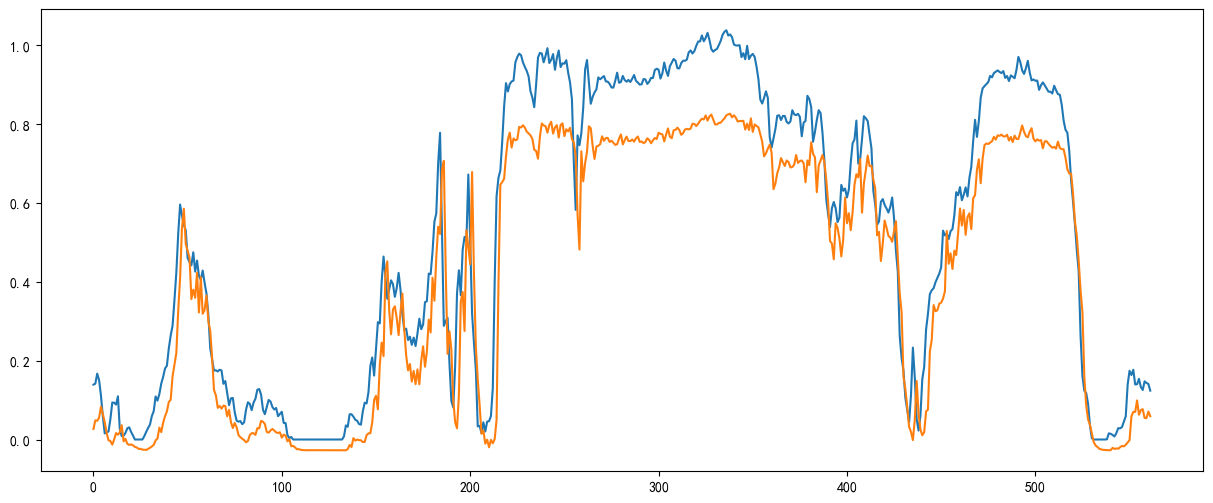

In [19]:
##成功的PSO-LSTM参数调优
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
from mealpy.swarm_based.PSO import OriginalPSO
from tensorflow.keras.optimizers import Adam
train_X1 = x_spring_train.values.reshape((x_spring_train.shape[0],58,1))
test_X1= x_spring_test.values.reshape((x_spring_test.shape[0],58,1))
print("train_X1.shape ",train_X1.shape)
print("test_X1.shape ",test_X1.shape)
def LSTM_model(units, learning_rate, train_X):
    # 使用Keras建构LSTM模型
    model = Sequential()
    model.add(LSTM(units=int(units), input_shape=(train_X1.shape[1], train_X1.shape[2]), return_sequences=True))
    model.add(Dropout(0.5))
    model.add(LSTM(units=int(units*3)))
    model.add(Dense(1))#输出几步数字为几
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse')
    model.summary()
    return model

def cross_val(nest):
    units,epochs,learning_rate = nest
    model=LSTM_model(units, learning_rate, x_spring_val)
    history = model.fit(x_spring_val, y_spring_val.values.ravel(), epochs=int(epochs), batch_size=64, verbose=2, shuffle=False)
    # 执行预测
    y_pre = model.predict(x_spring_val)
    # 计算MSE误差值
    MSE= mean_squared_error(y_spring_val.values.ravel(), y_pre)
    return MSE

#定义适应度函数
def fitness_function(nest):
    MSE = cross_val(nest)
    return MSE

def get_nest():
    # 适应度函数选择
    # units,epochs,learning_rate
    problem_dict1 = {
         "fit_func": fitness_function,
         "lb":[10,10,1e-04],
         "ub":[50,50,1e-02],
         "minmax": "min",
         "verbose": True,
    } 
    epoch = 2
    pop_size = 16
#大佬PSO优化函数已经封装好的，不用改动    
    c1 = 2.05
    c2 = 2.05
    w_min = 0.4
    w_max = 0.9
    model = OriginalPSO(epoch, pop_size, c1, c2, w_min, w_max)
    best_position, best_fitness = model.solve(problem_dict1)
    print(f"Solution: {best_position}, Fitness: {best_fitness}")
    return [best_fitness, best_position]#返回最优参数
#将获得的参数放入nest
nest=get_nest()
print(nest)
#取nest中的数赋给需要优化的参数
# units,epochs,learning_rate
units= nest[1][0]
epochs= nest[1][1]
learning_rate =nest[1][2]
model=LSTM_model(units, learning_rate, x_spring_train)
history = model.fit(x_spring_train, y_spring_train.values.ravel(), epochs=int(epochs), batch_size=10, verbose=2, shuffle=False)
# 执行预测
y_pre_lstm = model.predict(x_spring_test)
# 计算r方
R2_lstm = r2_score(y_spring_test.values.ravel(), y_pre_lstm)
print("计算得出的r方为：", R2_lstm)
mse_lstm= mean_squared_error(y_spring_test.values.ravel(), y_pre_lstm)
mae_lstm= mean_absolute_error(y_spring_test.values.ravel(), y_pre_lstm)
mape_lstm= mean_absolute_percentage_error(y_spring_test.values.ravel(), y_pre_lstm)
# 计算平方差
squared_diff_lstm = np.square(y_spring_test.values.ravel()- y_pre_lstm)
#计算均值
mean_squared_error_lstm = np.mean(squared_diff_lstm)
#计算RMSE
rmse_lstm= np.sqrt(mean_squared_error_lstm)
print("MSE： ", mse_lstm)
print("MAE:", mae_lstm)
print("MAPE:", mape_lstm)
print("RMSE:", rmse_lstm)
#绘制PSO-LSTM预测之后的模型
plt.figure(figsize=(15,6))
plt.plot(y_spring_test.values.ravel())
plt.plot(y_pre_lstm)
plt.show()

In [20]:
import pandas as pd

# 计算y_spring_test的最大值和最小值
scaler_max = spring_y_test.values.max()  # 如果y_spring_test是多维的，使用max().max()获取全局最大值
scaler_min = spring_y_test.values.min()  # 如果y_spring_test是多维的，使用min().min()获取全局最小值
print("归一化的最大值:", scaler_max)
print("归一化的最小值:", scaler_min)

# 反归一化函数
def inverse_transform(y_pred_scaled, y_actual_scaled, scaler_min, scaler_max):
    y_pred = y_pred_scaled * (scaler_max - scaler_min) + scaler_min
    y_actual = y_actual_scaled * (scaler_max - scaler_min) + scaler_min
    return y_pred, y_actual

# 确保 y_pre_lstm 和 y_spring_test.values.ravel() 是一维数组
# 反归一化预测值和实际值
y_pre_lstm_inv, y_spring_test_inv = inverse_transform(y_pre_lstm, y_spring_test.values, scaler_min, scaler_max)
# 计算预测误差
spring_lstm_error = y_spring_test_inv - y_pre_lstm_inv
spring_lstm_error

归一化的最大值: 63.736667
归一化的最小值: 0.0


array([[ 7.17746330e+00],
       [ 5.93661872e+00],
       [ 7.61865417e+00],
       [ 6.08661055e+00],
       [ 1.77670404e+00],
       [-4.09803342e-01],
       [-1.79408034e+00],
       [ 1.41099160e-01],
       [ 1.41247463e+00],
       [ 3.53837521e+00],
       [ 6.81043377e+00],
       [ 5.93046201e+00],
       [ 4.61296883e+00],
       [ 6.20932991e+00],
       [ 4.92357333e-01],
       [-1.75633645e+00],
       [ 8.95438275e-01],
       [ 9.62473965e-01],
       [ 2.52530202e+00],
       [ 2.83522346e+00],
       [ 2.02233759e+00],
       [ 1.57041190e+00],
       [ 1.19803405e+00],
       [ 1.29114008e+00],
       [ 1.52200532e+00],
       [ 1.50988460e+00],
       [ 1.63550055e+00],
       [ 2.18383508e+00],
       [ 2.91594108e+00],
       [ 3.36906533e+00],
       [ 3.74801531e+00],
       [ 4.91138100e+00],
       [ 5.44569211e+00],
       [ 7.10060811e+00],
       [ 6.13961128e+00],
       [ 5.44458211e+00],
       [ 7.84745975e+00],
       [ 7.40848910e+00],
       [ 7.7

train_X1.shape  (1713, 58, 1)
test_X1.shape  (562, 58, 1)


C:\Users\cwj20010310\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_102"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_102 (LSTM)                      │ (None, 58, 44)              │           8,096 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_51 (Dropout)                 │ (None, 58, 44)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_103 (LSTM)                      │ (None, 88)                  │          46,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_102 (Dense)                    │ (None, 1)                   │              89 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 55,001 (214.85 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_202 (LSTM)                      │ (None, 58, 56)              │          12,992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_101 (Dropout)                │ (None, 58, 56)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_203 (LSTM)                      │ (None, 112)                 │          75,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_152 (Dense)                    │ (None, 1)                   │             113 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 88,817 (346.94 KB)

 Trainable params: 88,817 (346.94 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/44
172/172 - 6s - 37ms/step - loss: 0.0142
Epoch 2/44
172/172 - 4s - 26ms/step - loss: 0.0152
Epoch 3/44
172/172 - 4s - 26ms/step - loss: 0.0146
Epoch 4/44
172/172 - 4s - 26ms/step - loss: 0.0109
Epoch 5/44
172/172 - 5s - 26ms/step - loss: 0.0099
Epoch 6/44
172/172 - 5s - 26ms/step - loss: 0.0085
Epoch 7/44
172/172 - 4s - 26ms/step - loss: 0.0081
Epoch 8/44
172/172 - 4s - 26ms/step - loss: 0.0068
Epoch 9/44
172/172 - 4s - 26ms/step - loss: 0.0072
Epoch 10/44
172/172 - 4s - 26ms/step - loss: 0.0063
Epoch 11/44
172/172 - 4s - 26ms/step - loss: 0.0065
Epoch 12/44
172/172 - 4s - 26ms/step - loss: 0.0075
Epoch 13/44
172/172 - 4s - 26ms/step - loss: 0.0065
Epoch 14/44
172/172 - 4s - 26ms/step - loss: 0.0092
Epoch 15/44
172/172 - 4s - 26ms/step - loss: 0.0069
Epoch 16/44
172/172 - 4s - 26ms/step - loss: 0.0061
Epoch 17/44
172/172 - 4s - 26ms/step - loss: 0.0057
Epoch 18/44
172/172 - 4s - 26ms/step - loss: 0.0058
Epoch 19/44
172/172 - 5s - 26ms/step - loss: 0.0060
Epoch 20/44
172/172 -

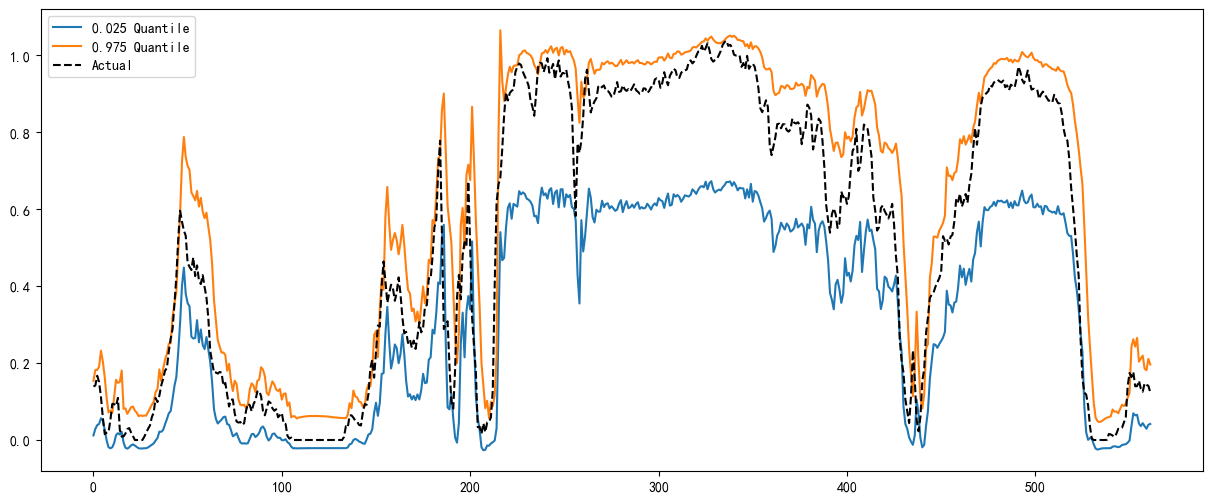

In [23]:
##LSTM区间预测（95%）
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
from mealpy.swarm_based.PSO import OriginalPSO
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K
train_X1 = x_spring_train.values.reshape((x_spring_train.shape[0],58,1))
test_X1= x_spring_test.values.reshape((x_spring_test.shape[0],58,1))
val_X1= x_spring_val.values.reshape((x_spring_val.shape[0],58,1))
print("train_X1.shape ",train_X1.shape)
print("test_X1.shape ",test_X1.shape)

# 分位数损失函数
def quantile_loss(y_true, y_pred, quantile):
    return K.mean(K.maximum(quantile * (y_true - y_pred), (quantile - 1) * (y_true - y_pred)), axis=-1)

# LSTM模型
def LSTM_model(units, learning_rate, train_X, quantile):
    # 使用Keras建构LSTM模型
    model = Sequential()
    model.add(LSTM(units=int(units), input_shape=(train_X1.shape[1], train_X1.shape[2]), return_sequences=True))
    model.add(Dropout(0.4))
    model.add(LSTM(units=int(units*2)))
    model.add(Dense(1))  # 输出层
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss=lambda y_true, y_pred: quantile_loss(y_true, y_pred, quantile))
    model.summary()
    return model

# 适应度函数
def fitness_function(nest):
    units, epochs, learning_rate, quantile = nest
    MSE = cross_val([units, epochs, learning_rate, quantile])
    return MSE

# 交叉验证
def cross_val(nest):
    units, epochs, learning_rate, quantile = nest
    model = LSTM_model(units, learning_rate, train_X1, quantile)
    history = model.fit(train_X1, y_spring_train.values.ravel(), epochs=int(epochs), batch_size=64, verbose=2, shuffle=False)
    y_pre_qlstm = model.predict(val_X1)
    MSE = mean_squared_error(y_spring_val.values.ravel(), y_pre_qlstm)
    return MSE

# 获取最佳参数
def get_nest(): 
    problem_dict1 = {
        "fit_func": fitness_function,
        "lb": [20, 20, 1e-05, 0.025],  # 参数的下限
        "ub": [60, 60, 1e-02, 0.975],  # 参数的上限
        "minmax": "min",
        "verbose": True,
    }
    epoch = 2
    pop_size = 16
    c1 = 2.05
    c2 = 2.05
    w_min = 0.4
    w_max = 0.9
    model = OriginalPSO(epoch, pop_size, c1, c2, w_min, w_max)
    best_position, best_fitness = model.solve(problem_dict1)
    print(f"Solution: {best_position}, Fitness: {best_fitness}")
    return [best_fitness, best_position]

# 获取最佳参数
nest = get_nest()
print(nest)

# 取nest中的数赋给需要优化的参数
units = nest[1][0]
epochs = nest[1][1]
learning_rate = nest[1][2]

# 构建并训练LSTM模型，分别预测0.025和0.975分位数
quantiles = [0.025, 0.975]
predictions_qlstm = {}

for quantile in quantiles:
    model = LSTM_model(units, learning_rate, train_X1, quantile)
    history = model.fit(train_X1, y_spring_train.values.ravel(), epochs=int(epochs), batch_size=10, verbose=2, shuffle=False)
    y_pre_qlstm = model.predict(test_X1)
    predictions_qlstm[quantile] = y_pre_qlstm

# 计算评估指标
R2, mse, mae, mape, rmse = [], [], [], [], []

for quantile, y_pre in predictions_qlstm.items():
    R2_qlstm = r2_score(y_spring_test.values.ravel(), y_pre_qlstm)
    mse_qlstm = mean_squared_error(y_spring_test.values.ravel(), y_pre_qlstm)
    mae_qlstm = mean_absolute_error(y_spring_test.values.ravel(), y_pre_qlstm)
    mape_qlstm = mean_absolute_percentage_error(y_spring_test.values.ravel(), y_pre_qlstm)
    rmse_qlstm = np.sqrt(mse_qlstm)

    R2.append(R2_qlstm)
    mse.append(mse_qlstm)
    mae.append(mae_qlstm)
    mape.append(mape_qlstm)
    rmse.append(rmse_qlstm)

    print(f"Quantile {quantile}:")
    print("计算得出的r方为：", R2_qlstm)
    print("MSE： ", mse_qlstm)
    print("MAE:", mae_qlstm)
    print("MAPE:", mape_qlstm)
    print("RMSE:", rmse_qlstm)

# 绘制PSO-LSTM预测之后的模型
plt.figure(figsize=(15,6))
for quantile, y_pre_qlstm in predictions_qlstm.items():
    plt.plot(y_pre_qlstm, label=f'{quantile} Quantile')

plt.plot(y_spring_test.values.ravel(), 'k--', label='Actual')
plt.legend()
plt.show()

In [24]:
#计算区间预测指标
picp_95 = np.mean((y_spring_test.values >= predictions_qlstm[0.025]) & (y_spring_test.values <= predictions_qlstm[0.975]))
piaw_95 = np.mean(predictions_qlstm[0.975] - predictions_qlstm[0.025])
ace_95 = np.abs(0.95 - picp_95)
ais95 = np.mean((np.abs(y_spring_test.values - y_pre_qlstm) / (predictions_qlstm[0.975] - predictions_qlstm[0.025])) ** 2)
lstm_lb= predictions_qlstm[0.025]  # 下限值
lstm_ub = predictions_qlstm[0.975]  # 上限值
print(picp_95,piaw_95,ace_95,ais95)

0.9217081850533808 0.28157562 0.028291814946619143 0.24733309023752018


train_X1.shape: (1713, 58, 1)
test_X1.shape: (562, 58, 1)


C:\Users\cwj20010310\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_691"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_980 (Conv1D)                  │ (None, 58, 49)              │             245 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_590 (Dropout)                │ (None, 58, 49)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_981 (Conv1D)                  │ (None, 58, 99)              │          19,503 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_490 (Flatten)                │ (None, 5742)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_691 (Dense)                    │ (None, 1)                   │           5,743 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,491 (99.57 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_1174 (Conv1D)                 │ (None, 58, 49)              │             196 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_687 (Dropout)                │ (None, 58, 49)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1175 (Conv1D)                 │ (None, 58, 99)              │          14,652 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_587 (Flatten)                │ (None, 5742)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_788 (Dense)                    │ (None, 1)                   │           5,743 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,591 (80.43 KB)

 Trainable params: 20,591 (80.43 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/54
172/172 - 2s - 9ms/step - loss: 0.0412
Epoch 2/54
172/172 - 1s - 4ms/step - loss: 0.0302
Epoch 3/54
172/172 - 1s - 4ms/step - loss: 0.0212
Epoch 4/54
172/172 - 1s - 4ms/step - loss: 0.0176
Epoch 5/54
172/172 - 1s - 4ms/step - loss: 0.0166
Epoch 6/54
172/172 - 1s - 4ms/step - loss: 0.0153
Epoch 7/54
172/172 - 1s - 3ms/step - loss: 0.0140
Epoch 8/54
172/172 - 1s - 4ms/step - loss: 0.0137
Epoch 9/54
172/172 - 1s - 4ms/step - loss: 0.0140
Epoch 10/54
172/172 - 1s - 4ms/step - loss: 0.0136
Epoch 11/54
172/172 - 1s - 4ms/step - loss: 0.0134
Epoch 12/54
172/172 - 1s - 4ms/step - loss: 0.0132
Epoch 13/54
172/172 - 1s - 4ms/step - loss: 0.0129
Epoch 14/54
172/172 - 1s - 4ms/step - loss: 0.0128
Epoch 15/54
172/172 - 1s - 4ms/step - loss: 0.0120
Epoch 16/54
172/172 - 1s - 4ms/step - loss: 0.0107
Epoch 17/54
172/172 - 1s - 4ms/step - loss: 0.0112
Epoch 18/54
172/172 - 1s - 4ms/step - loss: 0.0107
Epoch 19/54
172/172 - 1s - 4ms/step - loss: 0.0108
Epoch 20/54
172/172 - 1s - 4ms/step - lo

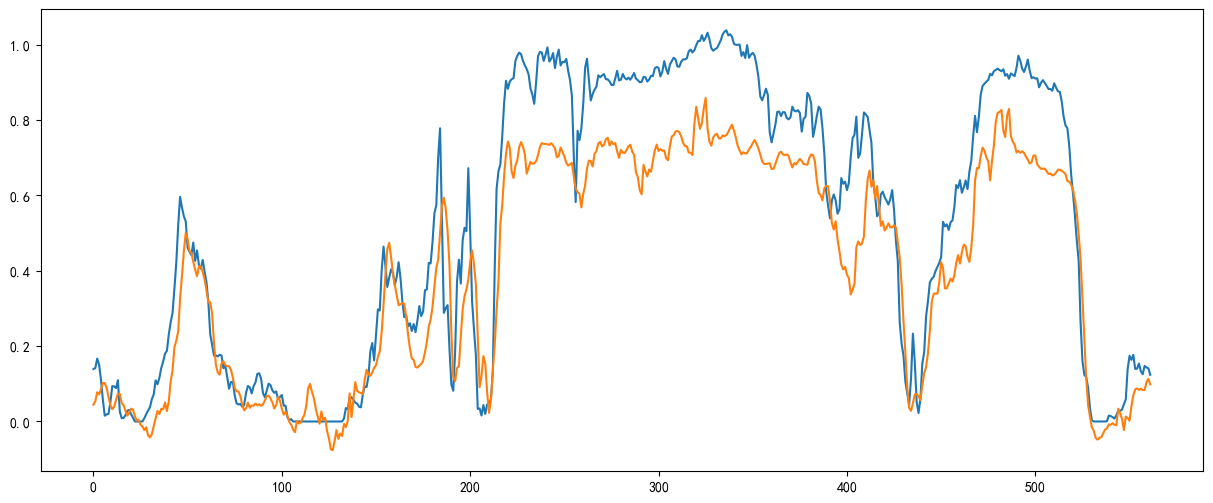

In [38]:
##成功的PSO-TCN参数调优  
from sklearn.metrics import mean_squared_error  
from mealpy.swarm_based.PSO import OriginalPSO  
from tensorflow.keras.optimizers import Adam  
from tensorflow.keras.layers import Conv1D, Dense, Dropout, Flatten  
from tensorflow.keras.models import Sequential  

# 调整 train_X1 和 test_X1 的形状  
train_X1 = x_spring_train.values.reshape((x_spring_train.shape[0], 58, 1))  
test_X1 = x_spring_test.values.reshape((x_spring_test.shape[0], 58, 1))
val_X1 = x_spring_val.values.reshape((x_spring_val.shape[0], 58, 1))

print("train_X1.shape:", train_X1.shape)  
print("test_X1.shape:", test_X1.shape)  

# 在TCN_model 函数中，确保kernel_size为整数  
def TCN_model(filters, kernel_size, learning_rate):  
    model = Sequential()  
    model.add(Conv1D(filters=int(filters), kernel_size=int(kernel_size), padding='causal', activation='relu', input_shape=(train_X1.shape[1], train_X1.shape[2])))  
    model.add(Dropout(0.4))  
    model.add(Conv1D(filters=int(filters*2), kernel_size=int(kernel_size), padding='causal', activation='relu'))  
    model.add(Flatten())  
    model.add(Dense(1))  # 输出层  

    optimizer = Adam(learning_rate=learning_rate)  
    model.compile(optimizer=optimizer, loss='mse')  
    model.summary()  
    return model  

def cross_val(nest):  
    filters, kernel_size, epochs, learning_rate = nest  
    model = TCN_model(filters, kernel_size, learning_rate)  

    # 确保在交叉验证中使用的是适当的训练集，而不是验证集  
    history = model.fit(train_X1, y_spring_train.values.ravel(), epochs=int(epochs), batch_size=64, verbose=2, shuffle=False)  

    # 在验证集上进行预测并计算 MSE  
    y_pre = model.predict(test_X1)  # 使用测试集进行预测  
    MSE = mean_squared_error(y_spring_val.values.ravel(), y_pre)  
    return MSE  

# 同样在fitness_function中确保传递的kernel_size为整数  
def fitness_function(nest):  
    # 将kernel_size转换为最接近的整数  
    kernel_size = round(nest[1])  
    nest_int = [nest[0], kernel_size, nest[2], nest[3]]  # 重建nest，确保kernel_size为整数  
    MSE = cross_val(nest_int)  
    return MSE

def get_nest():  
    problem_dict1 = {  
        "fit_func": fitness_function,  
        "lb": [30, 2, 30, 1e-06],  # 参数的下限  
        "ub": [60, 5, 60, 1e-03],  # 参数的上限  
        "minmax": "min",  
        "verbose": True,  
    }  
    epochs = 5  
    pop_size = 16  
    c1 = 2.05  
    c2 = 2.05  
    w_min = 0.4  
    w_max = 0.9  
    model = OriginalPSO(epochs, pop_size, c1, c2, w_min, w_max)  

    best_position, best_fitness = model.solve(problem_dict1)  
    print(f"Solution: {best_position}, Fitness: {best_fitness}")  
    return [best_fitness, best_position]  

# 获取最佳参数  
nest = get_nest()  
print(nest)  

# 取nest中的数赋给需要优化的参数  
filters = nest[1][0]  
kernel_size = nest[1][1]  
epochs = nest[1][2]  
learning_rate = nest[1][3]  

# 构建并训练TCN模型  
model = TCN_model(filters, kernel_size, learning_rate)  
history = model.fit(train_X1, y_spring_train.values.ravel(), epochs=int(epochs), batch_size=10, verbose=2, shuffle=False)  

# 执行预测  
y_pre_tcn = model.predict(test_X1)  

# 计算r方  
R2_tcn = r2_score(y_spring_test.values.ravel(), y_pre_tcn)  
print("计算得出的r方为：", R2_tcn)  

# 计算评估指标  
mse_tcn = mean_squared_error(y_spring_test.values.ravel(), y_pre_tcn)  
mae_tcn = mean_absolute_error(y_spring_test.values.ravel(), y_pre_tcn)  
mape_tcn = mean_absolute_percentage_error(y_spring_test.values.ravel(), y_pre_tcn)  

# 计算RMSE
rmse_tcn= np.sqrt(mse_tcn)
print("MSE： ", mse_tcn)
print("MAE:", mae_tcn)
print("MAPE:", mape_tcn)
print("RMSE:", rmse_tcn)
#绘制PSO-TCN预测之后的模型
plt.figure(figsize=(15,6))
plt.plot(y_spring_test.values.ravel())
plt.plot(y_pre_tcn)
plt.show()

In [39]:
import pandas as pd

# 计算y_spring_test的最大值和最小值
scaler_max = spring_y_test.values.max()  # 如果y_spring_test是多维的，使用max().max()获取全局最大值
scaler_min = spring_y_test.values.min()  # 如果y_spring_test是多维的，使用min().min()获取全局最小值
print("归一化的最大值:", scaler_max)
print("归一化的最小值:", scaler_min)

# 反归一化函数
def inverse_transform(y_pred_scaled, y_actual_scaled, scaler_min, scaler_max):
    y_pred = y_pred_scaled * (scaler_max - scaler_min) + scaler_min
    y_actual = y_actual_scaled * (scaler_max - scaler_min) + scaler_min
    return y_pred, y_actual

# 确保 y_pre_tcn 和 y_spring_test.values.ravel() 是一维数组
# 反归一化预测值和实际值
y_pre_tcn_inv, y_spring_test_inv = inverse_transform(y_pre_tcn, y_spring_test.values, scaler_min, scaler_max)
# 计算预测误差
spring_tcn_error = y_spring_test_inv - y_pre_tcn_inv
spring_tcn_error

归一化的最大值: 63.736667
归一化的最小值: 0.0


array([[  6.03188205],
       [  5.57623211],
       [  5.70112554],
       [  5.03105616],
       [  1.63769504],
       [ -2.80853839],
       [ -5.52695735],
       [ -4.49253886],
       [ -2.84706076],
       [  0.54040926],
       [  3.89133342],
       [  3.46367356],
       [  2.05333474],
       [  2.23003466],
       [ -2.96369604],
       [ -2.54743958],
       [ -2.19074903],
       [ -0.70928609],
       [  0.84073362],
       [  0.48017021],
       [ -0.94794765],
       [ -1.38405057],
       [ -0.88360786],
       [ -0.14439435],
       [ -0.26715434],
       [  0.54319167],
       [  0.80160642],
       [  1.98929958],
       [  2.19881691],
       [  4.18915193],
       [  5.09323778],
       [  5.94220006],
       [  5.34483051],
       [  6.43770513],
       [  4.50829249],
       [  6.09677661],
       [  6.88561518],
       [  8.07370841],
       [  8.26879469],
       [ 10.17272328],
       [ 11.28705656],
       [ 10.02686483],
       [  9.69135332],
       [  9

train_X1.shape: (1713, 58, 1)
test_X1.shape: (562, 58, 1)


C:\Users\cwj20010310\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_485"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_664 (Conv1D)                  │ (None, 58, 30)              │             150 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_434 (Dropout)                │ (None, 58, 30)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_665 (Conv1D)                  │ (None, 58, 91)              │          11,011 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_332 (Flatten)                │ (None, 5278)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_485 (Dense)                    │ (None, 1)                   │           5,279 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,440 (64.22 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_764 (Conv1D)                  │ (None, 58, 47)              │             141 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_484 (Dropout)                │ (None, 58, 47)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_765 (Conv1D)                  │ (None, 58, 143)             │          13,585 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_382 (Flatten)                │ (None, 8294)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_535 (Dense)                    │ (None, 1)                   │           8,295 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,021 (86.02 KB)

 Trainable params: 22,021 (86.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/44
172/172 - 1s - 7ms/step - loss: 0.0143
Epoch 2/44
172/172 - 0s - 2ms/step - loss: 0.0114
Epoch 3/44
172/172 - 0s - 2ms/step - loss: 0.0115
Epoch 4/44
172/172 - 0s - 2ms/step - loss: 0.0097
Epoch 5/44
172/172 - 0s - 2ms/step - loss: 0.0094
Epoch 6/44
172/172 - 0s - 2ms/step - loss: 0.0081
Epoch 7/44
172/172 - 0s - 2ms/step - loss: 0.0072
Epoch 8/44
172/172 - 0s - 3ms/step - loss: 0.0073
Epoch 9/44
172/172 - 0s - 2ms/step - loss: 0.0076
Epoch 10/44
172/172 - 0s - 2ms/step - loss: 0.0087
Epoch 11/44
172/172 - 0s - 2ms/step - loss: 0.0079
Epoch 12/44
172/172 - 0s - 2ms/step - loss: 0.0069
Epoch 13/44
172/172 - 0s - 2ms/step - loss: 0.0059
Epoch 14/44
172/172 - 0s - 2ms/step - loss: 0.0066
Epoch 15/44
172/172 - 0s - 2ms/step - loss: 0.0070
Epoch 16/44
172/172 - 0s - 2ms/step - loss: 0.0068
Epoch 17/44
172/172 - 0s - 2ms/step - loss: 0.0060
Epoch 18/44
172/172 - 0s - 2ms/step - loss: 0.0061
Epoch 19/44
172/172 - 0s - 2ms/step - loss: 0.0052
Epoch 20/44
172/172 - 0s - 2ms/step - lo

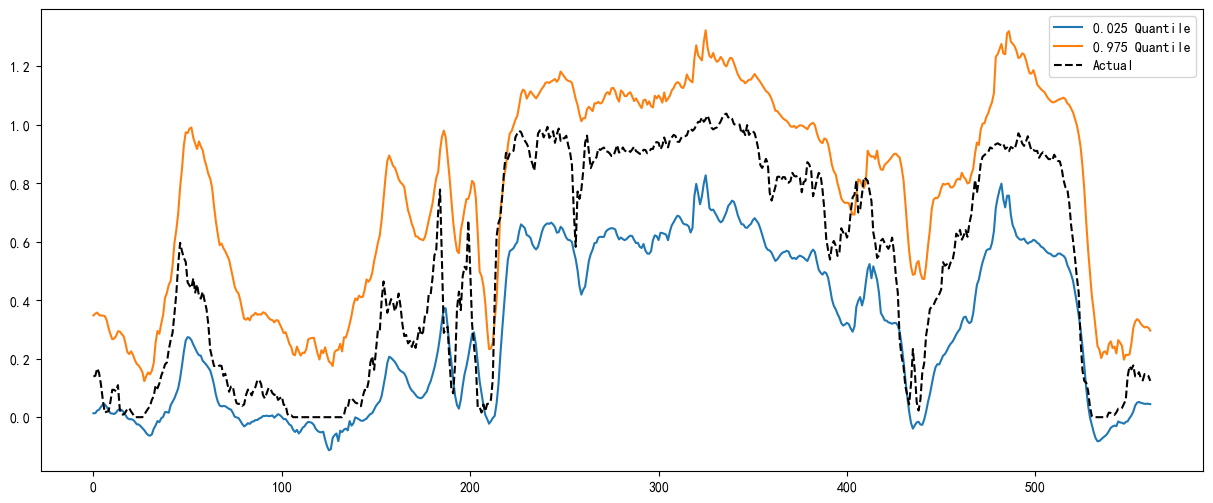

In [66]:
#TCN区间预测（95%）
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from mealpy.swarm_based.PSO import OriginalPSO
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv1D, Dense, Dropout, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras import backend as K

# 调整 train_X1 和 test_X1 的形状
train_X1 = x_spring_train.values.reshape((x_spring_train.shape[0], 58, 1))
test_X1 = x_spring_test.values.reshape((x_spring_test.shape[0], 58, 1))
val_X1 = x_spring_val.values.reshape((x_spring_val.shape[0], 58, 1))

print("train_X1.shape:", train_X1.shape)
print("test_X1.shape:", test_X1.shape)

# 分位数损失函数
def quantile_loss(y_true, y_pred, quantile):
    return K.mean(K.maximum(quantile * (y_true - y_pred), (quantile - 1) * (y_true - y_pred)), axis=-1)

# TCN模型
def TCN_model(filters, kernel_size, learning_rate, quantile):
    model = Sequential()
    model.add(Conv1D(filters=int(filters), kernel_size=int(kernel_size), padding='causal', activation='relu', input_shape=(train_X1.shape[1], train_X1.shape[2])))
    model.add(Dropout(0.5))
    model.add(Conv1D(filters=int(filters*3), kernel_size=int(kernel_size), padding='causal', activation='relu'))
    model.add(Flatten())
    model.add(Dense(1))  # 输出层
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss=lambda y_true, y_pred: quantile_loss(y_true, y_pred, quantile))
    model.summary()
    return model

# 交叉验证
def cross_val(nest):
    filters, kernel_size, epochs, learning_rate, quantile = nest
    model = TCN_model(filters, kernel_size, learning_rate, quantile)
    history = model.fit(train_X1, y_spring_train.values.ravel(), epochs=int(epochs), batch_size=64, verbose=2, shuffle=False)
    y_pre_qtcn = model.predict(val_X1)
    MSE = mean_squared_error(y_spring_val.values.ravel(), y_pre_qtcn)
    return MSE

# 适应度函数
def fitness_function(nest):
    kernel_size = round(nest[1])
    nest_int = [nest[0], kernel_size, nest[2], nest[3], 0.95]  # 95%分位数
    MSE = cross_val(nest_int)
    return MSE

# 获取最佳参数
def get_nest(): 
    problem_dict1 = {
        "fit_func": fitness_function,
        "lb": [30, 2, 30, 1e-06, 0.025],  # 参数的下限
        "ub": [60, 5, 60, 1e-03, 0.975],  # 参数的上限
        "minmax": "min",
        "verbose": True,
    }
    epochs = 2
    pop_size = 16
    c1 = 2.05
    c2 = 2.05
    w_min = 0.4
    w_max = 0.9
    model = OriginalPSO(epochs, pop_size, c1, c2, w_min, w_max)
    best_position, best_fitness = model.solve(problem_dict1)
    print(f"Solution: {best_position}, Fitness: {best_fitness}")
    return [best_fitness, best_position]

# 获取最佳参数
nest = get_nest()
print(nest)

# 取nest中的数赋给需要优化的参数
filters = nest[1][0]
kernel_size = nest[1][1]
epochs = nest[1][2]
learning_rate = nest[1][3]

# 构建并训练TCN模型，分别预测0.025和0.975分位数
quantiles = [0.025, 0.975]
predictions = {}

for quantile in quantiles:
    model = TCN_model(filters, kernel_size, learning_rate, quantile)
    history = model.fit(train_X1, y_spring_train.values.ravel(), epochs=int(epochs), batch_size=10, verbose=2, shuffle=False)
    y_pre_qtcn = model.predict(test_X1)
    predictions[quantile] = y_pre_qtcn

# 计算评估指标
R2, mse, mae, mape, rmse = [], [], [], [], []

for quantile, y_pre_qtcn in predictions.items():
    R2_qtcn = r2_score(y_spring_test.values.ravel(), y_pre_qtcn)
    mse_qtcn = mean_squared_error(y_spring_test.values.ravel(), y_pre_qtcn)
    mae_qtcn = mean_absolute_error(y_spring_test.values.ravel(), y_pre_qtcn)
    mape_qtcn = mean_absolute_percentage_error(y_spring_test.values.ravel(), y_pre_qtcn)
    rmse_qtcn = np.sqrt(mse_qtcn)

    R2.append(R2_qtcn)
    mse.append(mse_qtcn)
    mae.append(mae_qtcn)
    mape.append(mape_qtcn)
    rmse.append(rmse_qtcn)

    print(f"Quantile {quantile}:")
    print("计算得出的r方为：", R2_qtcn)
    print("MSE： ", mse_qtcn)
    print("MAE:", mae_qtcn)
    print("MAPE:", mape_qtcn)
    print("RMSE:", rmse_qtcn)

# 绘制PSO-TCN预测之后的模型
plt.figure(figsize=(15,6))
for quantile, y_pre_qtcn in predictions.items():
    plt.plot(y_pre_qtcn, label=f'{quantile} Quantile')

plt.plot(y_spring_test.values.ravel(), 'k--', label='Actual')
plt.legend()
plt.show()

In [67]:
#计算区间预测指标
picp_95 = np.mean((y_spring_test.values >= predictions[0.025]) & (y_spring_test.values <= predictions[0.975]))
piaw_95 = np.mean(predictions[0.975] - predictions[0.025])
ace_95 = np.abs(0.95 - picp_95)
ais95 = np.mean((np.abs(y_spring_test.values - y_pre_qtcn) / (predictions[0.975] - predictions[0.025])) ** 2)
tcn_lb= predictions[0.025]  # 下限值
tcn_ub = predictions[0.975]  # 上限值
print(picp_95,piaw_95,ace_95,ais95)

0.9395017793594306 0.46188366 0.010498220640569378 0.3816068477284279


C:\Users\cwj20010310\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_148"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 58, 54)              │           9,234 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_148 (Dropout)                │ (None, 58, 54)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 108)                 │          53,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_148 (Dense)                    │ (None, 1)                   │             109 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 62,479 (244.06 KB)

 Trainable params: 62,479 (244.06 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru_98 (GRU)                         │ (None, 58, 31)              │           3,162 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_197 (Dropout)                │ (None, 58, 31)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_99 (GRU)                         │ (None, 62)                  │          17,670 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_197 (Dense)                    │ (None, 1)                   │              63 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,895 (81.62 KB)

 Trainable params: 20,895 (81.62 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/53
27/27 - 4s - 142ms/step - loss: 0.0188
Epoch 2/53
27/27 - 1s - 54ms/step - loss: 0.0087
Epoch 3/53
27/27 - 1s - 48ms/step - loss: 0.0070
Epoch 4/53
27/27 - 1s - 51ms/step - loss: 0.0076
Epoch 5/53
27/27 - 1s - 52ms/step - loss: 0.0059
Epoch 6/53
27/27 - 1s - 51ms/step - loss: 0.0067
Epoch 7/53
27/27 - 1s - 53ms/step - loss: 0.0062
Epoch 8/53
27/27 - 1s - 51ms/step - loss: 0.0064
Epoch 9/53
27/27 - 1s - 50ms/step - loss: 0.0061
Epoch 10/53
27/27 - 1s - 49ms/step - loss: 0.0058
Epoch 11/53
27/27 - 1s - 50ms/step - loss: 0.0049
Epoch 12/53
27/27 - 1s - 52ms/step - loss: 0.0051
Epoch 13/53
27/27 - 1s - 51ms/step - loss: 0.0049
Epoch 14/53
27/27 - 1s - 51ms/step - loss: 0.0049
Epoch 15/53
27/27 - 1s - 50ms/step - loss: 0.0053
Epoch 16/53
27/27 - 1s - 52ms/step - loss: 0.0074
Epoch 17/53
27/27 - 1s - 51ms/step - loss: 0.0178
Epoch 18/53
27/27 - 1s - 50ms/step - loss: 0.0179
Epoch 19/53
27/27 - 1s - 51ms/step - loss: 0.0313
Epoch 20/53
27/27 - 1s - 51ms/step - loss: 0.0110
Epoch 21

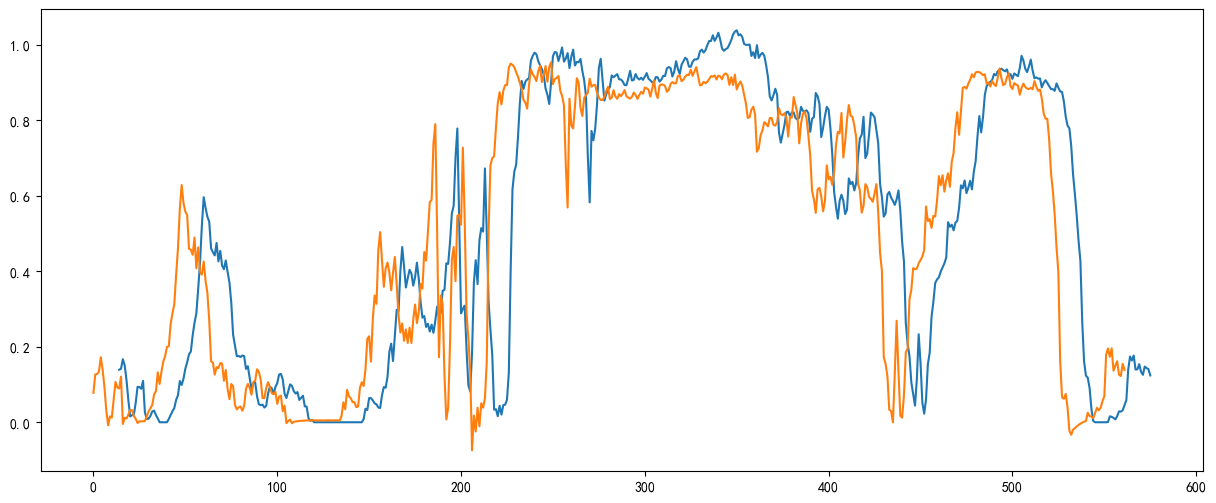

In [23]:
###GRU进行预测
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pylab as plt

train_X1 = x_spring_train.values.reshape((x_spring_train.shape[0], 58, 1))
test_X1 = x_spring_test.values.reshape((x_spring_test.shape[0], 58, 1))
val_X1 = x_spring_val.values.reshape((x_spring_val.shape[0], 58, 1))

# 定义GRU模型
def GRU_model(units, learning_rate, train_X):
    model = Sequential()
    model.add(GRU(units=int(units), input_shape=(train_X1.shape[1], train_X1.shape[2]), return_sequences=True))
    model.add(Dropout(0.3))
    model.add(GRU(units=int(units*2), return_sequences=False))
    model.add(Dense(1))  # 预测的是1步输出
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse')
    model.summary()
    return model

##成功的PSO参数调优
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
from mealpy.swarm_based.PSO import OriginalPSO

def cross_val(nest):
    units,epochs,learning_rate = nest
    model=GRU_model(units, learning_rate, val_X1)
    history = model.fit(val_X1, y_spring_val, epochs=int(epochs), batch_size=64, verbose=2, shuffle=False)
    # 执行预测
    y_pre = model.predict(val_X1)
    # 计算MSE误差值
    MSE= mean_squared_error(y_spring_val, y_pre)
    return MSE

#定义适应度函数
def fitness_function(nest):
    MSE = cross_val(nest)
    return MSE

#定义适应度函数的参数范围
def get_nest():
    problem_dict1 = {
         "fit_func": fitness_function,
         "lb": [30,30, 1e-05],
         "ub": [60,60, 1e-02],
         "minmax": "min",
    }
#设置迭代次数和粒子群数（越大运行速度越慢）
    epochs = 2  
    pop_size = 16  
    c1 = 2.05  
    c2 = 2.05  
    w_min = 0.4  
    w_max = 0.9  
    model = OriginalPSO(epochs, pop_size, c1, c2, w_min, w_max)  
    best_position, best_fitness = model.solve(problem_dict1)  
    print(f"Solution: {best_position}, Fitness: {best_fitness}")  
    return [best_fitness, best_position]  
#将获得的参数放入nest
nest=get_nest()
print(nest)
#取nest中的数赋给需要优化的参数
# units,epochs,learning_rate
units= nest[1][0]
epochs= nest[1][1]
learning_rate =nest[1][2]

model = GRU_model(units, learning_rate, train_X1)
history = model.fit(train_X1, y_spring_train, epochs=int(epochs), batch_size=64, verbose=2, shuffle=False)
y_pre_gru = model.predict(test_X1)
# 计算r方  
R2_gru = r2_score(y_spring_test, y_pre_gru)  
print("计算得出的r方为：", R2_gru)  

# 计算评估指标  
mse_gru = mean_squared_error(y_spring_test, y_pre_gru)  
mae_gru = mean_absolute_error(y_spring_test, y_pre_gru)  
mape_gru = mean_absolute_percentage_error(y_spring_test, y_pre_gru)  

# 计算RMSE
rmse_gru= np.sqrt(mse_gru)
print("MSE： ", mse_gru)
print("MAE:", mae_gru)
print("MAPE:", mape_gru)
print("RMSE:", rmse_gru)
#绘制PSO-GRU预测之后的模型
plt.figure(figsize=(15,6))
plt.plot(y_spring_test)
plt.plot(y_pre_gru)
plt.show()

In [24]:
import pandas as pd
# 计算y_spring_test的最大值和最小值
scaler_max = spring_y_test.values.max()  # 如果y_spring_test是多维的，使用max().max()获取全局最大值
scaler_min = spring_y_test.values.min()  # 如果y_spring_test是多维的，使用min().min()获取全局最小值
print("归一化的最大值:", scaler_max)
print("归一化的最小值:", scaler_min)

# 反归一化函数
def inverse_transform(y_pred_scaled, y_actual_scaled, scaler_min, scaler_max):
    y_pred = y_pred_scaled * (scaler_max - scaler_min) + scaler_min
    y_actual = y_actual_scaled * (scaler_max - scaler_min) + scaler_min
    return y_pred, y_actual

# 确保 y_pre_gru 和 y_spring_test.values.ravel() 是一维数组
# 反归一化预测值和实际值
y_pre_gru_inv, y_spring_test_inv = inverse_transform(y_pre_gru, y_spring_test.values, scaler_min, scaler_max)
# 计算预测误差
spring_gru_error = y_spring_test_inv - y_pre_gru_inv
# 保存误差到数据框
spring_gru_error_df = pd.DataFrame(spring_gru_error, columns=['error'])
# 打印数据框
print(spring_gru_error_df)

归一化的最大值: 63.736667
归一化的最小值: 0.0
        error
0    3.906367
1    0.968412
2    2.504658
3    1.052235
4   -3.889336
..        ...
557 -2.303009
558  1.393313
559  1.334887
560 -0.886216
561 -0.928292

[562 rows x 1 columns]


C:\Users\cwj20010310\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_230"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 58, 38)              │           4,674 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_230 (Dropout)                │ (None, 58, 38)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 116)                 │          54,288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_230 (Dense)                    │ (None, 1)                   │             117 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 59,079 (230.78 KB)

 Trainable params: 59,079 (230.78 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru_100 (GRU)                        │ (None, 58, 45)              │           6,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_280 (Dropout)                │ (None, 58, 45)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_101 (GRU)                        │ (None, 136)                 │          74,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_280 (Dense)                    │ (None, 1)                   │             137 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 81,281 (317.50 KB)

 Trainable params: 81,281 (317.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/48
172/172 - 9s - 50ms/step - loss: 0.0409
Epoch 2/48
172/172 - 6s - 35ms/step - loss: 0.0083
Epoch 3/48
172/172 - 6s - 34ms/step - loss: 0.0087
Epoch 4/48
172/172 - 5s - 31ms/step - loss: 0.0083
Epoch 5/48
172/172 - 5s - 32ms/step - loss: 0.0086
Epoch 6/48
172/172 - 5s - 31ms/step - loss: 0.0081
Epoch 7/48
172/172 - 6s - 35ms/step - loss: 0.0081
Epoch 8/48
172/172 - 5s - 31ms/step - loss: 0.0082
Epoch 9/48
172/172 - 5s - 32ms/step - loss: 0.0079
Epoch 10/48
172/172 - 5s - 31ms/step - loss: 0.0080
Epoch 11/48
172/172 - 5s - 31ms/step - loss: 0.0077
Epoch 12/48
172/172 - 5s - 31ms/step - loss: 0.0073
Epoch 13/48
172/172 - 5s - 31ms/step - loss: 0.0079
Epoch 14/48
172/172 - 5s - 31ms/step - loss: 0.0076
Epoch 15/48
172/172 - 5s - 31ms/step - loss: 0.0076
Epoch 16/48
172/172 - 5s - 32ms/step - loss: 0.0072
Epoch 17/48
172/172 - 5s - 31ms/step - loss: 0.0074
Epoch 18/48
172/172 - 5s - 32ms/step - loss: 0.0074
Epoch 19/48
172/172 - 5s - 31ms/step - loss: 0.0071
Epoch 20/48
172/172 -

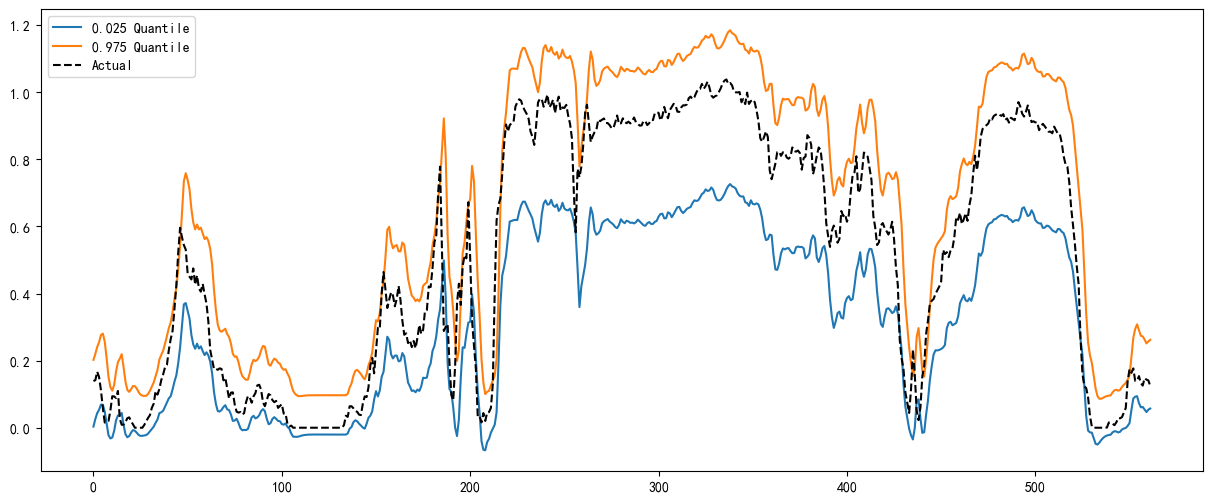

In [56]:
#GRU区间预测（95%）
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pylab as plt
from tensorflow.keras import backend as K

train_X1 = x_spring_train.values.reshape((x_spring_train.shape[0], 58, 1))
test_X1 = x_spring_test.values.reshape((x_spring_test.shape[0], 58, 1))
val_X1 = x_spring_val.values.reshape((x_spring_val.shape[0], 58, 1))

# 分位数损失函数
def quantile_loss(y_true, y_pred, quantile):
    return K.mean(K.maximum(quantile * (y_true - y_pred), (quantile - 1) * (y_true - y_pred)), axis=-1)

# GRU模型
def GRU_model(units, learning_rate, train_X, quantile):
    model = Sequential()
    model.add(GRU(units=int(units), input_shape=(train_X.shape[1], train_X.shape[2]), return_sequences=True))
    model.add(Dropout(0.5))
    model.add(GRU(units=int(units*3), return_sequences=False))
    model.add(Dense(1))  # 预测的是1步输出
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss=lambda y_true, y_pred: quantile_loss(y_true, y_pred, quantile))
    model.summary()
    return model

##成功的PSO参数调优
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
from mealpy.swarm_based.PSO import OriginalPSO

def cross_val(nest):
    units,epochs,learning_rate,quantile = nest
    model=GRU_model(units, learning_rate, val_X1,quantile)
    history = model.fit(val_X1, y_spring_val, epochs=int(epochs), batch_size=64, verbose=2, shuffle=False)
    # 执行预测
    y_pre = model.predict(val_X1)
    # 计算MSE误差值
    MSE= mean_squared_error(y_spring_val, y_pre)
    return MSE

# 适应度函数
def fitness_function(nest):
    units, epochs, learning_rate, quantile = nest
    MSE = cross_val([units, epochs, learning_rate, quantile])
    return MSE

#定义适应度函数的参数范围
def get_nest():
    problem_dict1 = {
         "fit_func": fitness_function,
         "lb": [30,30, 1e-06,0.025],
         "ub": [50,50, 1e-04,0.975],
         "minmax": "min",
    }
#设置迭代次数和粒子群数（越大运行速度越慢）
    epochs = 2  
    pop_size = 16  
    c1 = 2.05  
    c2 = 2.05  
    w_min = 0.4  
    w_max = 0.9  
    model = OriginalPSO(epochs, pop_size, c1, c2, w_min, w_max)  
    best_position, best_fitness = model.solve(problem_dict1)  
    print(f"Solution: {best_position}, Fitness: {best_fitness}")  
    return [best_fitness, best_position]  
#将获得的参数放入nest
nest=get_nest()
print(nest)
#取nest中的数赋给需要优化的参数
# units,epochs,learning_rate
units= nest[1][0]
epochs= nest[1][1]
learning_rate =nest[1][2]

# 构建并训练GRU模型，分别预测0.025和0.975分位数
quantiles = [0.025, 0.975]
predictions_qgru = {}

for quantile in quantiles:
    model = GRU_model(units, learning_rate, train_X1, quantile)
    history = model.fit(train_X1, y_spring_train.values.ravel(), epochs=int(epochs), batch_size=10, verbose=2, shuffle=False)
    y_pre_qgru = model.predict(test_X1)
    predictions_qgru[quantile] = y_pre_qgru

# 计算评估指标
R2, mse, mae, mape, rmse = [], [], [], [], []

for quantile, y_pre_qgru in predictions_qgru.items():
    R2_qgru = r2_score(y_spring_test.values.ravel(), y_pre_qgru)
    mse_qgru = mean_squared_error(y_spring_test.values.ravel(), y_pre_qgru)
    mae_qgru = mean_absolute_error(y_spring_test.values.ravel(), y_pre_qgru)
    mape_qgru = mean_absolute_percentage_error(y_spring_test.values.ravel(), y_pre_qgru)
    rmse_qgru = np.sqrt(mse_qgru)

    R2.append(R2_qgru)
    mse.append(mse_qgru)
    mae.append(mae_qgru)
    mape.append(mape_qgru)
    rmse.append(rmse_qgru)

    print(f"Quantile {quantile}:")
    print("计算得出的r方为：", R2_qgru)
    print("MSE： ", mse_qgru)
    print("MAE:", mae_qgru)
    print("MAPE:", mape_qgru)
    print("RMSE:", rmse_qgru)

# 绘制PSO-GRU预测之后的模型
plt.figure(figsize=(15,6))
for quantile, y_pre_qgru in predictions_qgru.items():
    plt.plot(y_pre_qgru, label=f'{quantile} Quantile')

plt.plot(y_spring_test.values.ravel(), 'k--', label='Actual')
plt.legend()
plt.show()

In [57]:
#计算区间预测指标
picp_95 = np.mean((y_spring_test.values >= predictions_qgru[0.025]) & (y_spring_test.values <= predictions_qgru[0.975]))
piaw_95 = np.mean(predictions_qgru[0.975] - predictions_qgru[0.025])
ace_95 = np.abs(0.95 - picp_95)
ais95 = np.mean((np.abs(y_spring_test.values - y_pre_qgru) / (predictions_qgru[0.975] - predictions_qgru[0.025])) ** 2)
gru_lb= predictions_qgru[0.025]  # 下限值
gru_ub = predictions_qgru[0.975]  # 上限值
print(picp_95,piaw_95,ace_95,ais95)

0.9323843416370107 0.32924253 0.017615658362989284 0.3123334431234838


train_X1.shape  (1713, 58, 1)
test_X1.shape  (562, 58, 1)


C:\Users\cwj20010310\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_198"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 58, 42)              │           1,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 42)                  │           3,570 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_198 (Dense)                    │ (None, 1)                   │              43 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,461 (21.33 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_98 (SimpleRNN)            │ (None, 58, 59)              │           3,599 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_99 (SimpleRNN)            │ (None, 59)                  │           7,021 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_247 (Dense)                    │ (None, 1)                   │              60 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,680 (41.72 KB)

 Trainable params: 10,680 (41.72 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/58
27/27 - 2s - 73ms/step - loss: 0.1518
Epoch 2/58
27/27 - 0s - 13ms/step - loss: 0.0329
Epoch 3/58
27/27 - 0s - 14ms/step - loss: 0.0206
Epoch 4/58
27/27 - 0s - 13ms/step - loss: 0.0155
Epoch 5/58
27/27 - 0s - 14ms/step - loss: 0.0135
Epoch 6/58
27/27 - 0s - 15ms/step - loss: 0.0117
Epoch 7/58
27/27 - 0s - 15ms/step - loss: 0.0103
Epoch 8/58
27/27 - 0s - 15ms/step - loss: 0.0094
Epoch 9/58
27/27 - 0s - 16ms/step - loss: 0.0088
Epoch 10/58
27/27 - 0s - 14ms/step - loss: 0.0083
Epoch 11/58
27/27 - 0s - 15ms/step - loss: 0.0080
Epoch 12/58
27/27 - 0s - 14ms/step - loss: 0.0078
Epoch 13/58
27/27 - 0s - 14ms/step - loss: 0.0076
Epoch 14/58
27/27 - 0s - 15ms/step - loss: 0.0074
Epoch 15/58
27/27 - 0s - 14ms/step - loss: 0.0072
Epoch 16/58
27/27 - 0s - 15ms/step - loss: 0.0071
Epoch 17/58
27/27 - 0s - 14ms/step - loss: 0.0069
Epoch 18/58
27/27 - 0s - 14ms/step - loss: 0.0068
Epoch 19/58
27/27 - 0s - 15ms/step - loss: 0.0066
Epoch 20/58
27/27 - 0s - 14ms/step - loss: 0.0065
Epoch 21/

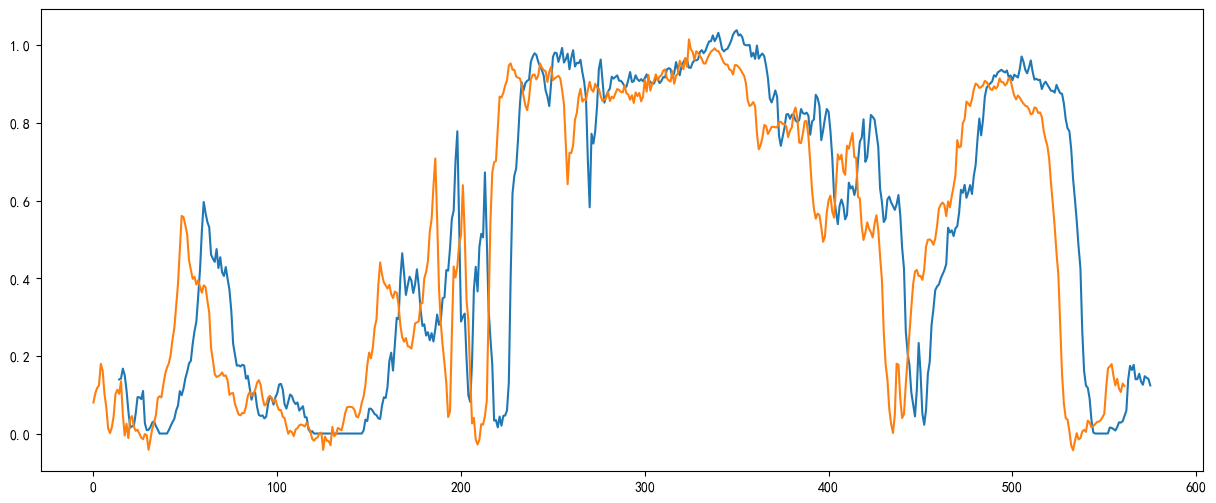

In [25]:
###RNN进行预测
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import SimpleRNN

train_X1 = x_spring_train.values.reshape((x_spring_train.shape[0],58,1))
test_X1= x_spring_test.values.reshape((x_spring_test.shape[0],58,1))
val_X1= x_spring_val.values.reshape((x_spring_val.shape[0],58,1))
print("train_X1.shape ",train_X1.shape)
print("test_X1.shape ",test_X1.shape)

# 定义 RNN 模型
def RNN_model(units, learning_rate):
    model = Sequential()
    units=int(units)
    model.add(SimpleRNN(units, input_shape=(58,1), return_sequences=True))
    # 隐藏层
    model.add(SimpleRNN(units))
    model.add(Dense(1))
    # 编译模型
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse')
    model.summary()
    return model

##成功的PSO参数调优
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
from mealpy.swarm_based.PSO import OriginalPSO

def cross_val(nest):
    units,epochs,learning_rate = nest
    model=RNN_model(units, learning_rate)
    history = model.fit(train_X1, y_spring_train, epochs=int(epochs), batch_size=64, verbose=2, shuffle=False)
    # 执行预测
    y_pre = model.predict(val_X1)
    # 计算MSE误差值
    MSE= mean_squared_error(y_spring_val, y_pre)
    return MSE
    
#定义适应度函数
def fitness_function(nest):
    MSE = cross_val(nest)
    return MSE

#定义适应度函数的参数范围
def get_nest():
    problem_dict1 = {
         "fit_func": fitness_function,
         "lb": [30,30, 1e-07],
         "ub": [60,60, 1e-04],
         "minmax": "min",
    }
#设置迭代次数和粒子群数（越大运行速度越慢）
    epochs = 2  
    pop_size = 16  
    c1 = 2.05  
    c2 = 2.05  
    w_min = 0.4  
    w_max = 0.9  
    model = OriginalPSO(epochs, pop_size, c1, c2, w_min, w_max)  
    best_position, best_fitness = model.solve(problem_dict1)  
    print(f"Solution: {best_position}, Fitness: {best_fitness}")  
    return [best_fitness, best_position]  
#将获得的参数放入nest
nest=get_nest()
print(nest)
#取nest中的数赋给需要优化的参数
# units,epochs,learning_rate
units= nest[1][0]
epochs= nest[1][1]
learning_rate =nest[1][2]
model = RNN_model(units, learning_rate)
history = model.fit(train_X1, y_spring_train, epochs=int(epochs), batch_size=64, verbose=2, shuffle=False)
y_pre_rnn = model.predict(test_X1)
# 计算r方  
R2_rnn = r2_score(y_spring_test, y_pre_rnn)  
print("计算得出的r方为：", R2_rnn)  

# 计算评估指标  
mse_rnn = mean_squared_error(y_spring_test, y_pre_rnn)  
mae_rnn = mean_absolute_error(y_spring_test, y_pre_rnn)  
mape_rnn = mean_absolute_percentage_error(y_spring_test, y_pre_rnn)  

# 计算RMSE
rmse_rnn= np.sqrt(mse_rnn)
print("MSE： ", mse_rnn)
print("MAE:", mae_rnn)
print("MAPE:", mape_rnn)
print("RMSE:", rmse_rnn)
#绘制PSO-rnn预测之后的模型
plt.figure(figsize=(15,6))
plt.plot(y_spring_test)
plt.plot(y_pre_rnn)
plt.show()

In [26]:
import pandas as pd

# 计算y_spring_test的最大值和最小值
scaler_max = spring_y_test.values.max()  # 如果y_spring_test是多维的，使用max().max()获取全局最大值
scaler_min = spring_y_test.values.min()  # 如果y_spring_test是多维的，使用min().min()获取全局最小值
print("归一化的最大值:", scaler_max)
print("归一化的最小值:", scaler_min)

# 反归一化函数
def inverse_transform(y_pred_scaled, y_actual_scaled, scaler_min, scaler_max):
    y_pred = y_pred_scaled * (scaler_max - scaler_min) + scaler_min
    y_actual = y_actual_scaled * (scaler_max - scaler_min) + scaler_min
    return y_pred, y_actual

# 确保 y_pre_rnn 和 y_spring_test.values.ravel() 是一维数组
# 反归一化预测值和实际值
y_pre_rnn_inv, y_spring_test_inv = inverse_transform(y_pre_rnn, y_spring_test.values, scaler_min, scaler_max)
# 计算预测误差
spring_rnn_error = y_spring_test_inv - y_pre_rnn_inv
# 保存误差到数据框
spring_rnn_error_df = pd.DataFrame(spring_rnn_error, columns=['error'])
# 打印数据框
print(spring_rnn_error_df)

归一化的最大值: 63.736667
归一化的最小值: 0.0
        error
0    3.781462
1    2.439693
2    3.195432
3    1.703260
4   -4.354222
..        ...
557 -0.975761
558  2.050292
559  2.327286
560  0.783035
561  0.112493

[562 rows x 1 columns]


train_X1.shape  (1713, 58, 1)
test_X1.shape  (562, 58, 1)


C:\Users\cwj20010310\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_153"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_102 (SimpleRNN)           │ (None, 58, 52)              │           2,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_103 (SimpleRNN)           │ (None, 52)                  │           5,460 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_153 (Dense)                    │ (None, 1)                   │              53 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,321 (32.50 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_202 (SimpleRNN)           │ (None, 58, 29)              │             899 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_203 (SimpleRNN)           │ (None, 29)                  │           1,711 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_203 (Dense)                    │ (None, 1)                   │              30 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,640 (10.31 KB)

 Trainable params: 2,640 (10.31 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
27/27 - 2s - 69ms/step - loss: 0.0563
Epoch 2/50
27/27 - 0s - 11ms/step - loss: 0.0139
Epoch 3/50
27/27 - 0s - 11ms/step - loss: 0.0122
Epoch 4/50
27/27 - 0s - 11ms/step - loss: 0.0091
Epoch 5/50
27/27 - 0s - 11ms/step - loss: 0.0077
Epoch 6/50
27/27 - 0s - 12ms/step - loss: 0.0072
Epoch 7/50
27/27 - 0s - 11ms/step - loss: 0.0071
Epoch 8/50
27/27 - 0s - 11ms/step - loss: 0.0069
Epoch 9/50
27/27 - 0s - 12ms/step - loss: 0.0063
Epoch 10/50
27/27 - 0s - 12ms/step - loss: 0.0061
Epoch 11/50
27/27 - 0s - 12ms/step - loss: 0.0060
Epoch 12/50
27/27 - 0s - 12ms/step - loss: 0.0055
Epoch 13/50
27/27 - 0s - 12ms/step - loss: 0.0054
Epoch 14/50
27/27 - 0s - 12ms/step - loss: 0.0053
Epoch 15/50
27/27 - 0s - 12ms/step - loss: 0.0050
Epoch 16/50
27/27 - 0s - 11ms/step - loss: 0.0050
Epoch 17/50
27/27 - 0s - 12ms/step - loss: 0.0051
Epoch 18/50
27/27 - 0s - 10ms/step - loss: 0.0049
Epoch 19/50
27/27 - 0s - 10ms/step - loss: 0.0049
Epoch 20/50
27/27 - 0s - 10ms/step - loss: 0.0061
Epoch 21/

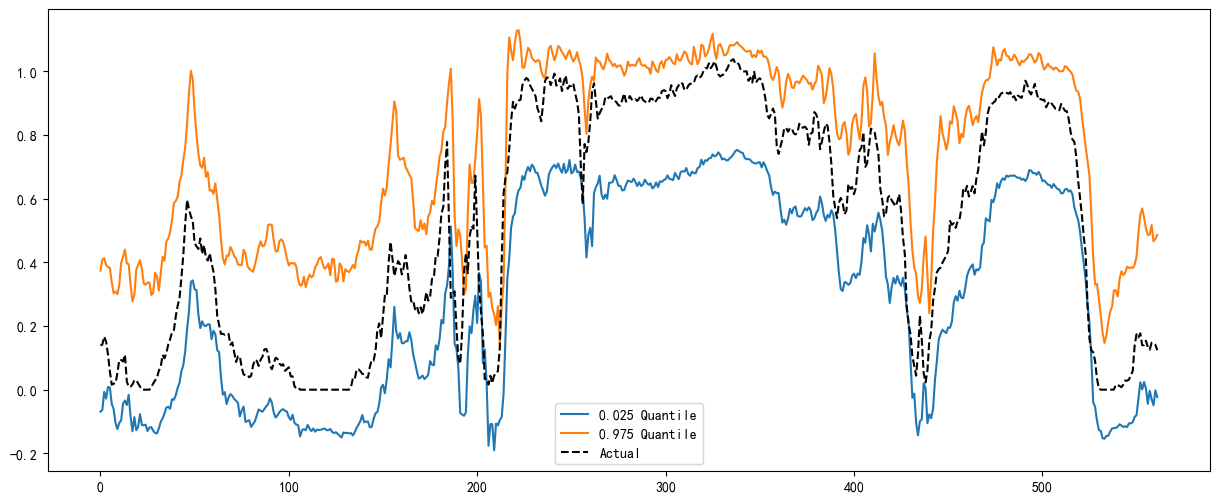

In [25]:
###RNN进行区间预测
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras import backend as K

train_X1 = x_spring_train.values.reshape((x_spring_train.shape[0], 58, 1))
test_X1 = x_spring_test.values.reshape((x_spring_test.shape[0], 58, 1))
val_X1 = x_spring_val.values.reshape((x_spring_val.shape[0], 58, 1))

print("train_X1.shape ",train_X1.shape)
print("test_X1.shape ",test_X1.shape)
# 分位数损失函数
def quantile_loss(y_true, y_pred, quantile):
    return K.mean(K.maximum(quantile * (y_true - y_pred), (quantile - 1) * (y_true - y_pred)), axis=-1)

# RNN模型
def RNN_model(units, learning_rate, quantile):
    model = Sequential()
    units = int(units)
    model.add(SimpleRNN(units, input_shape=(58, 1), return_sequences=True))
    # 隐藏层
    model.add(SimpleRNN(units))
    # 输出层
    model.add(Dense(1))
    # 编译模型
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss=lambda y_true, y_pred: quantile_loss(y_true, y_pred, quantile))
    model.summary()
    return model
    
##成功的PSO参数调优
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
from mealpy.swarm_based.PSO import OriginalPSO

def cross_val(nest):
    units,epochs,learning_rate,quantile = nest
    model=RNN_model(units, learning_rate,quantile)
    history = model.fit(train_X1, y_spring_train, epochs=int(epochs), batch_size=64, verbose=2, shuffle=False)
    # 执行预测
    y_pre = model.predict(val_X1)
    # 计算MSE误差值
    MSE= mean_squared_error(y_spring_val, y_pre)
    return MSE

# 适应度函数
def fitness_function(nest):
    units, epochs, learning_rate, quantile = nest
    MSE = cross_val([units, epochs, learning_rate, quantile])
    return MSE

#定义适应度函数的参数范围
def get_nest():
    problem_dict1 = {
         "fit_func": fitness_function,
         "lb": [20,20, 1e-06,0.025],
         "ub": [60,60, 1e-03,0.975],
         "minmax": "min",
    }
#设置迭代次数和粒子群数（越大运行速度越慢）
    epochs = 2  
    pop_size = 16  
    c1 = 2.05  
    c2 = 2.05  
    w_min = 0.4  
    w_max = 0.9  
    model = OriginalPSO(epochs, pop_size, c1, c2, w_min, w_max)  
    best_position, best_fitness = model.solve(problem_dict1)  
    print(f"Solution: {best_position}, Fitness: {best_fitness}")  
    return [best_fitness, best_position]  
#将获得的参数放入nest
nest=get_nest()
print(nest)
#取nest中的数赋给需要优化的参数
# units,epochs,learning_rate
units= nest[1][0]
epochs= nest[1][1]
learning_rate =nest[1][2]

# 构建并训练RNN模型，分别预测0.025和0.975分位数
quantiles = [0.025, 0.975]
predictions_qrnn = {}

for quantile in quantiles:
    model = RNN_model(units, learning_rate, quantile)
    history = model.fit(train_X1, y_spring_train.values.ravel(), epochs=int(epochs), batch_size=64, verbose=2, shuffle=False)
    y_pre_qrnn = model.predict(test_X1)
    predictions_qrnn[quantile] = y_pre_qrnn

# 计算评估指标
R2, mse, mae, mape, rmse = [], [], [], [], []

for quantile, y_pre_qrnn in predictions_qrnn.items():
    R2_qrnn = r2_score(y_spring_test.values.ravel(), y_pre_qrnn)
    mse_qrnn = mean_squared_error(y_spring_test.values.ravel(), y_pre_qrnn)
    mae_qrnn = mean_absolute_error(y_spring_test.values.ravel(), y_pre_qrnn)
    mape_qrnn = mean_absolute_percentage_error(y_spring_test.values.ravel(), y_pre_qrnn)
    rmse_qrnn = np.sqrt(mse_qrnn)

    R2.append(R2_qrnn)
    mse.append(mse_qrnn)
    mae.append(mae_qrnn)
    mape.append(mape_qrnn)
    rmse.append(rmse_qrnn)

    print(f"Quantile {quantile}:")
    print("计算得出的r方为：", R2_qrnn)
    print("MSE： ", mse_qrnn)
    print("MAE:", mae_qrnn)
    print("MAPE:", mape_qrnn)
    print("RMSE:", rmse_qrnn)

# 绘制PSO-RNN预测之后的模型
plt.figure(figsize=(15,6))
for quantile, y_pre_qrnn in predictions_qrnn.items():
    plt.plot(y_pre_qrnn, label=f'{quantile} Quantile')

plt.plot(y_spring_test.values.ravel(), 'k--', label='Actual')
plt.legend()
plt.show()

In [26]:
#计算区间指标
picp_95 = np.mean((y_spring_test.values >= predictions_qrnn[0.025]) & (y_spring_test.values <= predictions_qrnn[0.975]))
piaw_95 = np.mean(predictions_qrnn[0.975] - predictions_qrnn[0.025])
ace_95 = np.abs(0.95 - picp_95)
ais95 = np.mean((np.abs(y_spring_test.values - y_pre_qrnn) / (predictions_qrnn[0.975] - predictions_qrnn[0.025])) ** 2)
rnn_lb= predictions_qrnn[0.025]  # 下限值
rnn_ub = predictions_qrnn[0.975]  # 上限值
print(picp_95,piaw_95,ace_95,ais95)

0.9750889679715302 0.44489634 0.025088967971530263 0.29699055019538184


In [27]:
import pandas as pd
import numpy as np
import os

# 创建一个DataFrame来保存数据
excel_data = {
    "RNN_Lower_Bound": rnn_lb.flatten(),
    "RNN_Upper_Bound": rnn_ub.flatten(),
    "LSTM_Lower_Bound": lstm_lb.flatten(),
    "LSTM_Upper_Bound": lstm_ub.flatten()
}

# 将数据转换为DataFrame
excel_df = pd.DataFrame(excel_data)

# 获取spring_y_test的最大值和最小值
scaler_max = spring_y_test.values.max()  # 如果spring_y_test是多维的，使用max().max()获取全局最大值
scaler_min = spring_y_test.values.min()  # 如果spring_y_test是多维的，使用min().min()获取全局最小值
print("归一化的最大值:", scaler_max)
print("归一化的最小值:", scaler_min)

# 反归一化函数
def inverse_normalize(value, scaler_min, scaler_max):
    return value * (scaler_max - scaler_min) + scaler_min

# 应用反归一化
models = ["RNN", "LSTM"]
for model in models:
    model_lower_key = model + "_Lower_Bound"
    model_upper_key = model + "_Upper_Bound"
    excel_df[model_lower_key] = excel_df[model_lower_key].apply(lambda x: inverse_normalize(x, scaler_min, scaler_max))
    excel_df[model_upper_key] = excel_df[model_upper_key].apply(lambda x: inverse_normalize(x, scaler_min, scaler_max))

# 将合并后的 DataFrame 保存到 Excel 文件中
directory = 'D:\\article'
file_path = os.path.join(directory, 'RNN_LSTM_quantiles3.xlsx')
excel_df.to_excel(file_path, index=False)

# 显示DataFrame
excel_df

归一化的最大值: 63.736667
归一化的最小值: 0.0


,RNN_Lower_Bound,RNN_Upper_Bound,LSTM_Lower_Bound,LSTM_Upper_Bound
0,-4.400511,23.842852,0.761040,9.802011
1,-4.064147,26.027521,1.834143,11.602959
2,-0.440729,26.319647,2.461948,11.613268
3,-1.793334,24.967316,2.662861,12.176333
4,0.540623,24.571905,3.605981,14.804427
...,...,...,...,...
557,-0.217762,31.056954,2.791265,13.987885
558,-1.879508,32.967331,2.298339,11.829382
559,-3.135781,29.715588,1.869980,11.568895
560,-0.133088,30.206770,2.525640,13.444106


In [43]:
#将各个点预测结果和误差保存在文件夹中
import pandas as pd
# 将它们转换为 DataFrame
y_pre_lstm_df = pd.DataFrame(y_pre_lstm_inv, columns=['y_pre_lstm'])
spring_lstm_error_df = pd.DataFrame(spring_lstm_error, columns=['spring_lstm_error'])
y_pre_tcn_df = pd.DataFrame(y_pre_tcn_inv, columns=['y_pre_tcn'])
spring_tcn_error_df = pd.DataFrame(spring_tcn_error, columns=['spring_tcn_error'])
y_pre_gru_df = pd.DataFrame(y_pre_gru_inv, columns=['y_pre_gru'])
spring_gru_error_df = pd.DataFrame(spring_gru_error, columns=['spring_gru_error'])
y_pre_rnn_df = pd.DataFrame(y_pre_rnn_inv, columns=['y_pre_rnn'])
spring_rnn_error_df = pd.DataFrame(spring_rnn_error, columns=['spring_rnn_error'])
y_spring_test_df = pd.DataFrame(y_spring_test_inv, columns=['y_spring_test'])

# 使用 concat 函数将 DataFrame 合并为一个 DataFrame
combined_df = pd.concat([
    y_pre_lstm_df, 
    spring_lstm_error_df, 
    y_pre_tcn_df, 
    spring_tcn_error_df,
    y_pre_gru_df, 
    spring_gru_error_df,
    y_pre_rnn_df, 
    spring_rnn_error_df,
    y_spring_test_df
], axis=1)

# 将合并后的 DataFrame 保存到 Excel 文件中
directory = 'D:\\article'
file_path = os.path.join(directory, 'point_prediction_error3.xlsx')
combined_df.to_excel(file_path, index=False)
combined_df

,y_pre_lstm,spring_lstm_error,y_pre_tcn,spring_tcn_error,y_pre_gru,spring_gru_error,y_pre_rnn,spring_rnn_error,y_spring_test
0,1.694503,7.177463,2.840084,6.031882,4.965600,3.906367,5.090504,3.781462,8.871966
1,3.093170,5.936619,3.453556,5.576232,8.061377,0.968412,6.590096,2.439693,9.029788
2,3.034350,7.618654,4.951879,5.701126,8.148346,2.504658,7.457572,3.195432,10.653004
3,3.528089,6.086611,4.583643,5.031056,8.562465,1.052235,7.911440,1.703260,9.614700
4,5.312839,1.776704,5.451848,1.637695,10.978879,-3.889336,11.443765,-4.354222,7.089543
...,...,...,...,...,...,...,...,...,...
557,4.908802,3.094449,5.315200,2.688051,10.306260,-2.303009,8.979012,-0.975761,8.003251
558,3.477093,5.931330,5.326000,4.082423,8.015110,1.393313,7.358131,2.050292,9.408423
559,3.471801,5.668739,6.648797,2.491744,7.805653,1.334887,6.813254,2.327286,9.140540
560,4.514418,4.472453,7.228416,1.758455,9.873087,-0.886216,8.203836,0.783035,8.986871


In [42]:
import pandas as pd
import numpy as np
import os

# 创建一个DataFrame来保存数据
excel_data = {
    "RNN_Lower_Bound": rnn_lb.flatten(),
    "RNN_Upper_Bound": rnn_ub.flatten(),
    "LSTM_Lower_Bound": lstm_lb.flatten(),
    "LSTM_Upper_Bound": lstm_ub.flatten(),
    "TCN_Lower_Bound": tcn_lb.flatten(),
    "TCN_Upper_Bound": tcn_ub.flatten(),
    "GRU_Lower_Bound": gru_lb.flatten(),
    "GRU_Upper_Bound": gru_ub.flatten()
}

# 将数据转换为DataFrame
excel_df = pd.DataFrame(excel_data)

# 获取spring_y_test的最大值和最小值
scaler_max = spring_y_test.values.max()  # 如果spring_y_test是多维的，使用max().max()获取全局最大值
scaler_min = spring_y_test.values.min()  # 如果spring_y_test是多维的，使用min().min()获取全局最小值
print("归一化的最大值:", scaler_max)
print("归一化的最小值:", scaler_min)

# 反归一化函数
def inverse_normalize(value, scaler_min, scaler_max):
    return value * (scaler_max - scaler_min) + scaler_min

# 应用反归一化
models = ["RNN", "LSTM", "TCN", "GRU"]
for model in models:
    model_lower_key = model + "_Lower_Bound"
    model_upper_key = model + "_Upper_Bound"
    excel_df[model_lower_key] = excel_df[model_lower_key].apply(lambda x: inverse_normalize(x, scaler_min, scaler_max))
    excel_df[model_upper_key] = excel_df[model_upper_key].apply(lambda x: inverse_normalize(x, scaler_min, scaler_max))

# 将合并后的 DataFrame 保存到 Excel 文件中
directory = 'D:\\article'
file_path = os.path.join(directory, 'predictions_quantiles3.xlsx')
excel_df.to_excel(file_path, index=False)

# 显示DataFrame
excel_df

In [26]:
###误差修正
#导入文件
point_prediction_error = pd.read_excel(r'D:\article\point_prediction_error3.xlsx', sheet_name=None)
point_prediction_error_df = pd.concat(point_prediction_error.values(), ignore_index=True)
point_prediction_error_df

,y_pre_itransformer,spring_itransformer_error,y_pre_lstm,spring_lstm_error,y_pre_tcn,spring_tcn_error,y_pre_gru,spring_gru_error,y_pre_rnn,spring_rnn_error,y_spring_test
0,2.429182,6.442784,1.694503,7.177463,2.840084,6.031882,4.965600,3.906367,5.090504,3.781462,8.871966
1,2.056130,6.973659,3.093170,5.936619,3.453556,5.576232,8.061377,0.968412,6.590096,2.439693,9.029788
2,3.533957,7.119047,3.034350,7.618654,4.951879,5.701126,8.148346,2.504658,7.457572,3.195432,10.653004
3,4.504742,5.109957,3.528089,6.086611,4.583643,5.031056,8.562465,1.052235,7.911440,1.703260,9.614700
4,6.095626,0.993917,5.312839,1.776704,5.451848,1.637695,10.978879,-3.889336,11.443765,-4.354222,7.089543
...,...,...,...,...,...,...,...,...,...,...,...
557,7.562004,0.441247,4.908802,3.094449,5.315200,2.688051,10.306260,-2.303009,8.979012,-0.975761,8.003251
558,6.440688,2.967735,3.477093,5.931330,5.326000,4.082423,8.015110,1.393313,7.358131,2.050292,9.408423
559,5.451316,3.689224,3.471801,5.668739,6.648797,2.491744,7.805653,1.334887,6.813254,2.327286,9.140540
560,6.105989,2.880882,4.514418,4.472453,7.228416,1.758455,9.873087,-0.886216,8.203836,0.783035,8.986871


In [27]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 取出各列
y_pre_itransformer = point_prediction_error_df.iloc[:, 0].to_frame(name='y_pre_itransformer')
spring_itransformer_error = point_prediction_error_df.iloc[:, 1].to_frame(name='spring_itransformer_error')
y_spring_test = point_prediction_error_df.iloc[:, -1].to_frame(name='y_spring_test')

scaler = MinMaxScaler()
scaler.fit(train_itransformer_error.reshape(-1, 1))  # 只用训练集fit，测试集不fit

y_pre_itransformer_normalized = pd.DataFrame(
    scaler.transform(y_pre_itransformer), 
    columns=y_pre_itransformer.columns, 
    index=y_pre_itransformer.index
)
spring_itransformer_error_normalized = pd.DataFrame(
    scaler.transform(spring_itransformer_error), 
    columns=spring_itransformer_error.columns, 
    index=spring_itransformer_error.index
)
y_spring_test_normalized = pd.DataFrame(
    scaler.transform(y_spring_test), 
    columns=y_spring_test.columns, 
    index=y_spring_test.index
)

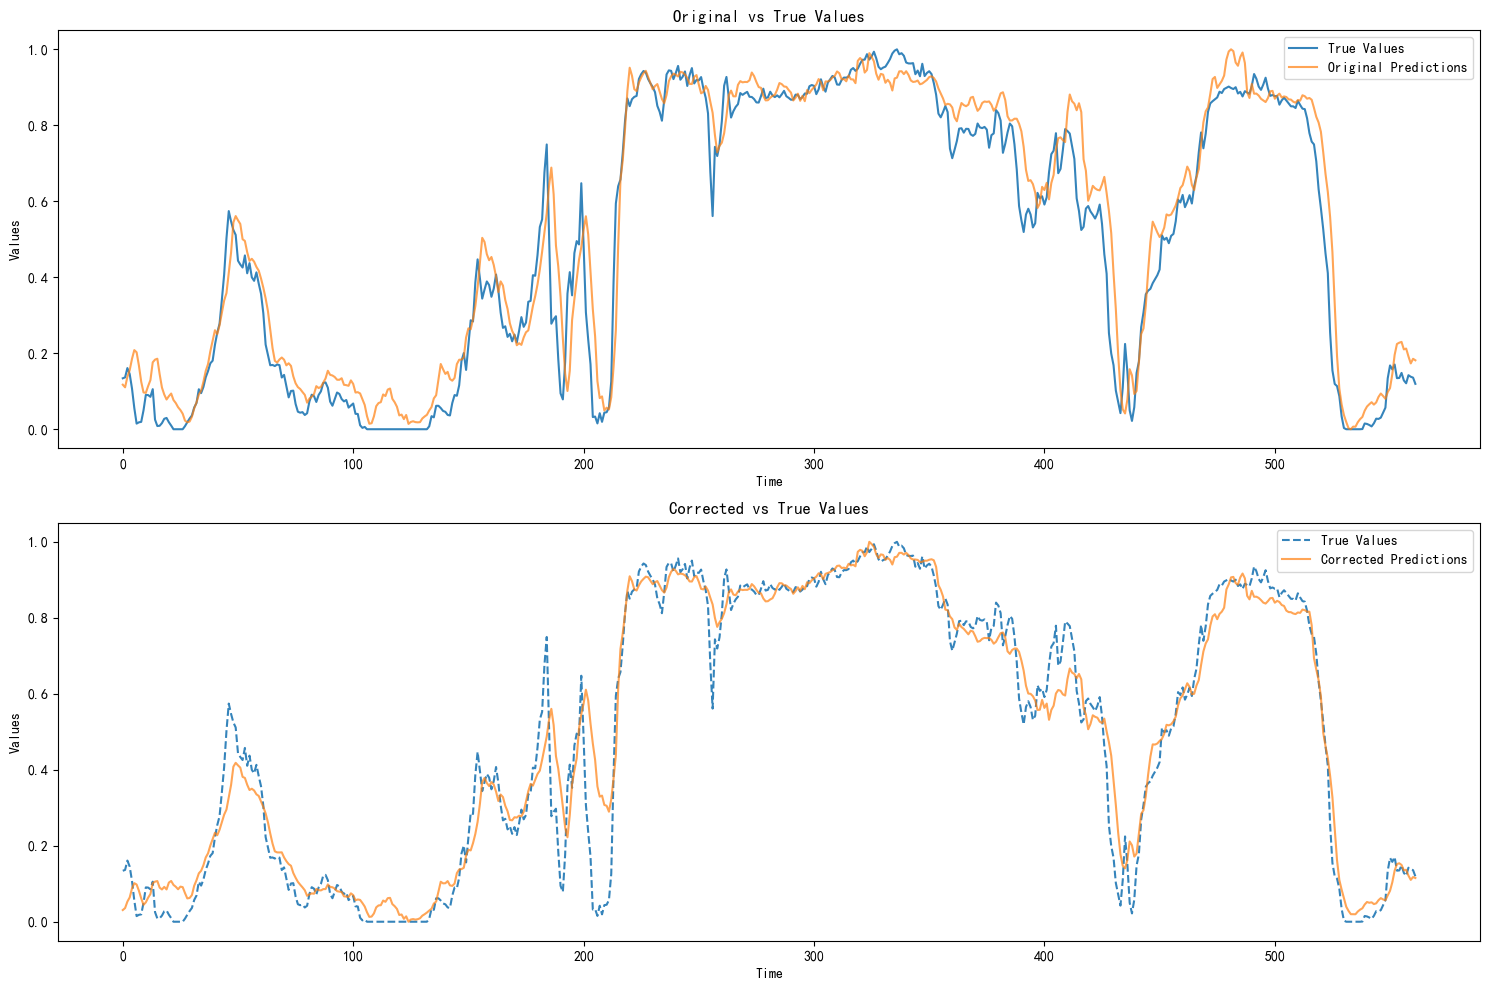

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from scipy.linalg import svd, inv

np.random.seed(0)

# ==================== DMD工具函数 ====================

def build_hankel(series, m):
    """构造Hankel矩阵，m为嵌入维度"""
    N = len(series)
    H = np.zeros((m, N - m + 1))
    for i in range(m):
        H[i, :] = series[i:i + N - m + 1]
    return H

def dmd_fit(X_train, rank):
    X1 = X_train[:, :-1]  # 前N-1列
    X2 = X_train[:, 1:]   # 后N-1列
    
    U, S, Vh = svd(X1, full_matrices=False)
    U_r = U[:, :rank]
    S_r = np.diag(S[:rank])
    Vh_r = Vh[:rank, :]
    
    # 拟合降阶DMD算子
    A_tilde = U_r.T @ X2 @ Vh_r.T @ inv(S_r)
    eigenvalues, eigenvectors = np.linalg.eig(A_tilde)
    
    # 计算全阶DMD模态
    phi = X2 @ Vh_r.T @ inv(S_r) @ eigenvectors
    
    # 计算初始模态振幅
    b = np.linalg.pinv(phi) @ X1[:, 0]
    
    return phi, eigenvalues, b

def dmd_step_predict(phi, eigenvalues, current_state):
    """用训练好的DMD算子做一步前向预测"""
    # 将当前状态投影到模态空间，一步推进
    proj = np.linalg.pinv(phi) @ current_state
    next_proj = eigenvalues * proj
    return phi @ next_proj

scaler = MinMaxScaler()
scaler.fit(train_itransformer_error.reshape(-1, 1))  # 只用训练集fit

train_error_norm = scaler.transform(train_itransformer_error.reshape(-1, 1)).flatten()
test_error_norm = scaler.transform(spring_itransformer_error.values.reshape(-1, 1)).flatten()
y_pre_norm = scaler.transform(y_pre_itransformer.values.reshape(-1, 1)).flatten()
y_test_norm = scaler.transform(y_spring_test.values.reshape(-1, 1)).flatten()


m = 12   # 嵌入维度
r = 5    # 截断秩

X_train_hankel = build_hankel(train_error_norm, m)
phi, eigenvalues, b = dmd_fit(X_train_hankel, rank=r)

n_test = len(test_error_norm)
corrected_test_error = np.zeros(n_test)

corrected_test_error[:m] = test_error_norm[:m]

for t in range(m, n_test):
    # 只用t时刻之前的m个点构造状态
    current_state = test_error_norm[t - m:t]
    # DMD一步前向预测残差变化
    dmd_pred = dmd_step_predict(phi, eigenvalues, current_state)
    # 修正当前时刻误差
    correction_strength = 0.2
    corrected_test_error[t] = test_error_norm[t] + correction_strength * dmd_pred[-1]

corrected_predictions_norm = y_pre_norm + corrected_test_error

# 反归一化
corrected_predictions = scaler.inverse_transform(corrected_predictions_norm.reshape(-1, 1)).flatten()

plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
plt.title("Original vs True Values")
plt.plot(y_test_norm, label='True Values', alpha=0.9)
plt.plot(y_pre_norm, label='Original Predictions', alpha=0.7)
plt.legend()
plt.xlabel("Time")
plt.ylabel("Values")

plt.subplot(2, 1, 2)
plt.title("Corrected vs True Values")
plt.plot(y_test_norm, label='True Values', linestyle='--', alpha=0.9)
plt.plot(corrected_predictions_norm, label='Corrected Predictions', alpha=0.7)
plt.legend()
plt.xlabel("Time")
plt.ylabel("Values")

plt.tight_layout()
plt.show()

In [38]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 计算原始预测的误差指标
original_R2 = r2_score(y_spring_test.values, y_pre_itransformer.values)
original_mse = mean_squared_error(y_spring_test.values, y_pre_itransformer.values)
original_rmse = np.sqrt(original_mse)
original_mae = mean_absolute_error(y_spring_test.values, y_pre_itransformer.values)

# 计算修正后预测的误差指标（用反归一化后的原始量纲）
corrected_R2 = r2_score(y_spring_test.values, corrected_predictions)
corrected_mse = mean_squared_error(y_spring_test.values, corrected_predictions)
corrected_rmse = np.sqrt(corrected_mse)
corrected_mae = mean_absolute_error(y_spring_test.values, corrected_predictions)

print(f"Original - R2: {original_R2:.4f}, MSE: {original_mse:.4f}, RMSE: {original_rmse:.4f}, MAE: {original_mae:.4f}")
print(f"Corrected - R2: {corrected_R2:.4f}, MSE: {corrected_mse:.4f}, RMSE: {corrected_rmse:.4f}, MAE: {corrected_mae:.4f}")

# 计算变化率
R2_change = ((corrected_R2 - original_R2) / abs(original_R2)) * 100
mse_reduction = ((original_mse - corrected_mse) / original_mse) * 100
rmse_reduction = ((original_rmse - corrected_rmse) / original_rmse) * 100
mae_reduction = ((original_mae - corrected_mae) / original_mae) * 100

print(f"\nR2 Improvement: {R2_change:.2f}%")
print(f"MSE Reduction: {mse_reduction:.2f}%")
print(f"RMSE Reduction: {rmse_reduction:.2f}%")
print(f"MAE Reduction: {mae_reduction:.2f}%")

Original Predictions - R2: 0.9383721488967973,MSE: 0.00791036448292488, RMSE: 0.08894022983400077, MAE: 0.06201704585103703
Corrected Predictions - R2: 0.9500975695071184, MSE: 0.006405324974279421, RMSE: 0.08003327416943168, MAE: 0.05116168461113509
R2 Reduction: -1.2495490860535634%
MSE Reduction: 19.0261714475256%
RMSE Reduction: 10.01454086771886%
MAE Reduction: 17.503834777903112%


In [39]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 取出各列
y_pre_lstm = point_prediction_error_df.iloc[:, 2].to_frame(name='y_pre_lstm')
spring_lstm_error = point_prediction_error_df.iloc[:, 3].to_frame(name='spring_lstm_error')
y_spring_test = point_prediction_error_df.iloc[:, -1].to_frame(name='y_spring_test')
scaler = MinMaxScaler()
scaler.fit(train_lstm_error.reshape(-1, 1))

# 所有变量都用同一个scaler transform
y_pre_lstm_normalized = pd.DataFrame(scaler.transform(y_pre_lstm), columns=y_pre_lstm.columns, index=y_pre_lstm.index)
spring_lstm_error_normalized = pd.DataFrame(scaler.transform(spring_lstm_error), columns=spring_lstm_error.columns, index=spring_lstm_error.index)
y_spring_test_normalized = pd.DataFrame(scaler.transform(y_spring_test), columns=y_spring_test.columns, index=y_spring_test.index)

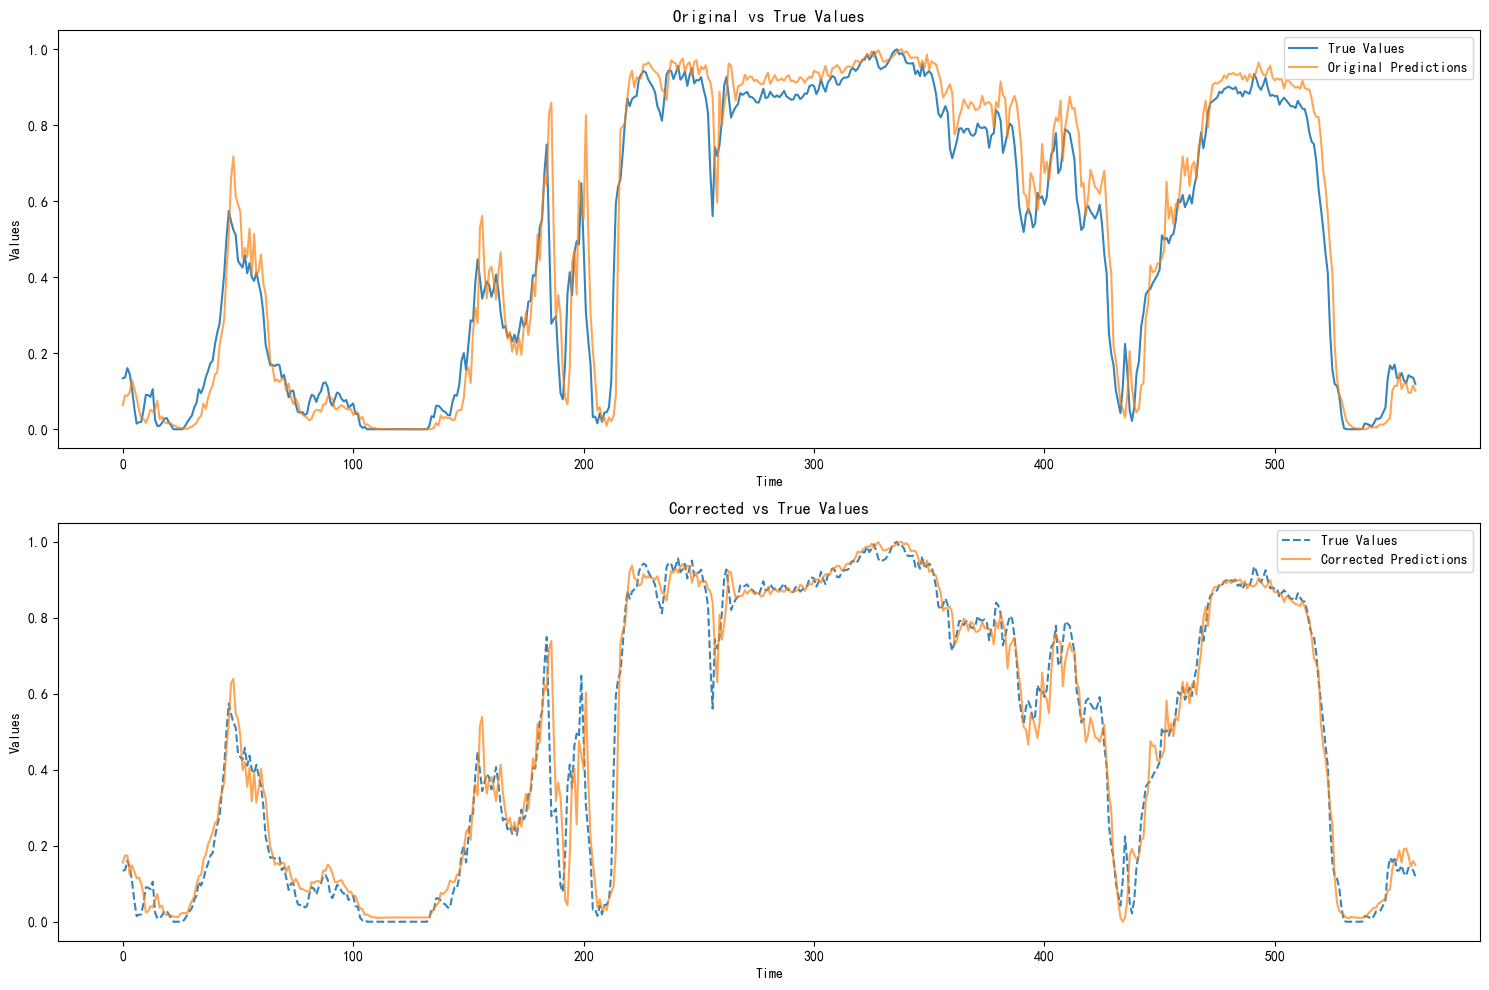

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from scipy.linalg import svd, inv

np.random.seed(0)

# ==================== DMD工具函数 ====================

def build_hankel(series, m):
    N = len(series)
    H = np.zeros((m, N - m + 1))
    for i in range(m):
        H[i, :] = series[i:i + N - m + 1]
    return H

def dmd_fit(X_train, rank):
    X1 = X_train[:, :-1]
    X2 = X_train[:, 1:]
    U, S, Vh = svd(X1, full_matrices=False)
    U_r = U[:, :rank]
    S_r = np.diag(S[:rank])
    Vh_r = Vh[:rank, :]
    A_tilde = U_r.T @ X2 @ Vh_r.T @ inv(S_r)
    eigenvalues, eigenvectors = np.linalg.eig(A_tilde)
    phi = X2 @ Vh_r.T @ inv(S_r) @ eigenvectors
    b = np.linalg.pinv(phi) @ X1[:, 0]
    return phi, eigenvalues, b

def dmd_step_predict(phi, eigenvalues, current_state):
    proj = np.linalg.pinv(phi) @ current_state
    next_proj = eigenvalues * proj
    return phi @ next_proj

scaler = MinMaxScaler()
scaler.fit(train_lstm_error.reshape(-1, 1))

train_error_norm = scaler.transform(train_lstm_error.reshape(-1, 1)).flatten()
test_error_norm = scaler.transform(spring_lstm_error.values.reshape(-1, 1)).flatten()
y_pre_norm = scaler.transform(y_pre_lstm.values.reshape(-1, 1)).flatten()
y_test_norm = scaler.transform(y_spring_test.values.reshape(-1, 1)).flatten()

# 拟合DMD算子
m = 12   # 嵌入维度
r = 5    # 截断秩（与论文一致）

X_train_hankel = build_hankel(train_error_norm, m)
phi, eigenvalues, b = dmd_fit(X_train_hankel, rank=r)

# 逐点因果修正
n_test = len(test_error_norm)
corrected_test_error = np.zeros(n_test)
corrected_test_error[:m] = test_error_norm[:m]

correction_strength = 0.2

for t in range(m, n_test):
    current_state = test_error_norm[t - m:t]
    dmd_pred = dmd_step_predict(phi, eigenvalues, current_state)
    corrected_test_error[t] = test_error_norm[t] + correction_strength * dmd_pred[-1]

corrected_predictions_norm = y_pre_norm + corrected_test_error
corrected_predictions = scaler.inverse_transform(corrected_predictions_norm.reshape(-1, 1)).flatten()

plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
plt.title("Original vs True Values")
plt.plot(y_test_norm, label='True Values', alpha=0.9)
plt.plot(y_pre_norm, label='Original Predictions', alpha=0.7)
plt.legend()
plt.xlabel("Time")
plt.ylabel("Values")

plt.subplot(2, 1, 2)
plt.title("Corrected vs True Values")
plt.plot(y_test_norm, label='True Values', linestyle='--', alpha=0.9)
plt.plot(corrected_predictions_norm, label='Corrected Predictions', alpha=0.7)
plt.legend()
plt.xlabel("Time")
plt.ylabel("Values")

plt.tight_layout()
plt.show()

In [41]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 建议用原始量纲计算
original_R2 = r2_score(y_spring_test.values, y_pre_lstm.values)
original_mse = mean_squared_error(y_spring_test.values, y_pre_lstm.values)
original_rmse = np.sqrt(original_mse)
original_mae = mean_absolute_error(y_spring_test.values, y_pre_lstm.values)

# 修正后（corrected_predictions 是反归一化后的结果）
corrected_R2 = r2_score(y_spring_test.values, corrected_predictions)
corrected_mse = mean_squared_error(y_spring_test.values, corrected_predictions)
corrected_rmse = np.sqrt(corrected_mse)
corrected_mae = mean_absolute_error(y_spring_test.values, corrected_predictions)

print(f"Original - R2: {original_R2:.4f}, MSE: {original_mse:.4f}, RMSE: {original_rmse:.4f}, MAE: {original_mae:.4f}")
print(f"Corrected - R2: {corrected_R2:.4f}, MSE: {corrected_mse:.4f}, RMSE: {corrected_rmse:.4f}, MAE: {corrected_mae:.4f}")

# R2是越大越好，算提升率
R2_improvement = ((corrected_R2 - original_R2) / abs(original_R2)) * 100
# 误差指标越小越好，算减少率
mse_reduction = ((original_mse - corrected_mse) / original_mse) * 100
rmse_reduction = ((original_rmse - corrected_rmse) / original_rmse) * 100
mae_reduction = ((original_mae - corrected_mae) / original_mae) * 100

print(f"\nR2 Improvement: {R2_improvement:.2f}%")
print(f"MSE Reduction: {mse_reduction:.2f}%")
print(f"RMSE Reduction: {rmse_reduction:.2f}%")
print(f"MAE Reduction: {mae_reduction:.2f}%")

Original Predictions - R2: 0.9404411395030424,MSE: 0.00764479510943271, RMSE: 0.0874345189809649, MAE: 0.05781916367321044
Corrected Predictions - R2: 0.9690583274389073, MSE: 0.003971579461040774, RMSE: 0.06302046858791811, MAE: 0.03799278315365327
R2 Reduction: -3.0429536452421746%
MSE Reduction: 48.04858201967574%
RMSE Reduction: 27.922667932057692%
MAE Reduction: 34.29032739320544%


In [42]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 取出各列
y_pre_tcn = point_prediction_error_df.iloc[:, 4].to_frame(name='y_pre_tcn')
spring_tcn_error = point_prediction_error_df.iloc[:, 5].to_frame(name='spring_tcn_error')
y_spring_test = point_prediction_error_df.iloc[:, -1].to_frame(name='y_spring_test')

scaler = MinMaxScaler()
scaler.fit(train_tcn_error.reshape(-1, 1))

# 所有变量都用同一个scaler transform
y_pre_tcn_normalized = pd.DataFrame(scaler.transform(y_pre_tcn), columns=y_pre_tcn.columns, index=y_pre_tcn.index)
spring_tcn_error_normalized = pd.DataFrame(scaler.transform(spring_tcn_error), columns=spring_tcn_error.columns, index=spring_tcn_error.index)
y_spring_test_normalized = pd.DataFrame(scaler.transform(y_spring_test), columns=y_spring_test.columns, index=y_spring_test.index)

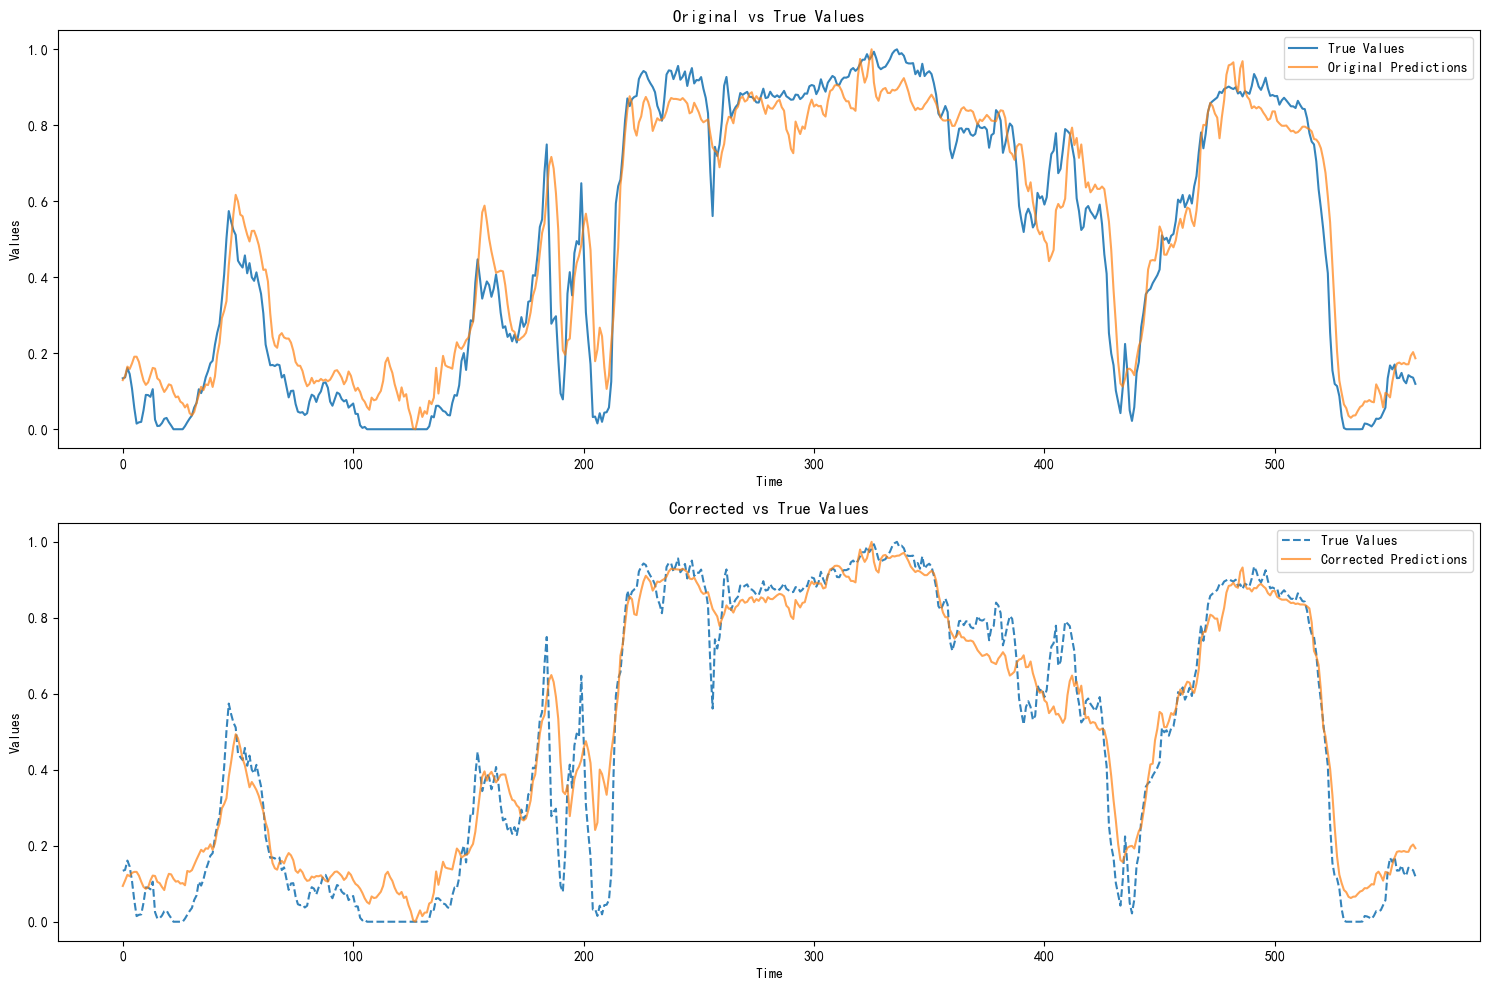

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from scipy.linalg import svd, inv

np.random.seed(0)

def build_hankel(series, m):
    N = len(series)
    H = np.zeros((m, N - m + 1))
    for i in range(m):
        H[i, :] = series[i:i + N - m + 1]
    return H

def dmd_fit(X_train, rank):
    X1 = X_train[:, :-1]
    X2 = X_train[:, 1:]
    U, S, Vh = svd(X1, full_matrices=False)
    U_r = U[:, :rank]
    S_r = np.diag(S[:rank])
    Vh_r = Vh[:rank, :]
    A_tilde = U_r.T @ X2 @ Vh_r.T @ inv(S_r)
    eigenvalues, eigenvectors = np.linalg.eig(A_tilde)
    phi = X2 @ Vh_r.T @ inv(S_r) @ eigenvectors
    return phi, eigenvalues

def dmd_step_predict(phi, eigenvalues, current_state):
    proj = np.linalg.pinv(phi) @ current_state
    next_proj = eigenvalues * proj
    return phi @ next_proj

# 归一化
scaler = MinMaxScaler()
scaler.fit(train_tcn_error.reshape(-1, 1))  # train_tcn_error替换成你的训练集残差

train_error_norm = scaler.transform(train_tcn_error.reshape(-1, 1)).flatten()
test_error_norm = scaler.transform(spring_tcn_error.values.reshape(-1, 1)).flatten()
y_pre_norm = scaler.transform(y_pre_tcn.values.reshape(-1, 1)).flatten()
y_test_norm = scaler.transform(y_spring_test.values.reshape(-1, 1)).flatten()

#训练集拟合DMD
m, r = 12, 5
X_train_hankel = build_hankel(train_error_norm, m)
phi, eigenvalues = dmd_fit(X_train_hankel, rank=r)

#测试集因果修正
n_test = len(test_error_norm)
corrected_test_error = np.zeros(n_test)
corrected_test_error[:m] = test_error_norm[:m]
correction_strength = 0.2

for t in range(m, n_test):
    current_state = test_error_norm[t - m:t]
    dmd_pred = dmd_step_predict(phi, eigenvalues, current_state)
    corrected_test_error[t] = test_error_norm[t] + correction_strength * dmd_pred[-1]

#修正后预测值
corrected_predictions_norm = y_pre_norm + corrected_test_error
corrected_predictions = scaler.inverse_transform(corrected_predictions_norm.reshape(-1, 1)).flatten()

#画图
plt.figure(figsize=(15, 10))
plt.subplot(2, 1, 1)
plt.plot(y_test_norm, label='True Values', alpha=0.9)
plt.plot(y_pre_norm, label='Original Predictions', alpha=0.7)
plt.title("Original vs True Values")
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(y_test_norm, label='True Values', linestyle='--', alpha=0.9)
plt.plot(corrected_predictions_norm, label='Corrected Predictions', alpha=0.7)
plt.title("Corrected vs True Values")
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 用原始量纲计算
original_R2 = r2_score(y_spring_test.values, y_pre_tcn.values)
original_mse = mean_squared_error(y_spring_test.values, y_pre_tcn.values)
original_rmse = np.sqrt(original_mse)
original_mae = mean_absolute_error(y_spring_test.values, y_pre_tcn.values)

# 修正后
corrected_R2 = r2_score(y_spring_test.values, corrected_predictions)
corrected_mse = mean_squared_error(y_spring_test.values, corrected_predictions)
corrected_rmse = np.sqrt(corrected_mse)
corrected_mae = mean_absolute_error(y_spring_test.values, corrected_predictions)

print(f"Original - R2: {original_R2:.4f}, MSE: {original_mse:.4f}, RMSE: {original_rmse:.4f}, MAE: {original_mae:.4f}")
print(f"Corrected - R2: {corrected_R2:.4f}, MSE: {corrected_mse:.4f}, RMSE: {corrected_rmse:.4f}, MAE: {corrected_mae:.4f}")

# R2越大越好，算提升率
R2_improvement = ((corrected_R2 - original_R2) / abs(original_R2)) * 100
# 误差越小越好，算减少率
mse_reduction = ((original_mse - corrected_mse) / original_mse) * 100
rmse_reduction = ((original_rmse - corrected_rmse) / original_rmse) * 100
mae_reduction = ((original_mae - corrected_mae) / original_mae) * 100

print(f"\nR2 Improvement: {R2_improvement:.2f}%")
print(f"MSE Reduction: {mse_reduction:.2f}%")
print(f"RMSE Reduction: {rmse_reduction:.2f}%")
print(f"MAE Reduction: {mae_reduction:.2f}%")

Original Predictions - R2: 0.9253396540561092,MSE: 0.009583176084598972, RMSE: 0.09789369787988894, MAE: 0.0765990130802093
Corrected Predictions - R2: 0.9407847414823571, MSE: 0.007600691399100788, RMSE: 0.08718194422643251, MAE: 0.061267213887075636
R2 Reduction: -1.6691262887682772%
MSE Reduction: 20.687136164431084%
RMSE Reduction: 10.94223007756767%
MAE Reduction: 20.015661529580342%


In [45]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

y_pre_gru = point_prediction_error_df.iloc[:, 6].to_frame(name='y_pre_gru')
spring_gru_error = point_prediction_error_df.iloc[:, 7].to_frame(name='spring_gru_error')
y_spring_test = point_prediction_error_df.iloc[:, -1].to_frame(name='y_spring_test')

# 只用训练集fit scaler
scaler = MinMaxScaler()
scaler.fit(train_gru_error.reshape(-1, 1))

y_pre_gru_normalized = pd.DataFrame(scaler.transform(y_pre_gru), columns=y_pre_gru.columns, index=y_pre_gru.index)
spring_gru_error_normalized = pd.DataFrame(scaler.transform(spring_gru_error), columns=spring_gru_error.columns, index=spring_gru_error.index)
y_spring_test_normalized = pd.DataFrame(scaler.transform(y_spring_test), columns=y_spring_test.columns, index=y_spring_test.index)

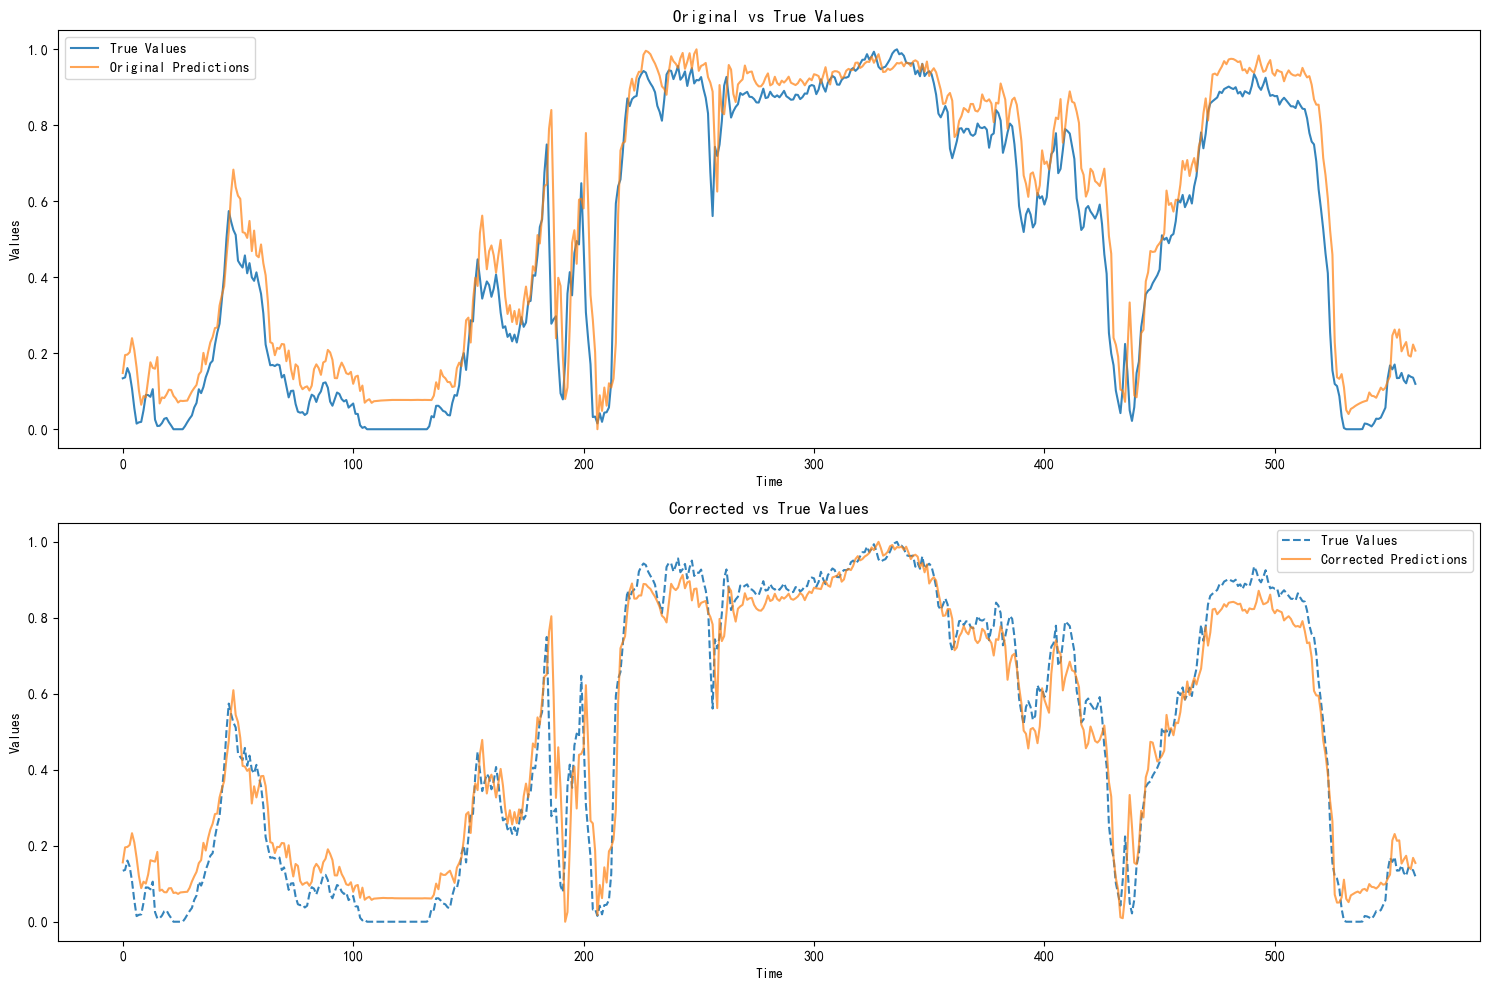

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from scipy.linalg import svd, inv

np.random.seed(0)

def build_hankel(series, m):
    N = len(series)
    H = np.zeros((m, N - m + 1))
    for i in range(m):
        H[i, :] = series[i:i + N - m + 1]
    return H

def dmd_fit(X_train, rank):
    X1 = X_train[:, :-1]
    X2 = X_train[:, 1:]
    U, S, Vh = svd(X1, full_matrices=False)
    U_r = U[:, :rank]
    S_r = np.diag(S[:rank])
    Vh_r = Vh[:rank, :]
    A_tilde = U_r.T @ X2 @ Vh_r.T @ inv(S_r)
    eigenvalues, eigenvectors = np.linalg.eig(A_tilde)
    phi = X2 @ Vh_r.T @ inv(S_r) @ eigenvectors
    return phi, eigenvalues

def dmd_step_predict(phi, eigenvalues, current_state):
    proj = np.linalg.pinv(phi) @ current_state
    next_proj = eigenvalues * proj
    return phi @ next_proj

#归一化
scaler = MinMaxScaler()
scaler.fit(train_gru_error.reshape(-1, 1))  # train_gru_error替换成你的训练集残差

train_error_norm = scaler.transform(train_gru_error.reshape(-1, 1)).flatten()
test_error_norm = scaler.transform(spring_gru_error.values.reshape(-1, 1)).flatten()
y_pre_norm = scaler.transform(y_pre_gru.values.reshape(-1, 1)).flatten()
y_test_norm = scaler.transform(y_spring_test.values.reshape(-1, 1)).flatten()

#训练集拟合DMD
m, r = 12, 5
X_train_hankel = build_hankel(train_error_norm, m)
phi, eigenvalues = dmd_fit(X_train_hankel, rank=r)

#测试集因果修正
n_test = len(test_error_norm)
corrected_test_error = np.zeros(n_test)
corrected_test_error[:m] = test_error_norm[:m]
correction_strength = 0.2

for t in range(m, n_test):
    current_state = test_error_norm[t - m:t]
    dmd_pred = dmd_step_predict(phi, eigenvalues, current_state)
    corrected_test_error[t] = test_error_norm[t] + correction_strength * dmd_pred[-1]

# 修正后预测值
corrected_predictions_norm = y_pre_norm + corrected_test_error
corrected_predictions = scaler.inverse_transform(corrected_predictions_norm.reshape(-1, 1)).flatten()

# 画图
plt.figure(figsize=(15, 10))
plt.subplot(2, 1, 1)
plt.plot(y_test_norm, label='True Values', alpha=0.9)
plt.plot(y_pre_norm, label='Original Predictions', alpha=0.7)
plt.title("Original vs True Values")
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(y_test_norm, label='True Values', linestyle='--', alpha=0.9)
plt.plot(corrected_predictions_norm, label='Corrected Predictions', alpha=0.7)
plt.title("Corrected vs True Values")
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# 原始预测指标
original_R2_gru = r2_score(y_spring_test.values, y_pre_gru.values)
original_gru_mse = mean_squared_error(y_spring_test.values, y_pre_gru.values)
original_gru_rmse = np.sqrt(original_gru_mse)
original_gru_mae = mean_absolute_error(y_spring_test.values, y_pre_gru.values)

# 修正后预测指标
corrected_R2_gru = r2_score(y_spring_test.values, corrected_gru_predictions)
corrected_gru_mse = mean_squared_error(y_spring_test.values, corrected_gru_predictions)
corrected_gru_rmse = np.sqrt(corrected_gru_mse)
corrected_gru_mae = mean_absolute_error(y_spring_test.values, corrected_gru_predictions)

print(f"Original - R2: {original_R2_gru:.4f}, MSE: {original_gru_mse:.4f}, RMSE: {original_gru_rmse:.4f}, MAE: {original_gru_mae:.4f}")
print(f"Corrected - R2: {corrected_R2_gru:.4f}, MSE: {corrected_gru_mse:.4f}, RMSE: {corrected_gru_rmse:.4f}, MAE: {corrected_gru_mae:.4f}")

# R2越大越好，算提升率
R2_gru_improvement = ((corrected_R2_gru - original_R2_gru) / abs(original_R2_gru)) * 100
# 误差指标越小越好，算减少率
mse_gru_reduction = ((original_gru_mse - corrected_gru_mse) / original_gru_mse) * 100
rmse_gru_reduction = ((original_gru_rmse - corrected_gru_rmse) / original_gru_rmse) * 100
mae_gru_reduction = ((original_gru_mae - corrected_gru_mae) / original_gru_mae) * 100

print(f"\nR2 Improvement: {R2_gru_improvement:.2f}%")
print(f"MSE Reduction: {mse_gru_reduction:.2f}%")
print(f"RMSE Reduction: {rmse_gru_reduction:.2f}%")
print(f"MAE Reduction: {mae_gru_reduction:.2f}%")

Original Predictions - R2: 0.925628738303038,MSE: 0.009546070105426512, RMSE: 0.09770399226964327, MAE: 0.07489352891598534
Corrected Predictions - R2: 0.9529213461199806, MSE: 0.006042873552945695, RMSE: 0.07773592189551556, MAE: 0.05792208887313432
R2 Reduction: -2.948548017964338%
MSE Reduction: 36.69778782044987%
RMSE Reduction: 20.437312652506428%
MAE Reduction: 22.66075626091726%


In [48]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 提取对应列
y_pre_rnn = point_prediction_error_df.iloc[:, 8].to_frame(name='y_pre_rnn')
spring_rnn_error = point_prediction_error_df.iloc[:, 9].to_frame(name='spring_rnn_error')
y_spring_test = point_prediction_error_df.iloc[:, -1].to_frame(name='y_spring_test')

# 测试集归一化
scaler = MinMaxScaler()
scaler.fit(train_rnn_error.reshape(-1, 1))

# 统一使用训练集scaler归一化所有测试数据
y_pre_rnn_normalized = pd.DataFrame(
    scaler.transform(y_pre_rnn),
    columns=y_pre_rnn.columns,
    index=y_pre_rnn.index
)
spring_rnn_error_normalized = pd.DataFrame(
    scaler.transform(spring_rnn_error),
    columns=spring_rnn_error.columns,
    index=spring_rnn_error.index
)
y_spring_test_normalized = pd.DataFrame(
    scaler.transform(y_spring_test),
    columns=y_spring_test.columns,
    index=y_spring_test.index
)

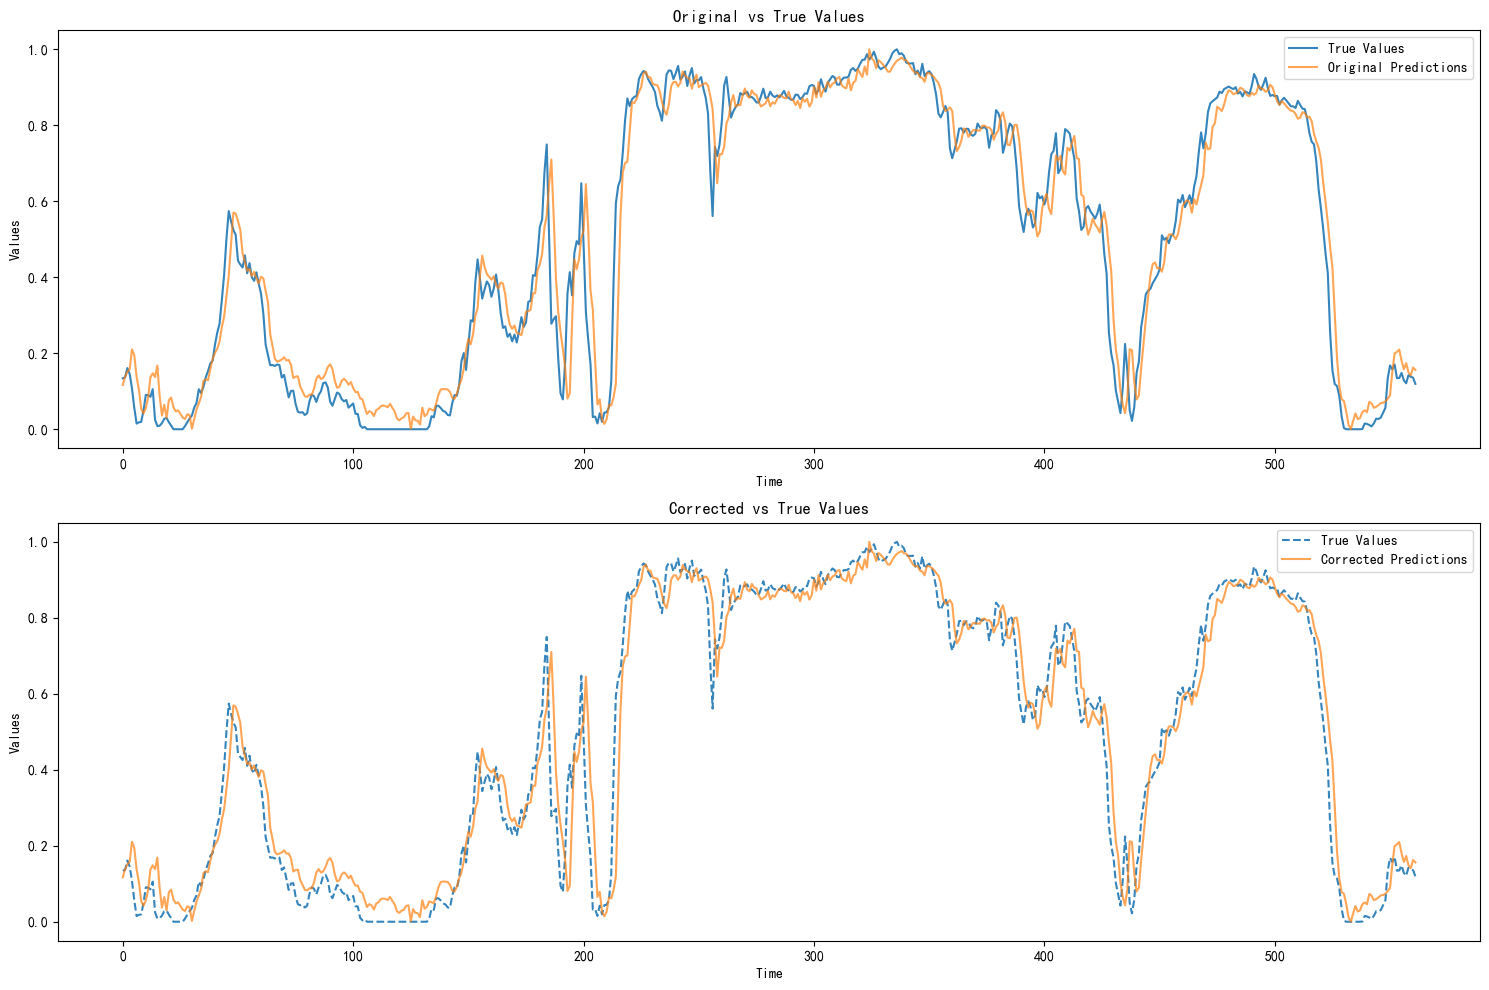

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from scipy.linalg import svd, inv

np.random.seed(0)

# 标准DMD工具函数（仅训练集拟合）
def build_hankel(series, m):
    N = len(series)
    H = np.zeros((m, N - m + 1))
    for i in range(m):
        H[i, :] = series[i:i + N - m + 1]
    return H

def dmd_fit(X_train, rank):
    X1 = X_train[:, :-1]
    X2 = X_train[:, 1:]
    U, S, Vh = svd(X1, full_matrices=False)
    U_r = U[:, :rank]
    S_r = np.diag(S[:rank])
    Vh_r = Vh[:rank, :]
    A_tilde = U_r.T @ X2 @ Vh_r.T @ inv(S_r)
    eigenvalues, eigenvectors = np.linalg.eig(A_tilde)
    phi = X2 @ Vh_r.T @ inv(S_r) @ eigenvectors
    return phi, eigenvalues

def dmd_step_predict(phi, eigenvalues, current_state):
    proj = np.linalg.pinv(phi) @ current_state
    next_proj = eigenvalues * proj
    return phi @ next_proj

# 归一化
scaler = MinMaxScaler()
scaler.fit(train_rnn_error.reshape(-1, 1))

train_error_norm = scaler.transform(train_rnn_error.reshape(-1, 1)).flatten()
test_error_norm = scaler.transform(spring_rnn_error.values.reshape(-1, 1)).flatten()
y_pre_norm = scaler.transform(y_pre_rnn.values.reshape(-1, 1)).flatten()
y_test_norm = scaler.transform(y_spring_test.values.reshape(-1, 1)).flatten()

# 拟合DMD算子
m = 12   # 嵌入维度
r = 5    # 截断秩，和论文保持一致
X_train_hankel = build_hankel(train_error_norm)
phi, eigenvalues = dmd_fit(X_train_hankel, rank=r)

# 逐点因果修正
n_test = len(test_error_norm)
corrected_test_error = np.zeros(n_test)
corrected_test_error[:m] = test_error_norm[:m]
correction_strength = 0.2

for t in range(m, n_test):
    current_state = test_error_norm[t - m:t]
    dmd_pred = dmd_step_predict(phi, eigenvalues, current_state)
    corrected_test_error[t] = test_error_norm[t] + correction_strength * dmd_pred[-1]

corrected_predictions_norm = y_pre_norm + corrected_test_error
corrected_predictions = scaler.inverse_transform(corrected_predictions_norm.reshape(-1, 1)).flatten()

plt.figure(figsize=(15, 10))
plt.subplot(2, 1, 1)
plt.title("Original vs True Values")
plt.plot(y_test_norm, label='True Values', alpha=0.9)
plt.plot(y_pre_norm, label='Original Predictions', alpha=0.7)
plt.legend()
plt.xlabel("Time")
plt.ylabel("Values")

plt.subplot(2, 1, 2)
plt.title("Corrected vs True Values")
plt.plot(y_test_norm, label='True Values', linestyle='--', alpha=0.9)
plt.plot(corrected_predictions_norm, label='Corrected Predictions', alpha=0.7)
plt.legend()
plt.xlabel("Time")
plt.ylabel("Values")
plt.tight_layout()
plt.show()

In [50]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

original_R2_rnn = r2_score(y_spring_test.values, y_pre_rnn.values)
original_rnn_mse = mean_squared_error(y_spring_test.values, y_pre_rnn.values)
original_rnn_rmse = np.sqrt(original_rnn_mse)
original_rnn_mae = mean_absolute_error(y_spring_test.values, y_pre_rnn.values)

corrected_R2_rnn = r2_score(y_spring_test.values, corrected_predictions)
corrected_rnn_mse = mean_squared_error(y_spring_test.values, corrected_predictions)
corrected_rnn_rmse = np.sqrt(corrected_rnn_mse)
corrected_rnn_mae = mean_absolute_error(y_spring_test.values, corrected_predictions)

print(f"Original - R2: {original_R2_rnn:.4f}, MSE: {original_rnn_mse:.4f}, RMSE: {original_rnn_rmse:.4f}, MAE: {original_rnn_mae:.4f}")
print(f"Corrected - R2: {corrected_R2_rnn:.4f}, MSE: {corrected_rnn_mse:.4f}, RMSE: {corrected_rnn_rmse:.4f}, MAE: {corrected_rnn_mae:.4f}")

# R2越大越好，计算提升比例；误差指标越小越好，计算下降比例
R2_rnn_improvement = ((corrected_R2_rnn - original_R2_rnn) / abs(original_R2_rnn)) * 100
mse_rnn_reduction = ((original_rnn_mse - corrected_rnn_mse) / original_rnn_mse) * 100
rmse_rnn_reduction = ((original_rnn_rmse - corrected_rnn_rmse) / original_rnn_rmse) * 100
mae_rnn_reduction = ((original_rnn_mae - corrected_rnn_mae) / original_rnn_mae) * 100

print(f"\nR2 Improvement: {R2_rnn_improvement:.2f}%")
print(f"MSE Reduction: {mse_rnn_reduction:.2f}%")
print(f"RMSE Reduction: {rmse_rnn_reduction:.2f}%")
print(f"MAE Reduction: {mae_rnn_reduction:.2f}%")

Original Predictions - R2: 0.9532298066768894,MSE: 0.006003280489256543, RMSE: 0.07748083949762381, MAE: 0.050913537678183414
Corrected Predictions - R2: 0.9534662432825792, MSE: 0.005972932202002786, RMSE: 0.07728474753793782, MAE: 0.05074027058795354
R2 Reduction: -0.024803736101590628%
MSE Reduction: 0.5055283908201182%
RMSE Reduction: 0.2530844541146286%
MAE Reduction: 0.34031634439757724%


In [51]:
#将DMD修正后的预测值进行反归一化
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import os

# 对归一化后的预测值进行反归一化
corrected_itransformer_predictions = scaler.inverse_transform(corrected_itransformer_predictions_normalized)
corrected_lstm_predictions = scaler.inverse_transform(corrected_lstm_predictions_normalized)
corrected_tcn_predictions = scaler.inverse_transform(corrected_tcn_predictions_normalized)
corrected_gru_predictions = scaler.inverse_transform(corrected_gru_predictions_normalized)
corrected_rnn_predictions = scaler.inverse_transform(corrected_rnn_predictions_normalized)

y_pre_itransformer_dmd = corrected_itransformer_predictions.flatten()
y_pre_lstm_dmd = corrected_lstm_predictions.flatten()
y_pre_tcn_dmd = corrected_tcn_predictions.flatten()
y_pre_gru_dmd = corrected_gru_predictions.flatten()
y_pre_rnn_dmd = corrected_rnn_predictions.flatten()

# 创建一个DataFrame
dmd_df = pd.DataFrame({
    'itranformer_DMD': y_pre_itransformer_dmd,
    'LSTM_DMD': y_pre_lstm_dmd,
    'TCN_DMD': y_pre_tcn_dmd,
    'GRU_DMD': y_pre_gru_dmd,
    'RNN_DMD': y_pre_rnn_dmd,
    'True_power': y_spring_test.values.flatten()
})

# 将合并后的 DataFrame 保存到 Excel 文件中
directory = 'D:\\article'
if not os.path.exists(directory):
    os.makedirs(directory)

file_path = os.path.join(directory, 'DMD_Corrected_Predictions.xlsx')
dmd_df.to_excel(file_path, index=False)

# 显示 DataFrame
dmd_df

,itransformer_DMD,LSTM_DMD,TCN_DMD,GRU_DMD,RNN_DMD
0,9.962436,9.962436,9.900879,9.962873,9.923421
1,10.139144,10.139144,10.072912,10.160266,10.102994
2,11.761565,11.761565,11.711256,11.784593,11.739074
3,10.673815,10.673815,10.669233,10.751582,10.707500
4,8.172756,8.172756,8.152843,8.257312,8.234728
...,...,...,...,...,...
557,9.130854,9.130854,9.121937,9.111578,9.111016
558,10.516694,10.516694,10.527218,10.487464,10.492150
559,10.220750,10.220750,10.272691,10.213888,10.216187
560,10.081159,10.081159,10.124874,10.089661,10.083999


In [52]:
#电力调度成本缩减
#导入文件
dispatch_data = pd.read_excel(r'D:\article\DMD_Corrected_Predictions3.xlsx', sheet_name=None)
dispatch_df = pd.concat(dispatch_data.values(), ignore_index=True)
dispatch_df

,wind_power_cost,renewable_energy_cost,coal_power_cost,storage_discharge_cost,storage_charge_cost,itransformer_DMD,y_pre_itransformer,itransformer_Lower_Bound,itransformer_Upper_Bound,LSTM_DMD,...,GRU_DMD,y_pre_gru,GRU_Lower_Bound,GRU_Upper_Bound,RNN_DMD,y_pre_rnn,RNN_Lower_Bound,RNN_Upper_Bound,load,y_spring_test
0,0.053782,0.060699,0.076495,0.003037,0.210347,9.962436,2.429182,-3.116279,29.890399,9.962436,...,9.962873,4.965600,0.209537,12.896957,9.923421,5.090504,-18.717763,21.514854,4353.886528,8.871966
1,0.021940,0.024459,0.029540,0.014507,0.243904,10.139144,2.056130,-2.878301,30.410509,10.139144,...,10.160266,8.061377,1.643586,14.021574,10.102994,6.590096,-13.934827,23.027571,4284.965344,9.029788
2,0.015536,0.015536,0.098318,0.012281,0.409694,11.761565,3.533957,-1.518540,31.936571,11.761565,...,11.784593,8.148346,2.779839,15.334053,11.739074,7.457572,-13.343762,26.310296,4206.121600,10.653004
3,0.017652,0.059853,0.090693,0.012900,0.099487,10.673815,4.504742,-0.407139,29.020230,10.673815,...,10.751582,8.562465,3.410069,16.256024,10.707500,7.911440,-14.311451,20.846659,4154.520160,9.614700
4,0.027436,0.039884,0.067455,0.011544,0.316224,8.172756,6.095626,0.650474,29.243909,8.172756,...,8.257312,10.978879,4.406618,17.622443,8.234728,11.443765,-12.879909,23.871477,4101.861280,7.089543
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
550,0.028602,0.046789,0.081994,0.019032,0.535989,12.130540,1.953023,2.067363,13.380244,12.130540,...,12.168568,4.386850,0.889390,10.001908,12.133413,3.242170,-13.354217,15.886861,6990.885184,11.109858
551,0.045980,0.046322,0.090314,0.023124,0.299182,11.503137,3.950936,3.165241,15.360669,11.503137,...,11.578804,11.426349,3.378655,13.395499,11.516426,7.473858,-8.768175,21.609229,6589.038880,10.430114
552,0.053142,0.068037,0.073581,0.008226,0.240339,12.367083,6.657997,3.425046,18.030691,12.367083,...,12.439534,12.455806,5.552303,17.089145,12.408198,10.708942,-7.549350,25.642203,6495.045184,11.273910
553,0.031901,0.050293,0.118162,0.023605,0.394483,9.994980,8.209389,4.221242,18.880581,9.994980,...,10.046015,11.057172,5.900804,18.757873,10.036699,10.988184,-8.470747,23.040205,6553.640320,8.898269


In [53]:
#itransformer电力调度
import pulp
import pandas as pd

# 储能系统的成本和收益
storage_initial_investment = 500  # 初始投资成本（$/kWh）
storage_degradation_maintenance = 0.05 * storage_initial_investment  # 折旧和维护成本（$/kWh/year）

# 创建一个空列表来存储Total Cost结果
total_costs_itransformer = []

# 遍历dispatch_df中的每一行数据
for index, row in dispatch_df.iterrows():
    # 定义问题
    problem = pulp.LpProblem("Power_Dispatch_Optimization_with_Storage", pulp.LpMinimize)

    # 决策变量
    wind_power = pulp.LpVariable('WindPower', lowBound=row['itransformer_Lower_Bound'], upBound=row['itransformer_Upper_Bound'], cat='Continuous')
    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row.iloc[-2] * 0.5 -row['y_pre_itransformer'], cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row.iloc[-2] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    # 目标函数：最小化总成本，包括储能成本
    objective = (row['wind_power_cost'] * wind_power + row['renewable_energy_cost'] * renewable_power +
                row['coal_power_cost'] * thermal_power+row['storage_discharge_cost'] * energy_discharge +
                row['storage_charge_cost'] * energy_charge + storage_degradation_maintenance)
    problem += objective, "Total Cost"

    # 约束条件
    problem += row['y_spring_test'] + renewable_power + thermal_power +energy_charge  == row.iloc[-2]+energy_discharge, "Total Demand with Storage"
    problem +=row['y_pre_itransformer'] + renewable_power + thermal_power == row.iloc[-2]

    # 解决问题
    problem.solve()

    # 将Total Cost添加到列表中
    total_costs_itransformer.append(pulp.value(problem.objective))

#     # 输出决策变量的最优解
#     print(f"Row {index}:")
#     print(f"Wind Power Optimal Value: {pulp.value(wind_power)}")
#     print(f"Renewable Power Optimal Value: {pulp.value(renewable_power)}")
#     print(f"Thermal Power Optimal Value: {pulp.value(thermal_power)}")
#     print(f"Energy Discharge Optimal Value: {pulp.value(energy_discharge)}")
#     print(f"Energy Charge Optimal Value: {pulp.value(energy_charge)}\n")

# 创建一个DataFrame来存储Total Cost结果
total_costs_itransformer_df = pd.DataFrame(total_costs_itransformer, columns=["itransformer Cost"])

# 输出结果DataFrame
print(total_costs_itransformer_df)

     itransformer Cost
0           323.368865
1           140.681213
2           264.448977
3           337.511333
4           244.929683
..                 ...
550         475.298646
551         475.262330
552         484.676299
553         576.736776
554         660.115224

[555 rows x 1 columns]


In [54]:
# ===================== 新增：Excel保存功能 =====================
# 确保保存目录存在
directory = 'D:\\article'
if not os.path.exists(directory):
    os.makedirs(directory)

# 定义Excel文件保存路径
file_path = os.path.join(directory, 'iTransformer_Power_Dispatch_Total_Costs.xlsx')

# 保存DataFrame到Excel
total_costs_itransformer_df.to_excel(file_path, index=False)

# 输出保存结果
print(f"✅ iTransformer电力调度成本结果已保存至：{file_path}")

✅ iTransformer电力调度成本结果已保存至：D:\article\iTransformer_Power_Dispatch_Total_Costs.xlsx


In [55]:
#itransformer_dmd电力调度
import pulp
import pandas as pd

# 储能系统的成本和收益
storage_initial_investment = 500  # 初始投资成本（$/kWh）
storage_degradation_maintenance = 0.05 * storage_initial_investment  # 折旧和维护成本（$/kWh/year）

# 创建一个空列表来存储Total Cost结果
total_costs_itransformer_dmd = []

# 遍历dispatch_df中的每一行数据
for index, row in dispatch_df.iterrows():
    # 定义问题
    problem = pulp.LpProblem("Power_Dispatch_Optimization_with_Storage", pulp.LpMinimize)

    # 决策变量
    wind_power = pulp.LpVariable('WindPower', lowBound=row['itransformer_Lower_Bound'], upBound=row['itransformer_Upper_Bound'], cat='Continuous')
    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row.iloc[-2] * 0.5 -row['itransformer_DMD'], cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row.iloc[-2] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    # 目标函数：最小化总成本，包括储能成本
    objective = (row['wind_power_cost'] * wind_power + row['renewable_energy_cost'] * renewable_power +
                row['coal_power_cost'] * thermal_power+row['storage_discharge_cost'] * energy_discharge +
                row['storage_charge_cost'] * energy_charge + storage_degradation_maintenance)
    problem += objective, "Total Cost"

    # 约束条件
    problem +=row['y_spring_test'] + renewable_power + thermal_power +energy_charge  == row.iloc[-2]+energy_discharge, "Total Demand with Storage"
    problem +=row['itransformer_DMD'] + renewable_power + thermal_power == row.iloc[-2]
   # problem +=renewable_power +row['y_spring_test']== row.iloc[-2]*0.5

    # 解决问题
    problem.solve()

    # 将Total Cost添加到列表中
    total_costs_itransformer_dmd.append(pulp.value(problem.objective))

#     # 输出决策变量的最优解
#     print(f"Row {index}:")
#     print(f"Wind Power Optimal Value: {pulp.value(wind_power)}")
#     print(f"Renewable Power Optimal Value: {pulp.value(renewable_power)}")
#     print(f"Thermal Power Optimal Value: {pulp.value(thermal_power)}")
#     print(f"Energy Discharge Optimal Value: {pulp.value(energy_discharge)}")
#     print(f"Energy Charge Optimal Value: {pulp.value(energy_charge)}\n")

# 创建一个DataFrame来存储Total Cost结果
total_costs_itransformer_dmd = pd.DataFrame(total_costs_itransformer_dmd, columns=["itransformer Cost"])

# 输出结果DataFrame
print(total_costs_itransformer_dmd)

     itransformer Cost
0           323.121412
1           140.652914
2           264.687899
3           337.181552
4           245.177905
..                 ...
550         475.195245
551         475.083702
552         484.512627
553         577.063345
554         660.409617

[555 rows x 1 columns]


In [56]:
# ===================== 新增：Excel保存功能 =====================
# 确保保存目录存在
directory = 'D:\\article'
if not os.path.exists(directory):
    os.makedirs(directory)

# 定义Excel文件保存路径
file_path = os.path.join(directory, 'total_costs_itransformer_dmd.xlsx')

# 保存DataFrame到Excel
total_costs_itransformer_dmd.to_excel(file_path, index=False)

# 输出保存结果
print(f"✅ iTransformer_DMD电力调度成本结果已保存至：{file_path}")

✅ iTransformer_DMD电力调度成本结果已保存至：D:\article\total_costs_itransformer_dmd.xlsx


In [31]:
#lstm电力调度
import pulp
import pandas as pd

# 储能系统的成本和收益
storage_initial_investment = 500  # 初始投资成本（$/kWh）
storage_degradation_maintenance = 0.05 * storage_initial_investment  # 折旧和维护成本（$/kWh/year）

# 创建一个空列表来存储Total Cost结果
total_costs_LSTM = []

# 遍历dispatch_df中的每一行数据
for index, row in dispatch_df.iterrows():
    # 定义问题
    problem = pulp.LpProblem("Power_Dispatch_Optimization_with_Storage", pulp.LpMinimize)

    # 决策变量
    wind_power = pulp.LpVariable('WindPower', lowBound=row['LSTM_Lower_Bound'], upBound=row['LSTM_Upper_Bound'], cat='Continuous')
    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row.iloc[-2] * 0.5 -row['y_pre_lstm'], cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row.iloc[-2] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    # 目标函数：最小化总成本，包括储能成本
    objective = (row['wind_power_cost'] * wind_power + row['renewable_energy_cost'] * renewable_power +
                row['coal_power_cost'] * thermal_power+row['storage_discharge_cost'] * energy_discharge +
                row['storage_charge_cost'] * energy_charge + storage_degradation_maintenance)
    problem += objective, "Total Cost"

    # 约束条件
    problem += row['y_spring_test'] + renewable_power + thermal_power +energy_charge  == row.iloc[-2]+energy_discharge, "Total Demand with Storage"
    problem +=row['y_pre_lstm'] + renewable_power + thermal_power == row.iloc[-2]

    # 解决问题
    problem.solve()

    # 将Total Cost添加到列表中
    total_costs_LSTM.append(pulp.value(problem.objective))

#     # 输出决策变量的最优解
#     print(f"Row {index}:")
#     print(f"Wind Power Optimal Value: {pulp.value(wind_power)}")
#     print(f"Renewable Power Optimal Value: {pulp.value(renewable_power)}")
#     print(f"Thermal Power Optimal Value: {pulp.value(thermal_power)}")
#     print(f"Energy Discharge Optimal Value: {pulp.value(energy_discharge)}")
#     print(f"Energy Charge Optimal Value: {pulp.value(energy_charge)}\n")

# 创建一个DataFrame来存储Total Cost结果
total_costs_LSTM_df = pd.DataFrame(total_costs_LSTM, columns=["LSTM Cost"])

# 输出结果DataFrame
print(total_costs_LSTM_df)

      LSTM Cost
0    323.624224
1    140.744196
2    264.524715
3    337.636581
4    245.051028
..          ...
550  475.374540
551  475.235128
552  484.895239
553  577.009890
554  660.262337

[555 rows x 1 columns]


In [32]:
#lstm_dmd电力调度
import pulp
import pandas as pd

# 储能系统的成本和收益
storage_initial_investment = 500  # 初始投资成本（$/kWh）
storage_degradation_maintenance = 0.05 * storage_initial_investment  # 折旧和维护成本（$/kWh/year）

# 创建一个空列表来存储Total Cost结果
total_costs_LSTM_dmd = []

# 遍历dispatch_df中的每一行数据
for index, row in dispatch_df.iterrows():
    # 定义问题
    problem = pulp.LpProblem("Power_Dispatch_Optimization_with_Storage", pulp.LpMinimize)

    # 决策变量
    wind_power = pulp.LpVariable('WindPower', lowBound=row['LSTM_Lower_Bound'], upBound=row['LSTM_Upper_Bound'], cat='Continuous')
    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row.iloc[-2] * 0.5 -row['LSTM_DMD'], cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row.iloc[-2] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    # 目标函数：最小化总成本，包括储能成本
    objective = (row['wind_power_cost'] * wind_power + row['renewable_energy_cost'] * renewable_power +
                row['coal_power_cost'] * thermal_power +row['storage_discharge_cost'] * energy_discharge +
                row['storage_charge_cost'] * energy_charge + storage_degradation_maintenance)
    problem += objective, "Total Cost"

    # 约束条件
    problem +=row['y_spring_test'] + renewable_power + thermal_power +energy_charge  == row.iloc[-2]+energy_discharge, "Total Demand with Storage"
    problem +=row['LSTM_DMD'] + renewable_power + thermal_power == row.iloc[-2]
   # problem +=renewable_power +row['y_spring_test']== row.iloc[-2]*0.5

    # 解决问题
    problem.solve()

    # 将Total Cost添加到列表中
    total_costs_LSTM_dmd.append(pulp.value(problem.objective))

#     # 输出决策变量的最优解
#     print(f"Row {index}:")
#     print(f"Wind Power Optimal Value: {pulp.value(wind_power)}")
#     print(f"Renewable Power Optimal Value: {pulp.value(renewable_power)}")
#     print(f"Thermal Power Optimal Value: {pulp.value(thermal_power)}")
#     print(f"Energy Discharge Optimal Value: {pulp.value(energy_discharge)}")
#     print(f"Energy Charge Optimal Value: {pulp.value(energy_charge)}\n")

# 创建一个DataFrame来存储Total Cost结果
total_costs_LSTM_dmd = pd.DataFrame(total_costs_LSTM_dmd, columns=["LSTM Cost"])

# 输出结果DataFrame
print(total_costs_LSTM_dmd)

      LSTM Cost
0    323.329944
1    140.756306
2    264.749738
3    337.235742
4    245.258992
..          ...
550  475.133729
551  475.041978
552  484.565502
553  577.058936
554  660.383316

[555 rows x 1 columns]


In [33]:
#TCN 电力调度
import pulp
import pandas as pd

# 储能系统的成本和收益
storage_initial_investment = 500  # 初始投资成本（$/kWh）
storage_degradation_maintenance = 0.05 * storage_initial_investment  # 折旧和维护成本（$/kWh/year）

# 创建一个空列表来存储Total Cost结果
total_costs_TCN  = []

# 遍历dispatch_df中的每一行数据
for index, row in dispatch_df.iterrows():
    # 定义问题
    problem = pulp.LpProblem("Power_Dispatch_Optimization_with_Storage", pulp.LpMinimize)

    # 决策变量
    wind_power = pulp.LpVariable('WindPower', lowBound=row['TCN_Lower_Bound'], upBound=row['TCN_Upper_Bound'], cat='Continuous')
    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row.iloc[-2] * 0.5 -row['y_pre_tcn'], cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row.iloc[-2] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    # 目标函数：最小化总成本，包括储能成本
    objective = (row['wind_power_cost'] * wind_power + row['renewable_energy_cost'] * renewable_power +
                row['coal_power_cost'] * thermal_power+row['storage_discharge_cost'] * energy_discharge +
                row['storage_charge_cost'] * energy_charge + storage_degradation_maintenance)
    problem += objective, "Total Cost"

    # 约束条件
    problem += row['y_spring_test'] + renewable_power + thermal_power +energy_charge  == row.iloc[-2]+energy_discharge, "Total Demand with Storage"
    problem +=row['y_pre_tcn'] + renewable_power + thermal_power == row.iloc[-2]
   # problem +=renewable_power +row['y_spring_test']== row.iloc[-2]*0.5

    # 解决问题
    problem.solve()

    # 将Total Cost添加到列表中
    total_costs_TCN .append(pulp.value(problem.objective))

total_costs_TCN  = pd.DataFrame(total_costs_TCN , columns=["TCN Cost"])

# 输出结果DataFrame
print(total_costs_TCN )

       TCN Cost
0    323.556353
1    140.708894
2    264.455469
3    337.541790
4    245.007008
..          ...
550  475.353717
551  475.229738
552  484.729339
553  576.888841
554  660.263428

[555 rows x 1 columns]


In [34]:
#TCN_DMD电力调度
import pulp
import pandas as pd

# 储能系统的成本和收益
storage_initial_investment = 500  # 初始投资成本（$/kWh）
storage_degradation_maintenance = 0.05 * storage_initial_investment  # 折旧和维护成本（$/kWh/year）

# 创建一个空列表来存储Total Cost结果
total_costs_TCN_dmd = []

# 遍历dispatch_df中的每一行数据
for index, row in dispatch_df.iterrows():
    # 定义问题
    problem = pulp.LpProblem("Power_Dispatch_Optimization_with_Storage", pulp.LpMinimize)

    # 决策变量
    wind_power = pulp.LpVariable('WindPower', lowBound=row['TCN_Lower_Bound'], upBound=row['TCN_Upper_Bound'], cat='Continuous')
    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row.iloc[-2] * 0.5 -row['TCN_DMD'], cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row.iloc[-2] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    # 目标函数：最小化总成本，包括储能成本
    objective = (row['wind_power_cost'] * wind_power + row['renewable_energy_cost'] * renewable_power +
                row['coal_power_cost'] * thermal_power+row['storage_discharge_cost'] * energy_discharge +
                row['storage_charge_cost'] * energy_charge + storage_degradation_maintenance)
    problem += objective, "Total Cost"

    # 约束条件
    problem += row['y_spring_test'] + renewable_power + thermal_power +energy_charge  == row.iloc[-2]+energy_discharge, "Total Demand with Storage"
    problem +=row['TCN_DMD'] + renewable_power + thermal_power == row.iloc[-2]
    #problem +=renewable_power +row['y_spring_test']== row.iloc[-2]*0.5

    # 解决问题
    problem.solve()

    # 将Total Cost添加到列表中
    total_costs_TCN_dmd.append(pulp.value(problem.objective))

total_costs_TCN_dmd = pd.DataFrame(total_costs_TCN_dmd, columns=["TCN Cost"])

# 输出结果DataFrame
print(total_costs_TCN_dmd)

       TCN Cost
0    323.325880
1    140.720515
2    264.714002
3    337.217562
4    245.216618
..          ...
550  475.148452
551  474.958547
552  484.396930
553  577.017075
554  660.322706

[555 rows x 1 columns]


In [35]:
#GRU 电力调度
import pulp
import pandas as pd

# 储能系统的成本和收益
storage_initial_investment = 500  # 初始投资成本（$/kWh）
storage_degradation_maintenance = 0.05 * storage_initial_investment  # 折旧和维护成本（$/kWh/year）

# 创建一个空列表来存储Total Cost结果
total_costs_GRU  = []

# 遍历dispatch_df中的每一行数据
for index, row in dispatch_df.iterrows():
    # 定义问题
    problem = pulp.LpProblem("Power_Dispatch_Optimization_with_Storage", pulp.LpMinimize)

    # 决策变量
    wind_power = pulp.LpVariable('WindPower', lowBound=row['GRU_Lower_Bound'], upBound=row['GRU_Upper_Bound'], cat='Continuous')
    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row.iloc[-2] * 0.5 -row['y_pre_gru'], cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row.iloc[-2] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    # 目标函数：最小化总成本，包括储能成本
    objective = (row['wind_power_cost'] * wind_power + row['renewable_energy_cost'] * renewable_power +
                row['coal_power_cost'] * thermal_power+row['storage_discharge_cost'] * energy_discharge +
                row['storage_charge_cost'] * energy_charge + storage_degradation_maintenance)
    problem += objective, "Total Cost"

    # 约束条件
    problem += row['y_spring_test'] + renewable_power + thermal_power +energy_charge  == row.iloc[-2]+energy_discharge, "Total Demand with Storage"
    problem +=row['y_pre_gru'] + renewable_power + thermal_power == row.iloc[-2]
    #problem +=renewable_power +row['y_spring_test']== row.iloc[-2]*0.5

    # 解决问题
    problem.solve()

    # 将Total Cost添加到列表中
    total_costs_GRU .append(pulp.value(problem.objective))

total_costs_GRU  = pd.DataFrame(total_costs_GRU , columns=["GRU Cost"])

# 输出结果DataFrame
print(total_costs_GRU )

       GRU Cost
0    323.386076
1    140.546420
2    264.387400
3    337.283504
4    246.056404
..          ...
550  475.104751
551  475.074099
552  484.640962
553  577.482521
554  661.227102

[555 rows x 1 columns]


In [36]:
#GRU_DMD电力调度
import pulp
import pandas as pd

# 储能系统的成本和收益
storage_initial_investment = 500  # 初始投资成本（$/kWh）
storage_degradation_maintenance = 0.05 * storage_initial_investment  # 折旧和维护成本（$/kWh/year）

# 创建一个空列表来存储Total Cost结果
total_costs_GRU_dmd = []

# 遍历dispatch_df中的每一行数据
for index, row in dispatch_df.iterrows():
    # 定义问题
    problem = pulp.LpProblem("Power_Dispatch_Optimization_with_Storage", pulp.LpMinimize)

    # 决策变量
    wind_power = pulp.LpVariable('WindPower', lowBound=row['GRU_Lower_Bound'], upBound=row['GRU_Upper_Bound'], cat='Continuous')
    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row.iloc[-2] * 0.5 -row['GRU_DMD'], cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row.iloc[-2] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    # 目标函数：最小化总成本，包括储能成本
    objective = (row['wind_power_cost'] * wind_power + row['renewable_energy_cost'] * renewable_power +
                row['coal_power_cost'] * thermal_power+row['storage_discharge_cost'] * energy_discharge +
                row['storage_charge_cost'] * energy_charge + storage_degradation_maintenance)
    problem += objective, "Total Cost"

    # 约束条件
    problem += row['y_spring_test'] + renewable_power + thermal_power +energy_charge  == row.iloc[-2]+energy_discharge, "Total Demand with Storage"
    problem +=row['GRU_DMD'] + renewable_power + thermal_power == row.iloc[-2]
    #problem +=renewable_power +row['y_spring_test']== row.iloc[-2]*0.5

    # 解决问题
    problem.solve()

    # 将Total Cost添加到列表中
    total_costs_GRU_dmd.append(pulp.value(problem.objective))

total_costs_GRU_dmd = pd.DataFrame(total_costs_GRU_dmd, columns=["GRU Cost"])

# 输出结果DataFrame
print(total_costs_GRU_dmd)

       GRU Cost
0    323.300350
1    140.756761
2    264.763754
3    337.252012
4    245.304323
..          ...
550  475.180152
551  475.112646
552  484.638160
553  577.134488
554  660.498071

[555 rows x 1 columns]


In [37]:
#RNN 电力调度
import pulp
import pandas as pd

# 储能系统的成本和收益
storage_initial_investment = 500  # 初始投资成本（$/kWh）
storage_degradation_maintenance = 0.05 * storage_initial_investment  # 折旧和维护成本（$/kWh/year）

# 创建一个空列表来存储Total Cost结果
total_costs_RNN  = []

# 遍历dispatch_df中的每一行数据
for index, row in dispatch_df.iterrows():
    # 定义问题
    problem = pulp.LpProblem("Power_Dispatch_Optimization_with_Storage", pulp.LpMinimize)

    # 决策变量
    wind_power = pulp.LpVariable('WindPower', lowBound= row['RNN_Lower_Bound'], upBound=row['RNN_Upper_Bound'], cat='Continuous')
    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row.iloc[-2] * 0.5 -row['y_pre_rnn'], cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row.iloc[-2] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    # 目标函数：最小化总成本，包括储能成本
    objective = (row['wind_power_cost'] * wind_power + row['renewable_energy_cost'] * renewable_power +
                row['coal_power_cost'] * thermal_power+row['storage_discharge_cost'] * energy_discharge +
                row['storage_charge_cost'] * energy_charge + storage_degradation_maintenance)
    problem += objective, "Total Cost"

    # 约束条件
    problem += row['y_spring_test'] + renewable_power + thermal_power +energy_charge  == row.iloc[-2]+energy_discharge, "Total Demand with Storage"
    problem +=row['y_pre_rnn'] + renewable_power + thermal_power == row.iloc[-2]
    #problem +=renewable_power +row['y_spring_test']== row.iloc[-2]*0.5

    # 解决问题
    problem.solve()

    # 将Total Cost添加到列表中
    total_costs_RNN .append(pulp.value(problem.objective))

total_costs_RNN  = pd.DataFrame(total_costs_RNN , columns=["RNN Cost"])

# 输出结果DataFrame
print(total_costs_RNN )

       RNN Cost
0    323.130176
1    140.478523
2    264.356580
3    337.239018
4    246.078803
..          ...
550  475.008683
551  474.786497
552  484.264637
553  577.272378
554  660.632806

[555 rows x 1 columns]


In [38]:
#RNN_DMD电力调度
import pulp
import pandas as pd

# 储能系统的成本和收益
storage_initial_investment = 500  # 初始投资成本（$/kWh）
storage_degradation_maintenance = 0.05 * storage_initial_investment  # 折旧和维护成本（$/kWh/year）

# 创建一个空列表来存储Total Cost结果
total_costs_RNN_dmd = []

# 遍历dispatch_df中的每一行数据
for index, row in dispatch_df.iterrows():
    # 定义问题
    problem = pulp.LpProblem("Power_Dispatch_Optimization_with_Storage", pulp.LpMinimize)

    # 决策变量
    wind_power = pulp.LpVariable('WindPower', lowBound=row['RNN_Lower_Bound'], upBound=row['RNN_Upper_Bound'], cat='Continuous')
    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row.iloc[-2] * 0.5 -row['RNN_DMD'], cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row.iloc[-2] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    # 目标函数：最小化总成本，包括储能成本
    objective = (row['wind_power_cost'] * wind_power + row['renewable_energy_cost'] * renewable_power +
                row['coal_power_cost'] * thermal_power+row['storage_discharge_cost'] * energy_discharge +
                row['storage_charge_cost'] * energy_charge + storage_degradation_maintenance)
    problem += objective, "Total Cost"

    # 约束条件
    problem += row['y_spring_test'] + renewable_power + thermal_power +energy_charge  == row.iloc[-2]+energy_discharge, "Total Demand with Storage"
    problem +=row['RNN_DMD'] + renewable_power + thermal_power == row.iloc[-2]

    # 解决问题
    problem.solve()

    # 将Total Cost添加到列表中
    total_costs_RNN_dmd.append(pulp.value(problem.objective))

total_costs_RNN_dmd = pd.DataFrame(total_costs_RNN_dmd, columns=["RNN Cost"])

# 输出结果DataFrame
print(total_costs_RNN_dmd)

       RNN Cost
0    323.046504
1    140.618965
2    264.695778
3    337.158418
4    245.192016
..          ...
550  474.991543
551  474.855881
552  484.416994
553  576.944887
554  660.234054

[555 rows x 1 columns]


In [39]:
import pandas as pd
# 合并DataFrame
combined_df = pd.concat([total_costs_LSTM_dmd, total_costs_LSTM_df,total_costs_TCN_dmd, total_costs_TCN,total_costs_GRU_dmd, total_costs_GRU,total_costs_RNN_dmd, total_costs_RNN], axis=1)
# 为列命名，以便区分
combined_df.columns = ['LSTM_DMD Cost', 'LSTM Cost','TCN_DMD Cost', 'TCN Cost','GRU_DMD Cost', 'GRU Cost','RNN_DMD Cost', 'RNN Cost']
# 保存到Excel文件
output_file_path = r'D:\article\Combined_Total_Costs3.xlsx'
combined_df.to_excel(output_file_path, index=False)

In [57]:
#电力调度成本缩减
#导入文件
dispatch_data = pd.read_excel(r'D:\article\All_DMD_Predictions.xlsx', sheet_name=None)
dispatch_df = pd.concat(dispatch_data.values(), ignore_index=True)
dispatch_df

,wind_power_cost,renewable_energy_cost,coal_power_cost,storage_discharge_cost,storage_charge_cost,iTransformer_DMD1,y_pre_iTransformer1,iTransformer_Lower_Bound1,iTransformer_Upper_Bound1,LSTM_DMD1,...,GRU_Lower_Bound3,GRU_Upper_Bound3,RNN_DMD3,y_pre_rnn3,RNN_Lower_Bound3,RNN_Upper_Bound3,y_spring_test1,y_spring_test2,y_spring_test3,load
0,0.053782,0.060699,0.076495,0.003037,0.210347,79.770902,75.677200,29.862971,134.547322,79.770861,...,0.209537,12.896957,9.923421,5.090504,-4.400511,23.842852,78.106528,6.156324,8.871966,4353.886528
1,0.021940,0.024459,0.029540,0.014507,0.243904,80.374739,68.949440,30.702031,134.248468,80.437136,...,1.643586,14.021574,10.102994,6.590096,-4.064147,26.027521,78.789757,8.939160,9.029788,4284.965344
2,0.015536,0.015536,0.098318,0.012281,0.409694,84.086216,69.585251,31.074451,133.885278,84.115132,...,2.779839,15.334053,11.739074,7.457572,-0.440729,26.319647,82.493731,11.188410,10.653004,4206.121600
3,0.017652,0.059853,0.090693,0.012900,0.099487,83.070894,69.701553,32.537690,133.428576,83.106266,...,3.410069,16.256024,10.707500,7.911440,-1.793334,24.967316,81.477037,7.696126,9.614700,4154.520160
4,0.027436,0.039884,0.067455,0.011544,0.316224,82.609437,66.923439,36.718644,133.616519,82.717497,...,4.406618,17.622443,8.234728,11.443765,0.540623,24.571905,81.048365,7.020652,7.089543,4101.861280
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
550,0.028602,0.046789,0.081994,0.019032,0.535989,12.266073,12.225561,-3.041801,59.383746,12.307748,...,0.889390,10.001908,12.133413,3.242170,-5.103598,26.616474,11.433560,53.601428,11.109858,6990.885184
551,0.045980,0.046322,0.090314,0.023124,0.299182,16.191032,13.410572,-4.040455,54.539595,16.152211,...,3.378655,13.395499,11.516426,7.473858,-1.862655,31.421349,15.344536,59.548803,10.430114,6589.038880
552,0.053142,0.068037,0.073581,0.008226,0.240339,17.622399,13.132576,-4.850466,50.065266,17.627177,...,5.552303,17.089145,12.408198,10.708942,1.492157,35.039827,16.779260,62.731328,11.273910,6495.045184
553,0.031901,0.050293,0.118162,0.023605,0.394483,16.380238,10.536007,-7.229394,41.674992,16.452289,...,5.900804,18.757873,10.036699,10.988184,0.057794,36.293832,15.567741,54.060071,8.898269,6553.640320


In [58]:
import pulp
import pandas as pd

# 储能系统的成本和收益
storage_initial_investment = 500  # 初始投资成本（$/kWh）
storage_degradation_maintenance = 0.05 * storage_initial_investment  # 折旧和维护成本（$/kWh/year）

# 创建一个空列表来存储Total Cost结果
total_costs_iTransformer = []

# 遍历dispatch_df中的每一行数据
for index, row in dispatch_df.iterrows():
    # 定义问题
    problem = pulp.LpProblem("Power_Dispatch_Optimization_with_Storage", pulp.LpMinimize)

    # 决策变量
    wind_power_1 = pulp.LpVariable('WindPower_1', lowBound=row['iTransformer_Lower_Bound1'], upBound=row['iTransformer_Upper_Bound1'], cat='Continuous')
    wind_power_2 = pulp.LpVariable('WindPower_2', lowBound=row['iTransformer_Lower_Bound2'], upBound=row['iTransformer_Upper_Bound2'], cat='Continuous')
    wind_power_3 = pulp.LpVariable('WindPower_3', lowBound=row['iTransformer_Lower_Bound3'], upBound=row['iTransformer_Upper_Bound3'], cat='Continuous')
    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row.iloc[-1] * 0.5, cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row.iloc[-1] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    # 目标函数：最小化总成本，包括储能成本
    objective = (row['wind_power_cost'] * wind_power_1 + row['wind_power_cost'] *wind_power_2 +row['wind_power_cost'] *wind_power_3 + row['renewable_energy_cost'] * renewable_power +
                row['coal_power_cost'] * thermal_power + row['storage_discharge_cost'] * energy_discharge +
                row['storage_charge_cost'] * energy_charge + storage_degradation_maintenance)
    problem += objective, "Total Cost"

    # 约束条件
    problem += row['y_spring_test1'] + row['y_spring_test2']+row['y_spring_test3']+ renewable_power + thermal_power + energy_charge == row.iloc[-1] + energy_discharge, "Total Demand with Storage"
    problem += row['y_pre_iTransformer1'] + row['y_pre_iTransformer2'] +row['y_pre_iTransformer3']+ renewable_power + thermal_power == row.iloc[-1], "Total Demand"

    # 解决问题
    problem.solve()

    # 将Total Cost添加到列表中
    total_costs_iTransformer.append(pulp.value(problem.objective))

# 创建一个DataFrame来存储Total Cost结果
total_costs_iTransformer_df = pd.DataFrame(total_costs_iTransformer, columns=["iTransformer Cost"])

# 输出结果DataFrame
print(total_costs_iTransformer_df)

     iTransformer Cost
0           318.342098
1           139.141941
2           257.275261
3           330.992913
4           240.614746
..                 ...
550         472.029058
551         467.858942
552         478.057762
553         571.747023
554         654.363828

[555 rows x 1 columns]


In [60]:
# 创建一个DataFrame来存储Total Cost结果
total_costs_iTransformer_df = pd.DataFrame(total_costs_iTransformer, columns=["iTransformer Cost"])

# 定义保存目录和完整文件路径
directory = 'D:\\article'
# 自动创建目录（若不存在）
os.makedirs(directory, exist_ok=True)
# 拼接完整的Excel文件路径
save_path = os.path.join(directory, '优化结果.xlsx')

# 保存到指定路径的Excel文件
total_costs_iTransformer_df.to_excel(save_path, index=False)

# 输出结果DataFrame和保存路径
print("优化结果已保存至：", save_path)
print(total_costs_iTransformer_df)

优化结果已保存至： D:\article\优化结果.xlsx
     iTransformer Cost
0           318.342098
1           139.141941
2           257.275261
3           330.992913
4           240.614746
..                 ...
550         472.029058
551         467.858942
552         478.057762
553         571.747023
554         654.363828

[555 rows x 1 columns]


In [59]:
import pulp
import pandas as pd

# 储能系统的成本和收益
storage_initial_investment = 500  # 初始投资成本（$/kWh）
storage_degradation_maintenance = 0.05 * storage_initial_investment  # 折旧和维护成本（$/kWh/year）

# 创建一个空列表来存储Total Cost结果
total_costs_iTransformer_dmd = []

# 遍历dispatch_df中的每一行数据
for index, row in dispatch_df.iterrows():
    # 定义问题
    problem = pulp.LpProblem("Power_Dispatch_Optimization_with_Storage", pulp.LpMinimize)

    # 决策变量
    wind_power_1 = pulp.LpVariable('WindPower_1', lowBound=row['iTransformer_Lower_Bound1'], upBound=row['iTransformer_Upper_Bound1'], cat='Continuous')
    wind_power_2 = pulp.LpVariable('WindPower_2', lowBound=row['iTransformer_Lower_Bound2'], upBound=row['iTransformer_Upper_Bound2'], cat='Continuous')
    wind_power_3 = pulp.LpVariable('WindPower_3', lowBound=row['iTransformer_Lower_Bound3'], upBound=row['iTransformer_Upper_Bound3'], cat='Continuous')
    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row.iloc[-1] * 0.5, cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row.iloc[-1] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    # 目标函数：最小化总成本，包括储能成本
    objective = (row['wind_power_cost'] * wind_power_1 + row['wind_power_cost'] *wind_power_2 +row['wind_power_cost'] *wind_power_3 + row['renewable_energy_cost'] * renewable_power +
                row['coal_power_cost'] * thermal_power + row['storage_discharge_cost'] * energy_discharge +
                row['storage_charge_cost'] * energy_charge + storage_degradation_maintenance)
    problem += objective, "Total Cost"

    # 约束条件
    problem += row['y_spring_test1'] + row['y_spring_test2']+row['y_spring_test3']+ renewable_power + thermal_power + energy_charge == row.iloc[-1] + energy_discharge, "Total Demand with Storage"
    problem += row['iTransformer_DMD1'] + row['iTransformer_DMD2'] +row['iTransformer_DMD3']+ renewable_power + thermal_power == row.iloc[-1], "Total Demand"

    # 解决问题
    problem.solve()

    # 将Total Cost添加到列表中
    total_costs_iTransformer_dmd.append(pulp.value(problem.objective))

# 创建一个DataFrame来存储Total Cost结果
total_costs_iTransformer_dmd_df = pd.DataFrame(total_costs_iTransformer_dmd, columns=["iTransformer_DMD Cost"])

# 输出结果DataFrame
print(total_costs_iTransformer_dmd_df)

     iTransformer_DMD Cost
0               318.036078
1               139.095289
2               255.730075
3               329.214800
4               240.488749
..                     ...
550             470.287061
551             467.910798
552             478.482984
553             568.476646
554             651.572883

[555 rows x 1 columns]


In [61]:
# 创建一个DataFrame来存储Total Cost结果
total_costs_iTransformer_dmd_df = pd.DataFrame(total_costs_iTransformer_dmd, columns=["iTransformer_DMD Cost"])

# 定义保存目录和完整文件路径
directory = 'D:\\article'
# 自动创建目录（若不存在）
os.makedirs(directory, exist_ok=True)
# 拼接完整的Excel文件路径
save_path = os.path.join(directory, '优化结果_DMD.xlsx')

# 保存到指定路径的Excel文件
total_costs_iTransformer_dmd_df.to_excel(save_path, index=False)

# 输出结果DataFrame和保存路径
print("DMD优化结果已保存至：", save_path)
print(total_costs_iTransformer_dmd_df)

DMD优化结果已保存至： D:\article\优化结果_DMD.xlsx
     iTransformer_DMD Cost
0               318.036078
1               139.095289
2               255.730075
3               329.214800
4               240.488749
..                     ...
550             470.287061
551             467.910798
552             478.482984
553             568.476646
554             651.572883

[555 rows x 1 columns]


In [61]:
import pulp
import pandas as pd

# 储能系统的成本和收益
storage_initial_investment = 500  # 初始投资成本（$/kWh）
storage_degradation_maintenance = 0.05 * storage_initial_investment  # 折旧和维护成本（$/kWh/year）

# 创建一个空列表来存储Total Cost结果
total_costs_LSTM = []

# 遍历dispatch_df中的每一行数据
for index, row in dispatch_df.iterrows():
    # 定义问题
    problem = pulp.LpProblem("Power_Dispatch_Optimization_with_Storage", pulp.LpMinimize)

    # 决策变量
    wind_power_1 = pulp.LpVariable('WindPower_1', lowBound=row['LSTM_Lower_Bound1'], upBound=row['LSTM_Upper_Bound1'], cat='Continuous')
    wind_power_2 = pulp.LpVariable('WindPower_2', lowBound=row['LSTM_Lower_Bound2'], upBound=row['LSTM_Upper_Bound2'], cat='Continuous')
    wind_power_3 = pulp.LpVariable('WindPower_3', lowBound=row['LSTM_Lower_Bound3'], upBound=row['LSTM_Upper_Bound3'], cat='Continuous')
    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row.iloc[-1] * 0.5, cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row.iloc[-1] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    # 目标函数：最小化总成本，包括储能成本
    objective = (row['wind_power_cost'] * wind_power_1 + row['wind_power_cost'] *wind_power_2 +row['wind_power_cost'] *wind_power_3 + row['renewable_energy_cost'] * renewable_power +
                row['coal_power_cost'] * thermal_power + row['storage_discharge_cost'] * energy_discharge +
                row['storage_charge_cost'] * energy_charge + storage_degradation_maintenance)
    problem += objective, "Total Cost"

    # 约束条件
    problem += row['y_spring_test1'] + row['y_spring_test2']+row['y_spring_test3']+ renewable_power + thermal_power + energy_charge == row.iloc[-1] + energy_discharge, "Total Demand with Storage"
    problem += row['y_pre_lstm1'] + row['y_pre_lstm2'] +row['y_pre_lstm3']+ renewable_power + thermal_power == row.iloc[-1], "Total Demand"

    # 解决问题
    problem.solve()

    # 将Total Cost添加到列表中
    total_costs_LSTM.append(pulp.value(problem.objective))

# 创建一个DataFrame来存储Total Cost结果
total_costs_LSTM_df = pd.DataFrame(total_costs_LSTM, columns=["LSTM Cost"])

# 输出结果DataFrame
print(total_costs_LSTM_df)

      LSTM Cost
0    319.605081
1    139.245560
2    256.492273
3    330.233216
4    241.479335
..          ...
550  471.662534
551  471.168922
552  481.506897
553  569.094038
554  652.577695

[555 rows x 1 columns]


In [62]:
import pulp
import pandas as pd

# 储能系统的成本和收益
storage_initial_investment = 500  # 初始投资成本（$/kWh）
storage_degradation_maintenance = 0.05 * storage_initial_investment  # 折旧和维护成本（$/kWh/year）

# 创建一个空列表来存储Total Cost结果
total_costs_LSTM_dmd = []

# 遍历dispatch_df中的每一行数据
for index, row in dispatch_df.iterrows():
    # 定义问题
    problem = pulp.LpProblem("Power_Dispatch_Optimization_with_Storage", pulp.LpMinimize)

    # 决策变量
    wind_power_1 = pulp.LpVariable('WindPower_1', lowBound=row['LSTM_Lower_Bound1'], upBound=row['LSTM_Upper_Bound1'], cat='Continuous')
    wind_power_2 = pulp.LpVariable('WindPower_2', lowBound=row['LSTM_Lower_Bound2'], upBound=row['LSTM_Upper_Bound2'], cat='Continuous')
    wind_power_3 = pulp.LpVariable('WindPower_3', lowBound=row['LSTM_Lower_Bound3'], upBound=row['LSTM_Upper_Bound3'], cat='Continuous')
    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row.iloc[-1] * 0.5, cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row.iloc[-1] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    # 目标函数：最小化总成本，包括储能成本
    objective = (row['wind_power_cost'] * wind_power_1 + row['wind_power_cost'] *wind_power_2 +row['wind_power_cost'] *wind_power_3 + row['renewable_energy_cost'] * renewable_power +
                row['coal_power_cost'] * thermal_power + row['storage_discharge_cost'] * energy_discharge +
                row['storage_charge_cost'] * energy_charge + storage_degradation_maintenance)
    problem += objective, "Total Cost"

    # 约束条件
    problem += row['y_spring_test1'] + row['y_spring_test2']+row['y_spring_test3']+ renewable_power + thermal_power + energy_charge == row.iloc[-1] + energy_discharge, "Total Demand with Storage"
    problem += row['LSTM_DMD1'] + row['LSTM_DMD2'] +row['LSTM_DMD3']+ renewable_power + thermal_power == row.iloc[-1], "Total Demand"

    # 解决问题
    problem.solve()

    # 将Total Cost添加到列表中
    total_costs_LSTM_dmd.append(pulp.value(problem.objective))

# 创建一个DataFrame来存储Total Cost结果
total_costs_LSTM_dmd_df = pd.DataFrame(total_costs_LSTM_dmd, columns=["LSTM_DMD Cost"])

# 输出结果DataFrame
print(total_costs_LSTM_dmd_df)

     LSTM_DMD Cost
0       320.059108
1       139.904125
2       256.251760
3       329.753603
4       241.276306
..             ...
550     471.022870
551     469.122859
552     480.028318
553     569.486367
554     653.505184

[555 rows x 1 columns]


In [65]:
import pulp
import pandas as pd

# 储能系统的成本和收益
storage_initial_investment = 500  # 初始投资成本（$/kWh）
storage_degradation_maintenance = 0.05 * storage_initial_investment  # 折旧和维护成本（$/kWh/year）

# 创建一个空列表来存储Total Cost结果
total_costs_TCN = []

# 遍历dispatch_df中的每一行数据
for index, row in dispatch_df.iterrows():
    # 定义问题
    problem = pulp.LpProblem("Power_Dispatch_Optimization_with_Storage", pulp.LpMinimize)

    # 决策变量
    wind_power_1 = pulp.LpVariable('WindPower_1', lowBound=row['TCN_Lower_Bound1'], upBound=row['TCN_Upper_Bound1'], cat='Continuous')
    wind_power_2 = pulp.LpVariable('WindPower_2', lowBound=row['TCN_Lower_Bound2'], upBound=row['TCN_Upper_Bound2'], cat='Continuous')
    wind_power_3 = pulp.LpVariable('WindPower_3', lowBound=row['TCN_Lower_Bound3'], upBound=row['TCN_Upper_Bound3'], cat='Continuous')
    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row.iloc[-1] * 0.5, cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row.iloc[-1] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    # 目标函数：最小化总成本，包括储能成本
    objective = (row['wind_power_cost'] * wind_power_1 + row['wind_power_cost'] *wind_power_2 +row['wind_power_cost'] *wind_power_3 + row['renewable_energy_cost'] * renewable_power +
                row['coal_power_cost'] * thermal_power + row['storage_discharge_cost'] * energy_discharge +
                row['storage_charge_cost'] * energy_charge + storage_degradation_maintenance)
    problem += objective, "Total Cost"

    # 约束条件
    problem += row['y_spring_test1'] + row['y_spring_test2']+row['y_spring_test3']+ renewable_power + thermal_power + energy_charge == row.iloc[-1] + energy_discharge, "Total Demand with Storage"
    problem += row['y_pre_tcn1'] + row['y_pre_tcn2'] +row['y_pre_tcn3']+ renewable_power + thermal_power == row.iloc[-1], "Total Demand"

    # 解决问题
    problem.solve()

    # 将Total Cost添加到列表中
    total_costs_TCN.append(pulp.value(problem.objective))

# 创建一个DataFrame来存储Total Cost结果
total_costs_TCN_df = pd.DataFrame(total_costs_TCN, columns=["TCN Cost"])

# 输出结果DataFrame
print(total_costs_TCN_df)

       TCN Cost
0    321.286020
1    139.978034
2    258.780837
3    332.883654
4    241.929925
..          ...
550  470.990198
551  469.952887
552  480.278632
553  568.872230
554  652.380429

[555 rows x 1 columns]


In [66]:
import pulp
import pandas as pd

# 储能系统的成本和收益
storage_initial_investment = 500  # 初始投资成本（$/kWh）
storage_degradation_maintenance = 0.05 * storage_initial_investment  # 折旧和维护成本（$/kWh/year）

# 创建一个空列表来存储Total Cost结果
total_costs_TCN_dmd = []

# 遍历dispatch_df中的每一行数据
for index, row in dispatch_df.iterrows():
    # 定义问题
    problem = pulp.LpProblem("Power_Dispatch_Optimization_with_Storage", pulp.LpMinimize)

    # 决策变量
    wind_power_1 = pulp.LpVariable('WindPower_1', lowBound=row['TCN_Lower_Bound1'], upBound=row['TCN_Upper_Bound1'], cat='Continuous')
    wind_power_2 = pulp.LpVariable('WindPower_2', lowBound=row['TCN_Lower_Bound2'], upBound=row['TCN_Upper_Bound2'], cat='Continuous')
    wind_power_3 = pulp.LpVariable('WindPower_3', lowBound=row['TCN_Lower_Bound3'], upBound=row['TCN_Upper_Bound3'], cat='Continuous')
    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row.iloc[-1] * 0.5, cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row.iloc[-1] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    # 目标函数：最小化总成本，包括储能成本
    objective = (row['wind_power_cost'] * wind_power_1 + row['wind_power_cost'] *wind_power_2 +row['wind_power_cost'] *wind_power_3 + row['renewable_energy_cost'] * renewable_power +
                row['coal_power_cost'] * thermal_power + row['storage_discharge_cost'] * energy_discharge +
                row['storage_charge_cost'] * energy_charge + storage_degradation_maintenance)
    problem += objective, "Total Cost"

    # 约束条件
    problem += row['y_spring_test1'] + row['y_spring_test2']+row['y_spring_test3']+ renewable_power + thermal_power + energy_charge == row.iloc[-1] + energy_discharge, "Total Demand with Storage"
    problem += row['TCN_DMD1'] + row['TCN_DMD2'] +row['TCN_DMD3']+ renewable_power + thermal_power == row.iloc[-1], "Total Demand"

    # 解决问题
    problem.solve()

    # 将Total Cost添加到列表中
    total_costs_TCN_dmd.append(pulp.value(problem.objective))

# 创建一个DataFrame来存储Total Cost结果
total_costs_TCN_dmd_df = pd.DataFrame(total_costs_TCN_dmd, columns=["TCN_DMD Cost"])

# 输出结果DataFrame
print(total_costs_TCN_dmd_df)

     TCN_DMD Cost
0      319.205326
1      139.575548
2      256.017303
3      329.474023
4      240.798640
..            ...
550    470.932224
551    468.793595
552    479.527624
553    569.274833
554    653.247754

[555 rows x 1 columns]


In [67]:
import pulp
import pandas as pd

# 储能系统的成本和收益
storage_initial_investment = 500  # 初始投资成本（$/kWh）
storage_degradation_maintenance = 0.05 * storage_initial_investment  # 折旧和维护成本（$/kWh/year）

# 创建一个空列表来存储Total Cost结果
total_costs_GRU = []

# 遍历dispatch_df中的每一行数据
for index, row in dispatch_df.iterrows():
    # 定义问题
    problem = pulp.LpProblem("Power_Dispatch_Optimization_with_Storage", pulp.LpMinimize)

    # 决策变量
    wind_power_1 = pulp.LpVariable('WindPower_1', lowBound=row['GRU_Lower_Bound1'], upBound=row['GRU_Upper_Bound1'], cat='Continuous')
    wind_power_2 = pulp.LpVariable('WindPower_2', lowBound=row['GRU_Lower_Bound2'], upBound=row['GRU_Upper_Bound2'], cat='Continuous')
    wind_power_3 = pulp.LpVariable('WindPower_3', lowBound=row['GRU_Lower_Bound3'], upBound=row['GRU_Upper_Bound3'], cat='Continuous')
    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row.iloc[-1] * 0.5, cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row.iloc[-1] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    # 目标函数：最小化总成本，包括储能成本
    objective = (row['wind_power_cost'] * wind_power_1 + row['wind_power_cost'] *wind_power_2 +row['wind_power_cost'] *wind_power_3 + row['renewable_energy_cost'] * renewable_power +
                row['coal_power_cost'] * thermal_power + row['storage_discharge_cost'] * energy_discharge +
                row['storage_charge_cost'] * energy_charge + storage_degradation_maintenance)
    problem += objective, "Total Cost"

    # 约束条件
    problem += row['y_spring_test1'] + row['y_spring_test2']+row['y_spring_test3']+ renewable_power + thermal_power + energy_charge == row.iloc[-1] + energy_discharge, "Total Demand with Storage"
    problem += row['y_pre_gru1'] + row['y_pre_gru2'] +row['y_pre_gru3']+ renewable_power + thermal_power == row.iloc[-1], "Total Demand"

    # 解决问题
    problem.solve()

    # 将Total Cost添加到列表中
    total_costs_GRU.append(pulp.value(problem.objective))

# 创建一个DataFrame来存储Total Cost结果
total_costs_GRU_df = pd.DataFrame(total_costs_GRU, columns=["GRU Cost"])

# 输出结果DataFrame
print(total_costs_GRU_df)

       GRU Cost
0    320.148378
1    139.383220
2    256.464445
3    330.378409
4    241.541815
..          ...
550  470.967318
551  469.556536
552  480.679005
553  569.392439
554  654.697335

[555 rows x 1 columns]


In [68]:
import pulp
import pandas as pd

# 储能系统的成本和收益
storage_initial_investment = 500  # 初始投资成本（$/kWh）
storage_degradation_maintenance = 0.05 * storage_initial_investment  # 折旧和维护成本（$/kWh/year）

# 创建一个空列表来存储Total Cost结果
total_costs_GRU_dmd = []

# 遍历dispatch_df中的每一行数据
for index, row in dispatch_df.iterrows():
    # 定义问题
    problem = pulp.LpProblem("Power_Dispatch_Optimization_with_Storage", pulp.LpMinimize)

    # 决策变量
    wind_power_1 = pulp.LpVariable('WindPower_1', lowBound=row['GRU_Lower_Bound1'], upBound=row['GRU_Upper_Bound1'], cat='Continuous')
    wind_power_2 = pulp.LpVariable('WindPower_2', lowBound=row['GRU_Lower_Bound2'], upBound=row['GRU_Upper_Bound2'], cat='Continuous')
    wind_power_3 = pulp.LpVariable('WindPower_3', lowBound=row['GRU_Lower_Bound3'], upBound=row['GRU_Upper_Bound3'], cat='Continuous')
    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row.iloc[-1] * 0.5, cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row.iloc[-1] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    # 目标函数：最小化总成本，包括储能成本
    objective = (row['wind_power_cost'] * wind_power_1 + row['wind_power_cost'] *wind_power_2 +row['wind_power_cost'] *wind_power_3 + row['renewable_energy_cost'] * renewable_power +
                row['coal_power_cost'] * thermal_power + row['storage_discharge_cost'] * energy_discharge +
                row['storage_charge_cost'] * energy_charge + storage_degradation_maintenance)
    problem += objective, "Total Cost"

    # 约束条件
    problem += row['y_spring_test1'] + row['y_spring_test2']+row['y_spring_test3']+ renewable_power + thermal_power + energy_charge == row.iloc[-1] + energy_discharge, "Total Demand with Storage"
    problem += row['GRU_DMD1'] + row['GRU_DMD2'] +row['GRU_DMD3']+ renewable_power + thermal_power == row.iloc[-1], "Total Demand"

    # 解决问题
    problem.solve()

    # 将Total Cost添加到列表中
    total_costs_GRU_dmd.append(pulp.value(problem.objective))

# 创建一个DataFrame来存储Total Cost结果
total_costs_GRU_dmd_df = pd.DataFrame(total_costs_GRU_dmd, columns=["GRU_DMD Cost"])

# 输出结果DataFrame
print(total_costs_GRU_dmd_df)

     GRU_DMD Cost
0      320.434589
1      140.065177
2      256.377962
3      329.912731
4      241.593484
..            ...
550    471.141628
551    469.264891
552    480.220117
553    569.685250
554    653.941146

[555 rows x 1 columns]


In [69]:
import pulp
import pandas as pd

# 储能系统的成本和收益
storage_initial_investment = 500  # 初始投资成本（$/kWh）
storage_degradation_maintenance = 0.05 * storage_initial_investment  # 折旧和维护成本（$/kWh/year）

# 创建一个空列表来存储Total Cost结果
total_costs_RNN = []

# 遍历dispatch_df中的每一行数据
for index, row in dispatch_df.iterrows():
    # 定义问题
    problem = pulp.LpProblem("Power_Dispatch_Optimization_with_Storage", pulp.LpMinimize)

    # 决策变量
    wind_power_1 = pulp.LpVariable('WindPower_1', lowBound=row['RNN_Lower_Bound1'], upBound=row['RNN_Upper_Bound1'], cat='Continuous')
    wind_power_2 = pulp.LpVariable('WindPower_2', lowBound=row['RNN_Lower_Bound2'], upBound=row['RNN_Upper_Bound2'], cat='Continuous')
    wind_power_3 = pulp.LpVariable('WindPower_3', lowBound=row['RNN_Lower_Bound3'], upBound=row['RNN_Upper_Bound3'], cat='Continuous')
    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row.iloc[-1] * 0.5, cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row.iloc[-1] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    # 目标函数：最小化总成本，包括储能成本
    objective = (row['wind_power_cost'] * wind_power_1 + row['wind_power_cost'] *wind_power_2 +row['wind_power_cost'] *wind_power_3 + row['renewable_energy_cost'] * renewable_power +
                row['coal_power_cost'] * thermal_power + row['storage_discharge_cost'] * energy_discharge +
                row['storage_charge_cost'] * energy_charge + storage_degradation_maintenance)
    problem += objective, "Total Cost"

    # 约束条件
    problem += row['y_spring_test1'] + row['y_spring_test2']+row['y_spring_test3']+ renewable_power + thermal_power + energy_charge == row.iloc[-1] + energy_discharge, "Total Demand with Storage"
    problem += row['y_pre_rnn1'] + row['y_pre_rnn2'] +row['y_pre_rnn3']+ renewable_power + thermal_power == row.iloc[-1], "Total Demand"

    # 解决问题
    problem.solve()

    # 将Total Cost添加到列表中
    total_costs_RNN.append(pulp.value(problem.objective))

# 创建一个DataFrame来存储Total Cost结果
total_costs_RNN_df = pd.DataFrame(total_costs_RNN, columns=["RNN Cost"])

# 输出结果DataFrame
print(total_costs_RNN_df)

       RNN Cost
0    319.273546
1    139.131391
2    256.505834
3    330.314432
4    240.705366
..          ...
550  470.976806
551  469.843127
552  480.259968
553  570.451121
554  654.896379

[555 rows x 1 columns]


In [72]:
import pulp
import pandas as pd

# 储能系统的成本和收益
storage_initial_investment = 500  # 初始投资成本（$/kWh）
storage_degradation_maintenance = 0.05 * storage_initial_investment  # 折旧和维护成本（$/kWh/year）

# 创建一个空列表来存储Total Cost结果
total_costs_RNN_dmd = []

# 遍历dispatch_df中的每一行数据
for index, row in dispatch_df.iterrows():
    # 定义问题
    problem = pulp.LpProblem("Power_Dispatch_Optimization_with_Storage", pulp.LpMinimize)

    # 决策变量
    wind_power_1 = pulp.LpVariable('WindPower_1', lowBound=row['RNN_Lower_Bound1'], upBound=row['RNN_Upper_Bound1'], cat='Continuous')
    wind_power_2 = pulp.LpVariable('WindPower_2', lowBound=row['RNN_Lower_Bound2'], upBound=row['RNN_Upper_Bound2'], cat='Continuous')
    wind_power_3 = pulp.LpVariable('WindPower_3', lowBound=row['RNN_Lower_Bound3'], upBound=row['RNN_Upper_Bound3'], cat='Continuous')
    renewable_power = pulp.LpVariable('RenewablePower', lowBound=0, upBound=row.iloc[-1] * 0.5, cat='Continuous')
    thermal_power = pulp.LpVariable('ThermalPower', lowBound=0, upBound=row.iloc[-1] * 0.5, cat='Continuous')
    energy_discharge = pulp.LpVariable('EnergyDischarge', lowBound=0, upBound=100, cat='Continuous')
    energy_charge = pulp.LpVariable('EnergyCharge', lowBound=0, upBound=100, cat='Continuous')

    # 目标函数：最小化总成本，包括储能成本
    objective = (row['wind_power_cost'] * wind_power_1 + row['wind_power_cost'] *wind_power_2 +row['wind_power_cost'] *wind_power_3 + row['renewable_energy_cost'] * renewable_power +
                row['coal_power_cost'] * thermal_power + row['storage_discharge_cost'] * energy_discharge +
                row['storage_charge_cost'] * energy_charge + storage_degradation_maintenance)
    problem += objective, "Total Cost"

    # 约束条件
    problem += row['y_spring_test1'] + row['y_spring_test2']+row['y_spring_test3']+ renewable_power + thermal_power + energy_charge == row.iloc[-1] + energy_discharge, "Total Demand with Storage"
    problem += row['RNN_DMD1'] + row['RNN_DMD2'] +row['RNN_DMD3']+ renewable_power + thermal_power == row.iloc[-1], "Total Demand"

    # 解决问题
    problem.solve()

    # 将Total Cost添加到列表中
    total_costs_RNN_dmd.append(pulp.value(problem.objective))

# 创建一个DataFrame来存储Total Cost结果
total_costs_RNN_dmd_df = pd.DataFrame(total_costs_RNN_dmd, columns=["RNN_DMD Cost"])

# 输出结果DataFrame
print(total_costs_RNN_dmd_df)

     RNN_DMD Cost
0      319.398913
1      139.639431
2      256.136825
3      329.581105
4      241.082879
..            ...
550    470.799410
551    468.903371
552    479.754016
553    569.496016
554    653.412649

[555 rows x 1 columns]


In [76]:
import pandas as pd
# 合并DataFrame
combined_df = pd.concat([total_costs_LSTM_dmd_df, total_costs_LSTM_df,total_costs_TCN_dmd_df, total_costs_TCN_df,total_costs_GRU_dmd_df, total_costs_GRU_df,total_costs_RNN_dmd_df, total_costs_RNN_df], axis=1)
# 为列命名，以便区分
combined_df.columns = ['LSTM_DMD Cost', 'LSTM Cost','TCN_DMD Cost', 'TCN Cost','GRU_DMD Cost', 'GRU Cost','RNN_DMD Cost', 'RNN Cost']
# 保存到Excel文件
output_file_path = r'D:\article\All_Total_Costs.xlsx'
combined_df.to_excel(output_file_path, index=False)